# **EGD Project**

---

## **1. Introduction**

### **1.1. Problem Description**

The exponential growth of urban mobility data presents significant opportunities for data-driven analysis of transportation systems. New York City, one of the most densely populated cities in the world, generates millions of taxi trip records every month through the NYC Taxi and Limousine Commission (TLC), which has been publicly releasing trip data since 2009. Each record contains pickup and dropoff timestamps and locations, trip distance, fare components, payment method, and passenger count, making it a rich source for studying travel demand, spatial concentration, and trip behaviour at city scale.

This project focuses on the **NYC Yellow Taxi Trip Records for 2020**, a year that captures an unprecedented disruption in urban mobility. The COVID-19 outbreak and the lockdown measures imposed in mid-March caused taxi ridership in NYC to drop by over 80% during the peak of the pandemic, with the number of active drivers falling from ~108k to ~30k between March and June. The 2020 data therefore contains three distinct mobility regimes within a single year: a pre-pandemic baseline (Jan–Feb), a sharp collapse (Mar–Apr), and a slow partial recovery (rest of the year).

From a data engineering perspective, the dataset is large enough (tens of millions of records across 12 monthly Parquet files) to justify the use of a distributed framework, and it presents typical big-data challenges such as missing values, type inconsistencies, temporal anomalies (e.g., dropoff before pickup), distance and fare outliers, and duplicate records that must be addressed before any reliable analysis or modelling can be performed.

### **1.2. Objectives**

The objectives of this project are threefold:

1. **Exploratory data analysis** — perform temporal, spatial, and trip-level queries over the dataset, with particular attention to pre- vs. during-pandemic patterns, demand hotspots, and fare behaviour.
2. **Machine learning pipeline** — implement and compare predictive models using Spark MLlib for [*trip duration / fare amount / tip prediction — a definir*].
3. **Performance evaluation** — analyse runtime and scalability across different numbers of computing nodes.

The entire pipeline, from data ingestion and cleaning to querying and modelling, is implemented using **Apache Spark via PySpark** and deployed on **Google Cloud Dataproc**, enabling distributed execution that supports the scalability requirements of large-scale data engineering.

---

## **2. Related Work**

The NYC TLC dataset has been widely used in both academia and industry as a benchmark for big-data and urban mobility studies. The most relevant prior work is grouped here in three categories aligned with the objectives of this project: large-scale processing with Spark, predictive modelling, and the impact of COVID-19 on NYC taxi demand.

### **2.1. Large-Scale Processing and Pattern Analysis with Spark**

Several works demonstrate Spark's suitability for processing the TLC dataset at scale. Poccia et al. [1] consolidated more than 1.2 billion NYC taxi rides on AWS EMR with Apache Spark to study ride-sharing opportunities, exploring big-data optimisation techniques such as partitioning, compression, and join strategies, and reporting that around 35% of rides could potentially be consolidated. Complementing this, distributed analytics frameworks combining Spark with cloud storage (S3, MongoDB) have been proposed specifically for smart-transportation pipelines on NYC taxi data [2], comparing execution time and predictive performance between local and distributed setups. At a more accessible scale, public PySpark analyses of multi-year subsets of TLC data [3, 4] confirm the standard pipeline of distributed filtering, aggregation, and temporal-spatial summarisation that this project also adopts.

### **2.2. Predictive Modelling on TLC Data**

Predicting fare amount, tip, or trip duration is a recurrent task on TLC data. Rhouas and El Hami [5] compare OLS and L-BFGS regression for fare prediction on 12M+ 2023 trips using Spark over HDFS, evaluating models with RMSE/MSE. For trip duration prediction, several studies compare classical and ensemble methods: XGBoost has been shown to outperform Multi-Layer Perceptron models, reaching an RMSE of 0.44 on the test set [6], while comparative studies including Linear Regression, KNN, Ridge, and Lasso identify trip distance, pickup hour, and environmental conditions as the most informative features [7]. From a longer-horizon perspective, Singh [8] develops a time-series analysis (ARIMA, AR(1)) of daily passenger counts from 2017–2019, reporting a consistent linear decline of ~200 passengers/day even before the pandemic — a relevant baseline for contextualising 2020. These works inform the feature set (trip distance, passenger count, pickup zone, time of day) and evaluation metrics adopted in this project.

### **2.3. COVID-19 Impact on NYC Taxi Demand**

Three works are particularly relevant given the focus of this project on the 2020 data. Manley et al. [9] compare taxi demand across land-use zones between 2019 and 2020, reporting a redistribution of trips towards residential areas and a significant increase in cash payments during the pandemic — counter to public-health guidance. Zhang et al. [10] apply a Geographically and Temporally Weighted Regression (GTWR) model to TLC data from August 2020 to July 2021 to quantify the spatio-temporal impact of COVID-19 case rates on taxi demand, finding that medical facilities became the strongest driver of demand in the post-epidemic period. Official figures from the NYC Taxi & Limousine Commission [11] report that the number of working drivers fell from 108,880 to 30,675 between March and June 2020 (-71%), with daily yellow taxi trips dropping from ~200k in February to ~18k in June — a tenfold reduction. A later IBO study [12] further shows that, even years after the initial shock, yellow taxi trips in Manhattan remained at roughly 50% of pre-pandemic levels.

### **2.4. Positioning of This Project**

While the related work covers either multi-year TLC archives, post-pandemic recovery periods, or generic predictive modelling, this project focuses specifically on the 2020 calendar year as a self-contained case study that captures three mobility regimes (pre-pandemic, collapse, partial recovery) within a single dataset. The contribution is therefore a combined data-engineering and analytical pipeline that profiles, cleans, and analyses the 2020 subset on a distributed Spark deployment, while quantifying scalability across different cluster sizes.

### **References**

[1] M. Poccia *et al.*, "Consolidating Billions of Taxi Rides with AWS EMR and Spark in the Cloud: Tuning, Analytics and Best Practices," *IEEE BigData*, 2018.

[2] "Distributed Data Analytics Framework for Smart Transportation," *IEEE*, 2018. [*verificar autores e ano*]

[3] Alpha-1787, "PySpark NYC Taxi Trips Analysis," GitHub repository, 2020. [Online]. Available: https://github.com/Alpha-1787/PySpark-NYC-Taxi-Trips-Analysis

[4] C. Vivieca, "NYC Yellow Taxi Analysis with Apache Spark and Scala," GitHub repository, 2023. [Online]. Available: https://github.com/cvivieca/nyc-yellow-taxi-analysis

[5] S. Rhouas and N. El Hami, "Analysis of big data from New York taxi trip 2023: revenue prediction using ordinary least squares solution and limited-memory Broyden-Fletcher-Goldfarb-Shanno algorithms," *International Journal of Electrical and Computer Engineering*, 2025. [Online]. Available: https://www.researchgate.net/publication/388598301

[6] "New York City Taxi Trip Duration Prediction Using MLP and XGBoost," 2022. [*verificar referência completa*]

[7] "New York City Taxi Trip Duration Prediction Using Machine Learning," 2024. [*verificar referência completa*]

[8] G. Singh, "Forecasting NYC Yellow Taxi Ridership Decline: A Time Series Analysis of Daily Passenger Counts (2017-2019)," arXiv preprint arXiv:2507.10588, 2025. [Online]. Available: https://arxiv.org/abs/2507.10588

[9] E. Manley, S. Ross, and M. Zhuang, "Changing Demand for New York Yellow Cabs during the COVID-19 Pandemic," *Findings*, 2021. [Online]. Available: https://findingspress.org/article/22158

[10] Y. Zhang, X. Sui, and S. Zhang, "Exploring spatio-temporal impact of COVID-19 on citywide taxi demand: A case study of New York City," *PLOS ONE*, vol. 19, no. 4, 2024. [Online]. Available: https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0299093

[11] New York City Taxi & Limousine Commission, "2020 TLC Factbook," 2020. [Online]. Available: https://www.nyc.gov/assets/tlc/downloads/pdf/2020-tlc-factbook.pdf

[12] New York City Independent Budget Office, "Fare Play: Considerations for Exempting Yellow Taxis From a Congestion Pricing Surcharge," 2024.

---

## **3. Dataset Profiling**

### **3.1. Collect Initial Data**

### **3.1.1. Source and Loading**

**Source**   
NYC Taxi & Limousine Commission (TLC) — *Yellow Taxi Trip Records*, year **2020**. Originally published by the TLC at https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page and re-distributed on Kaggle by Marc Brandner: https://www.kaggle.com/datasets/marcbrandner/tlc-trip-record-data-yellow-taxi/data.

**Scope**   
The full TLC archive spans multiple years and taxi types (yellow, green, FHV, HVFHV). This project restricts the scope to the **2020 yellow taxi** data, which is large enough to justify distributed processing while keeping the analysis focused on the COVID-19 mobility disruption discussed in the Introduction.

**Format**   
12 monthly Apache Parquet files (one per month of 2020). Parquet was chosen — and is the format published by TLC since 2022 — for its columnar compression and predicate-pushdown support, which substantially reduce I/O compared to the legacy CSV releases. Files are stored locally under `./data/2020/` during development and uploaded to a Google Cloud Storage bucket for the Dataproc runs.

**Auxiliary data**   
A small lookup table (`taxi_zone_lookup.csv`, 265 zones) maps the `PULocationID` and `DOLocationID` identifiers to human-readable `Borough`, `Zone`, and `service_zone` columns, and is broadcast-joined with the main DataFrame to enrich each trip with geographic context for the spatial analyses.

**Loading issues addressed**   
- *Explicit schema enforcement.* Spark's automatic schema inference produced minor inconsistencies across the 12 monthly files (notably the `airport_fee` column being read as integer in some partitions, which prevented the vectorized Parquet reader from working). Files are therefore loaded with an explicit, unified schema and merged into a single DataFrame to guarantee consistent typing across all months.
- *`airport_fee` column.* Although it appears in the 2020 schema, this column was only effectively populated from 2022 onward and is fully null for 2020. It is retained at load time for schema consistency and dropped in the cleaning step.

### **3.1.2. Volume and Granularity**

After loading and joining with the taxi-zone lookup, the unified DataFrame contains **24,649,092 trip records** across **25 variables**, occupying approximately **1.5 GB** in compressed Parquet format. The data is at **trip-level granularity**: each row represents a single completed yellow taxi trip in New York City during 2020, integrating timestamp, geospatial, operational, and financial information.

The monthly distribution reflects the COVID-19 disruption described in the Introduction:

| Month | Trips | Month | Trips |
|---|---:|---|---:|
| Jan | 6,405,008 | Jul | 800,412 |
| Feb | 6,299,367 | Aug | 1,007,286 |
| Mar | 3,007,687 | Sep | 1,341,017 |
| **Apr** | **238,073** | Oct | 1,681,132 |
| May | 348,415 | Nov | 1,509,000 |
| Jun | 549,797 | Dec | 1,461,898 |

January and February together account for over half of the year's records (~12.7M trips), March drops by more than 50% relative to February, and April collapses to 238k trips — a ~26× reduction from the February peak. A gradual recovery follows from May onwards, but trip volumes never approach pre-pandemic levels: even in October, the busiest post-collapse month, the count remains below 27% of February's volume. This strongly skewed monthly distribution motivates several of the temporal queries in Section 4 and has direct implications for partitioning strategies during distributed processing.

### **3.1.3. Data Dictionary**

| Variable | Type | Description |
| --- | --- | --- |
| `VendorID` | Categorical (numeric ID) | TPEP provider (1 = Creative Mobile, 2 = VeriFone) |
| `tpep_pickup_datetime` | Datetime | Date and time the meter was engaged |
| `tpep_dropoff_datetime` | Datetime | Date and time the meter was disengaged |
| `passenger_count` | Numeric (discrete) | Number of passengers in the vehicle |
| `trip_distance` | Numeric (continuous) | Elapsed trip distance in miles |
| `RatecodeID` | Categorical (numeric ID) | Final rate code (1 = Standard, 2 = JFK, 3 = Newark, 4 = Nassau/Westchester, 5 = Negotiated, 6 = Group) |
| `store_and_fwd_flag` | Categorical (binary) | Trip data held in vehicle memory before sending (Y/N) |
| `PULocationID` / `DOLocationID` | Identifier (numeric) | TLC Taxi Zone where the meter was engaged / disengaged |
| `payment_type` | Categorical (numeric ID) | Payment method (1 = Credit card, 2 = Cash, 3 = No charge, 4 = Dispute, 5 = Unknown, 6 = Voided) |
| `fare_amount` | Numeric (continuous) | Time-and-distance fare calculated by the meter |
| `extra` | Numeric (continuous) | Miscellaneous extras and surcharges |
| `mta_tax` | Numeric (continuous) | $0.50 MTA tax |
| `tip_amount` | Numeric (continuous) | Tip amount (credit-card tips only) |
| `tolls_amount` | Numeric (continuous) | Total amount of all tolls |
| `improvement_surcharge` | Numeric (continuous) | $0.30 improvement surcharge |
| `congestion_surcharge` | Numeric (continuous) | Surcharge for trips in the Manhattan congestion zone |
| `airport_fee` | Numeric (continuous) | Surcharge for airport pickups/dropoffs (unused in 2020) |
| `total_amount` | Numeric (continuous) | Total amount charged to passengers |
| `PU_Borough` / `DO_Borough` | Categorical (nominal) | Pickup / dropoff borough (Manhattan, Brooklyn, Queens, Bronx, Staten Island, EWR, Unknown) |
| `PU_Zone` / `DO_Zone` | Categorical (nominal) | Detailed pickup / dropoff zone |
| `PU_service_zone` / `DO_service_zone` | Categorical (nominal) | Pickup / dropoff service-zone rule (Yellow Zone, Boro Zone, Airports, EWR) |

The dataset therefore combines **two datetime columns**, **ten continuous numerical columns** (financial amounts and trip distance), **one discrete numerical column** (`passenger_count`), and **twelve categorical / identifier columns** (system codes and geographic descriptors).

### **3.1.4. Cardinality**

- **Low cardinality:** `store_and_fwd_flag` (2), `VendorID` (≤4 distinct values), `payment_type` (6), `PU_Borough` / `DO_Borough` (7).
- **Medium cardinality:** `RatecodeID`, `passenger_count`, `PU_service_zone` / `DO_service_zone`.
- **High cardinality:** `PULocationID` / `DOLocationID` (260+ zones), and the continuous variables `trip_distance`, financial amounts, and pickup/dropoff timestamps.

### **3.1.5. Data Quality Considerations**

A first inspection of the loaded DataFrame highlights several quality issues that motivate the cleaning step described in Section 4:

- **Completeness**   
    Core trip variables (timestamps, `trip_distance`, location IDs) are highly complete. Missingness is concentrated in policy-driven fields: `airport_fee` is fully null (the field was inactive in 2020), and `congestion_surcharge`, `passenger_count`, and `RatecodeID` show smaller pockets of nulls.
- **Financial inconsistencies**   
    Several financial columns contain **negative values** (e.g., negative `fare_amount` and `total_amount`), most likely indicating reversed transactions or meter errors. By construction `total_amount` should equal the sum of all other financial components, providing a useful consistency check.
- **Distance and duration outliers**   
    `trip_distance` includes implausible values such as zero-distance trips and distances exceeding tens of thousands of miles. Similarly, pickup/dropoff timestamps occasionally produce non-positive trip durations.
- **Passenger count anomalies**   
    Records with `passenger_count = 0` or values above realistic taxi capacity are present.
- **Tips on cash payments**   
    As documented by TLC, `tip_amount` is recorded only for credit-card payments; cash tips appear as zero and must be accounted for in any tip-based analysis.

These observations make it clear that a data-cleaning phase is required before any statistical modelling or machine learning, and that filtering rules bounding `trip_distance > 0`, `fare_amount ≥ 0`, and `pickup < dropoff` are essential to establish a physically and logically valid baseline. The full cleaning pipeline and its impact on row counts are reported in the next subsection.

In [2]:
LOCAL = True

**Libraries**

In [13]:
import glob
import os
import pyarrow.parquet as pq
from pyspark.sql.functions import broadcast
import pandas as pd
import numpy as np
import seaborn as sns
from pyspark.sql import functions as F
from pyspark.sql.functions import (
    col, count, when, isnan,
    countDistinct,
    sum as _sum,
    unix_timestamp,
    count as spark_count,
    abs as spark_abs,
    hour, dayofweek, month, dayofmonth, weekofyear, to_date, date_trunc,
    avg, lower, desc, rank, trim, isnull, percentile_approx,
    concat, lit, 
    max as spark_max,
    year
)
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, LongType, TimestampType
from pyspark.sql.window import Window
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator


import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.patches import FancyArrowPatch
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec

import math
import geopandas as gpd
import time

ModuleNotFoundError: No module named 'geopandas'

**Spark Session**

In [4]:
from pyspark.sql import SparkSession
if LOCAL:
  spark = SparkSession.builder.master("local[*]").appName("NYC_Taxi_Analysis").config("spark.driver.memory", "8g").getOrCreate()
else:
  spark = SparkSession.builder.appName("NYC_Taxi_Analysis").getOrCreate()

**Create taxi_df**

In [5]:
# Data path
if LOCAL:
  DATA_PATH = "./data/2020"
else:
  # O teu bucket no Dataproc
  DATA_PATH = "gs://nyc-taxi-data-27/data"

# Parquet files logic
if LOCAL:
  parquet_files = glob.glob(
    os.path.join(DATA_PATH, "*.parquet")
  )
  print(f"\nFound {len(parquet_files)} parquet files.")

  # Count total rows
  total_rows = 0
  for file in parquet_files:
      parquet_file = pq.ParquetFile(file)
      rows = parquet_file.metadata.num_rows
      print(f"{os.path.basename(file)} -> {rows:,} rows")
      total_rows += rows

  print("\n=========================")
  print(f"TOTAL ROWS: {total_rows:,}")
  print("=========================")
else:
  parquet_path = f"{DATA_PATH}/*.parquet"

# 1. Define explicitly the type of each column (Fixed: Using TimestampType instead of TimestampNTZType)
taxi_schema = StructType([
    StructField("VendorID", LongType(), True),
    StructField("tpep_pickup_datetime", TimestampType(), True),
    StructField("tpep_dropoff_datetime", TimestampType(), True),
    StructField("passenger_count", DoubleType(), True),
    StructField("trip_distance", DoubleType(), True),
    StructField("RatecodeID", DoubleType(), True),
    StructField("store_and_fwd_flag", StringType(), True),
    StructField("PULocationID", LongType(), True),
    StructField("DOLocationID", LongType(), True),
    StructField("payment_type", LongType(), True),
    StructField("fare_amount", DoubleType(), True),
    StructField("extra", DoubleType(), True),
    StructField("mta_tax", DoubleType(), True),
    StructField("tip_amount", DoubleType(), True),
    StructField("tolls_amount", DoubleType(), True),
    StructField("improvement_surcharge", DoubleType(), True),
    StructField("total_amount", DoubleType(), True),
    StructField("congestion_surcharge", DoubleType(), True),
    StructField("airport_fee", DoubleType(), True)
])

spark.conf.set("spark.sql.parquet.enableVectorizedReader", "false")

# 2. Read files
if LOCAL:
  taxi_df = spark.read.schema(taxi_schema).parquet(*parquet_files)
else:
  taxi_df = spark.read.schema(taxi_schema).parquet(parquet_path)

print("\nDataset loaded successfully with explicit schema!")

# Dataset info
print("\n=========================")
print("TOTAL ROWS:", taxi_df.count())
print("TOTAL COLUMNS:", len(taxi_df.columns))
print("=========================")

# Load taxi_zone_lookup.csv
zone_df = spark.read.csv(
    f"{DATA_PATH}/taxi_zone_lookup.csv",
    header=True,
    inferSchema=True
)

print("\nTaxi Zone Lookup Preview:")
zone_df.show(5)

# Pickup join
pickup_lookup = (
    zone_df
    .withColumnRenamed("LocationID", "PULocationID")
    .withColumnRenamed("Borough", "PU_Borough")
    .withColumnRenamed("Zone", "PU_Zone")
    .withColumnRenamed("service_zone", "PU_service_zone")
)

taxi_df = taxi_df.join(
    broadcast(pickup_lookup),
    on="PULocationID",
    how="left"
)

print("\nPickup join completed!")

# Dropoff join
dropoff_lookup = (
    zone_df
    .withColumnRenamed("LocationID", "DOLocationID")
    .withColumnRenamed("Borough", "DO_Borough")
    .withColumnRenamed("Zone", "DO_Zone")
    .withColumnRenamed("service_zone", "DO_service_zone")
)

taxi_df = taxi_df.join(
    broadcast(dropoff_lookup),
    on="DOLocationID",
    how="left"
)

print("\nDropoff join completed!")

# Final dataset info
print("\nFinal Schema:")
taxi_df.printSchema()

print("\nFinal Dataset Preview:")
taxi_df.show(5)


Found 12 parquet files.
yellow_tripdata_2020-01.parquet -> 6,405,008 rows
yellow_tripdata_2020-02.parquet -> 6,299,367 rows
yellow_tripdata_2020-03.parquet -> 3,007,687 rows
yellow_tripdata_2020-04.parquet -> 238,073 rows
yellow_tripdata_2020-05.parquet -> 348,415 rows
yellow_tripdata_2020-06.parquet -> 549,797 rows
yellow_tripdata_2020-07.parquet -> 800,412 rows
yellow_tripdata_2020-08.parquet -> 1,007,286 rows
yellow_tripdata_2020-09.parquet -> 1,341,017 rows
yellow_tripdata_2020-10.parquet -> 1,681,132 rows
yellow_tripdata_2020-11.parquet -> 1,509,000 rows
yellow_tripdata_2020-12.parquet -> 1,461,898 rows

TOTAL ROWS: 24,649,092

Dataset loaded successfully with explicit schema!

TOTAL ROWS: 24649092
TOTAL COLUMNS: 19

Taxi Zone Lookup Preview:
+----------+-------------+--------------------+------------+
|LocationID|      Borough|                Zone|service_zone|
+----------+-------------+--------------------+------------+
|         1|          EWR|      Newark Airport|         EW

### **3.2. Describe Data**

#### 3.2.1. Basic structure

In [6]:
n_rows = taxi_df.count()
n_cols = len(taxi_df.columns)

print("=" * 50)
print("DATASET STRUCTURE")
print("=" * 50)
print(f"Number of rows    : {n_rows:,}")
print(f"Number of columns : {n_cols}")
print(f"Granularity       : 1 row = 1 completed taxi trip")
print("=" * 50)

# Files & disk size
if LOCAL:
    total_size_bytes = sum(os.path.getsize(f) for f in parquet_files)
    print(f"Number of files   : {len(parquet_files)}")
    print(f"Total size on disk: {total_size_bytes / (1024**2):.2f} MB "
          f"({total_size_bytes / (1024**3):.2f} GB)")

DATASET STRUCTURE
Number of rows    : 24,649,092
Number of columns : 25
Granularity       : 1 row = 1 completed taxi trip
Number of files   : 12
Total size on disk: 357.25 MB (0.35 GB)


#### 3.2.2. Schema

In [6]:
print("Schema:\n")
taxi_df.printSchema()

Schema:

root
 |-- DOLocationID: long (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)
 |-- PU_Borough: string (nullable = true)
 |-- PU_Zone: string (nullable = true)
 |-- PU_service_zone: string (nullable = true)
 |

#### 3.2.3. Cardinality of categorical variables

In [7]:
categorical_cols = [
    "VendorID", "passenger_count", "RatecodeID", "store_and_fwd_flag",
    "PULocationID", "DOLocationID", "payment_type",
    "PU_Borough", "DO_Borough", "PU_service_zone", "DO_service_zone"
]

card = taxi_df.select([countDistinct(c).alias(c) for c in categorical_cols]).collect()[0].asDict()
card_df = (
    pd.DataFrame(list(card.items()), columns=["Column", "Distinct values"])
    .sort_values("Distinct values")
    .reset_index(drop=True)
)

# Classify cardinality
def classify(n):
    if n <= 10:
        return "Low"
    elif n <= 50:
        return "Medium"
    else:
        return "High"

card_df["Cardinality"] = card_df["Distinct values"].apply(classify)
print(card_df.to_string(index=False))

            Column  Distinct values Cardinality
store_and_fwd_flag                2         Low
          VendorID                4         Low
   DO_service_zone                5         Low
   PU_service_zone                5         Low
      payment_type                6         Low
        DO_Borough                7         Low
        PU_Borough                7         Low
        RatecodeID                7         Low
   passenger_count               10         Low
      PULocationID              262        High
      DOLocationID              263        High


In [8]:
# Distinct values for low-cardinality columns
low_card_cols = ["store_and_fwd_flag", "VendorID", "PU_service_zone", "DO_service_zone", "payment_type", "RatecodeID", "PU_Borough", "DO_Borough", "passenger_count"]

for c in low_card_cols:
    values = [r[0] for r in taxi_df.select(c).distinct().orderBy(c).collect()]
    print(f"{c:20s} → {values}")

store_and_fwd_flag   → [None, 'N', 'Y']


VendorID             → [1, 2, 5, 6]


PU_service_zone      → ['Airports', 'Boro Zone', 'EWR', 'N/A', 'Yellow Zone']


DO_service_zone      → ['Airports', 'Boro Zone', 'EWR', 'N/A', 'Yellow Zone']


payment_type         → [0, 1, 2, 3, 4, 5]


RatecodeID           → [None, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 99.0]


PU_Borough           → ['Bronx', 'Brooklyn', 'EWR', 'Manhattan', 'Queens', 'Staten Island', 'Unknown']


DO_Borough           → ['Bronx', 'Brooklyn', 'EWR', 'Manhattan', 'Queens', 'Staten Island', 'Unknown']


passenger_count      → [None, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]


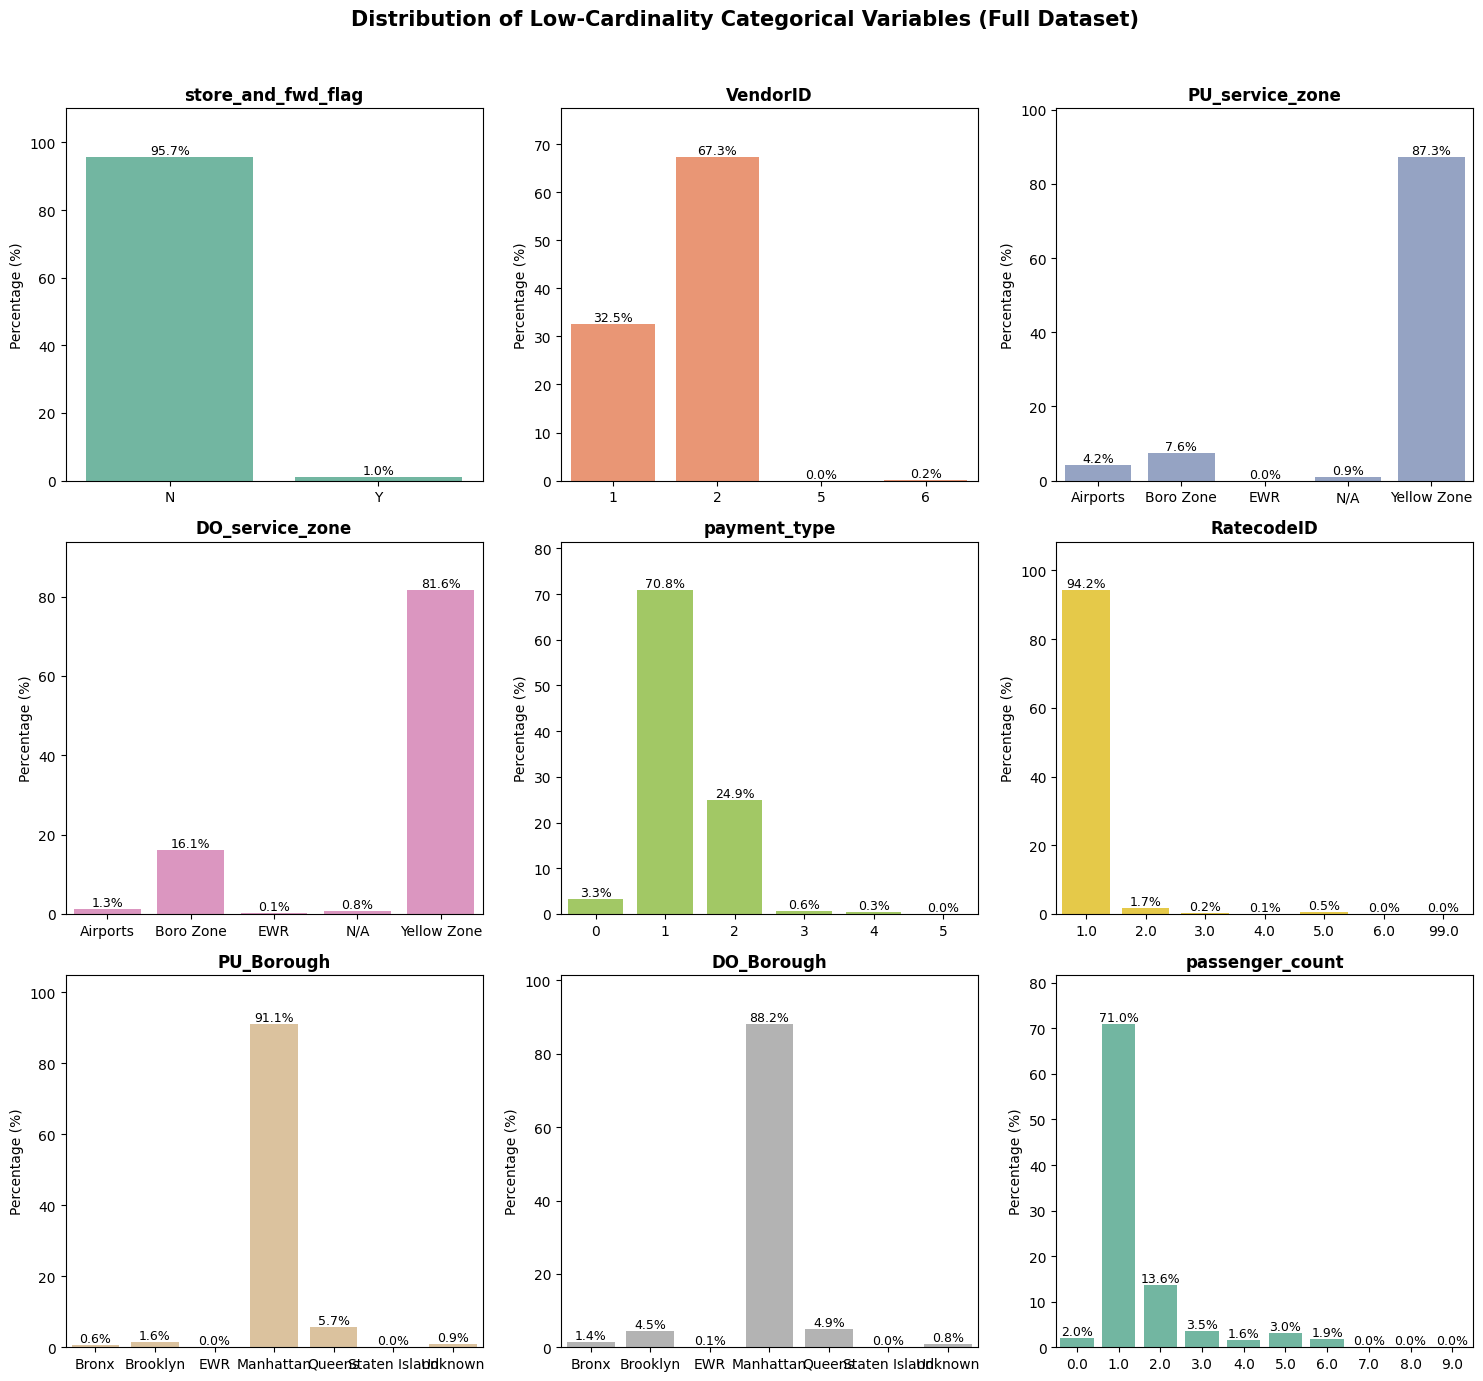

In [9]:
# Derive low-cardinality columns dynamically from card_df (cardinality <= 10)
low_card_cols = card_df.loc[card_df["Distinct values"] <= 10, "Column"].tolist()

# Optional: assign a color per column (cycles through a palette if more cols than colors)
palette = sns.color_palette("Set2", n_colors=len(low_card_cols))

# Compute distributions in Spark (full dataset, no sampling)
distributions = {}
total_rows = taxi_df.count()

for col_name in low_card_cols:
    counts_df = (
        taxi_df.groupBy(col_name)
               .count()
               .orderBy(col_name)
               .toPandas()
    )
    counts_df["percentage"] = counts_df["count"] / total_rows * 100
    distributions[col_name] = counts_df

# Plot: grid layout, max 4 columns per row
n_cols = len(low_card_cols)
ncols = min(3, n_cols)
nrows = math.ceil(n_cols / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
axes = axes.flatten() if n_cols > 1 else [axes]

for ax, col_name, color in zip(axes, low_card_cols, palette):
    df_plot = distributions[col_name]

    sns.barplot(
        x=df_plot[col_name].astype(str),
        y=df_plot["percentage"],
        color=color,
        ax=ax
    )

    ax.set_title(col_name, fontweight="bold")
    ax.set_ylabel("Percentage (%)")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)

    # Annotate bars with the percentage value
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(
                f"{height:.1f}%",
                (p.get_x() + p.get_width() / 2, height),
                ha="center", va="bottom",
                fontsize=9
            )

    # Headroom above tallest bar so annotations don't overlap the title
    ax.set_ylim(0, df_plot["percentage"].max() * 1.15)

# Hide any unused axes (when grid is not perfectly filled)
for ax in axes[n_cols:]:
    ax.axis("off")

plt.suptitle("Distribution of Low-Cardinality Categorical Variables (Full Dataset)",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

#### 3.2.4. Monthly distribution

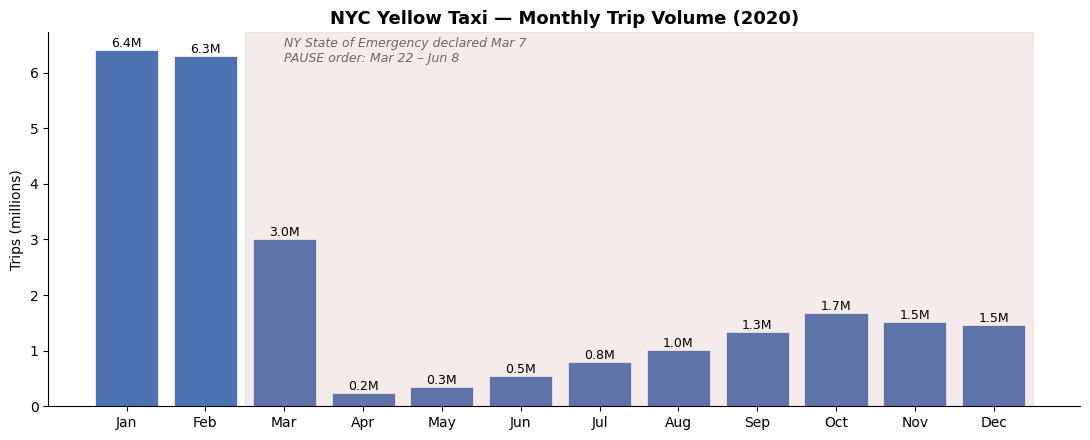

 month   count
     1 6405198
     2 6299493
     3 3007158
     4  237912
     5  348339
     6  549670
     7  799824
     8 1007762
     9 1340368
    10 1682378
    11 1508915
    12 1462075


In [10]:
monthly = (
    taxi_df
    .withColumn("month", month("tpep_pickup_datetime"))
    .filter(col("month").between(1, 12))
    .groupBy("month").count()
    .orderBy("month")
    .toPandas()
)

fig, ax = plt.subplots(figsize=(11, 4.5))
bars = ax.bar(monthly["month"], monthly["count"] / 1e6, color="#4C72B0",
              edgecolor="white", linewidth=0.5)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
ax.set_ylabel("Trips (millions)")
ax.set_title("NYC Yellow Taxi — Monthly Trip Volume (2020)", fontsize=13, fontweight="bold")

# Factual contextual annotation
ax.axvspan(2.5, 12.5, alpha=0.15, color="#C97E7E")
ax.text(
    3, ax.get_ylim()[1] * 0.92,
    "NY State of Emergency declared Mar 7\nPAUSE order: Mar 22 – Jun 8",
    fontsize=9, color="dimgrey", style="italic"
)

for bar, val in zip(bars, monthly["count"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{val/1e6:.1f}M", ha="center", va="bottom", fontsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

print(monthly.to_string(index=False))

#### 3.2.5. Distribution of numerical variables

/var/folders/yp/65klpy9935xg61n4lft7zjrm0000gn/T/ipykernel_17206/3218391605.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


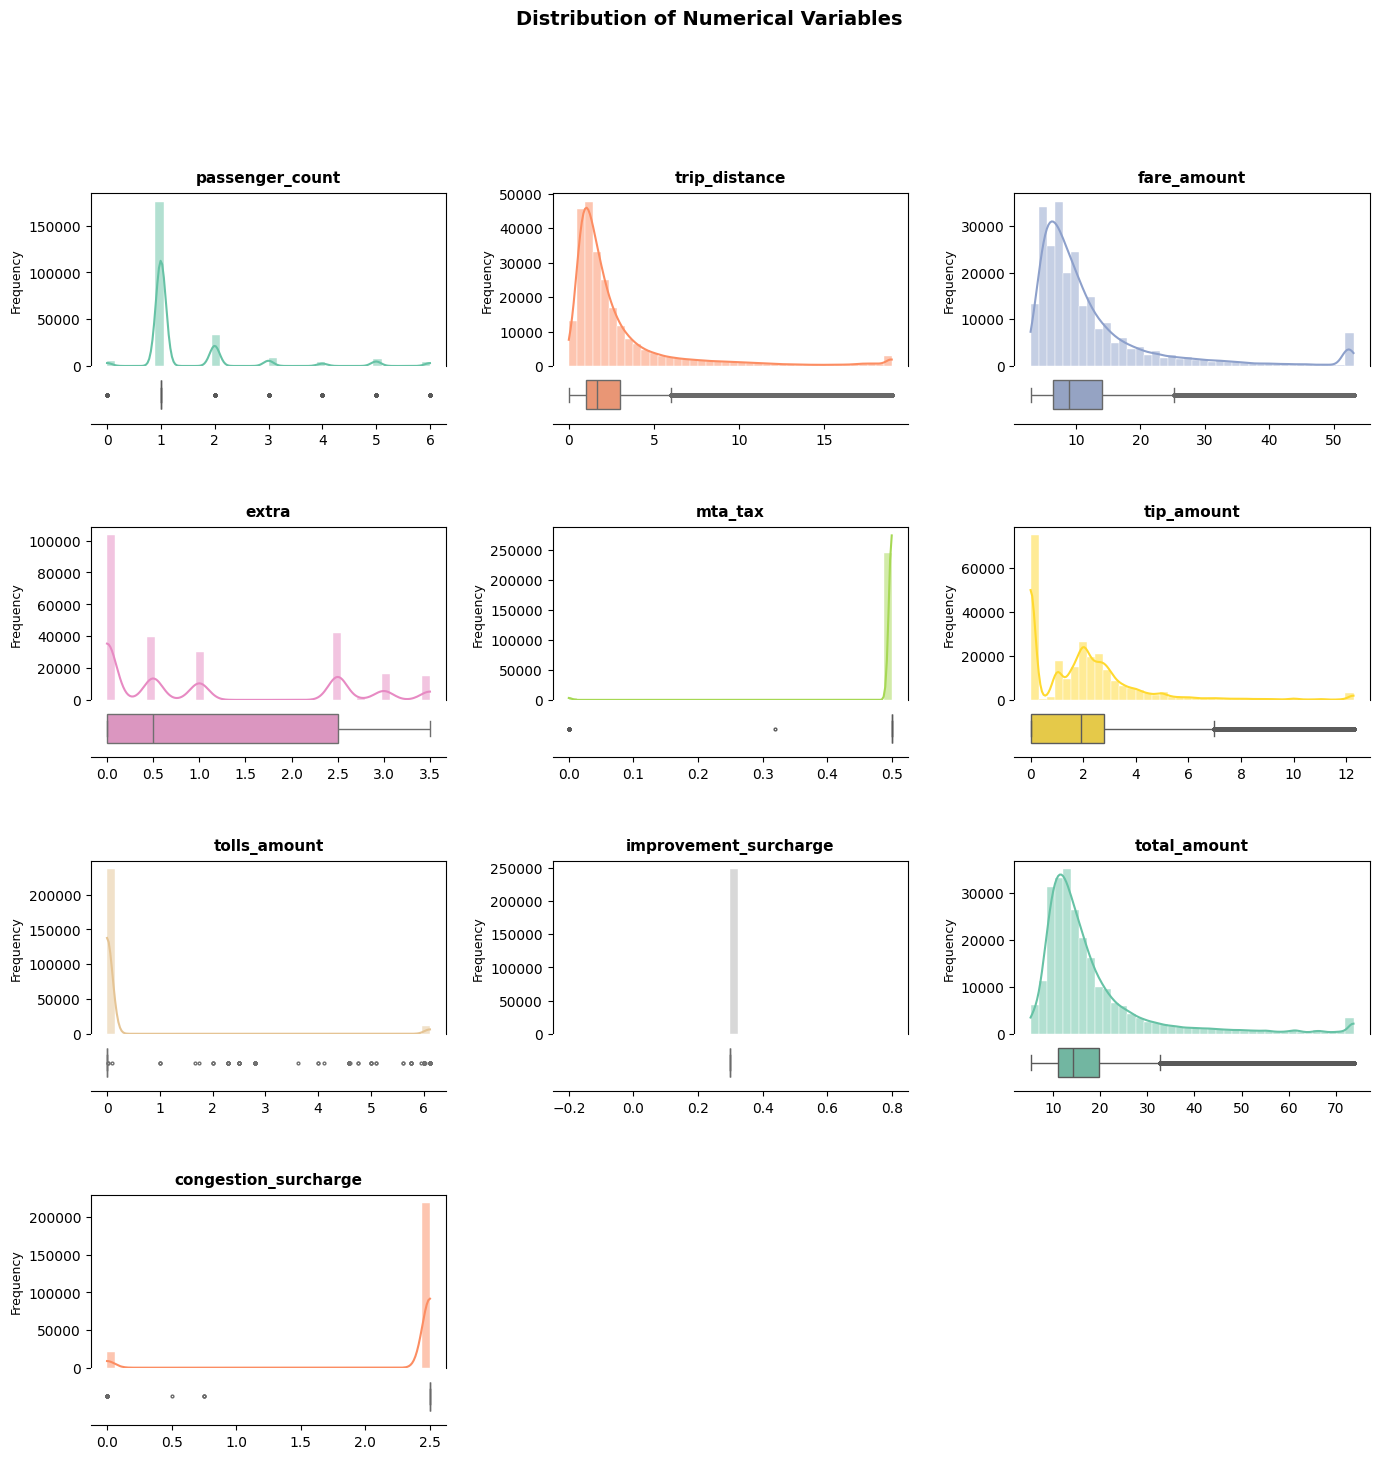

In [11]:
numeric_cols = [
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "extra",
    "mta_tax",
    "tip_amount",
    "tolls_amount",
    "improvement_surcharge",
    "total_amount",
    "congestion_surcharge",
]

# Sample
sample = taxi_df.select(*numeric_cols).sample(fraction=0.01, seed=42).toPandas()

# Clip extreme outliers at 1st/99th percentiles for visualisation only
sample_clipped = sample.copy()
for c in numeric_cols:
    lo, hi = sample_clipped[c].quantile([0.01, 0.99])
    sample_clipped[c] = sample_clipped[c].clip(lo, hi)

n_cols = 3
n_vars = len(numeric_cols)
n_rows = math.ceil(n_vars / n_cols)

fig = plt.figure(figsize=(5.5 * n_cols, 4 * n_rows))
outer = gridspec.GridSpec(n_rows, n_cols, figure=fig, hspace=0.45, wspace=0.3)

palette = sns.color_palette("Set2", n_vars)

for i, col_name in enumerate(numeric_cols):
    r, c = divmod(i, n_cols)
    inner = gridspec.GridSpecFromSubplotSpec(
        2, 1, subplot_spec=outer[r, c],
        height_ratios=[3, 1], hspace=0.0 
    )

    ax_hist = fig.add_subplot(inner[0])
    ax_box  = fig.add_subplot(inner[1], sharex=ax_hist)

    data = sample_clipped[col_name].dropna()

    sns.histplot(data, bins=40, kde=True, ax=ax_hist,
                 color=palette[i], edgecolor="white", linewidth=0.3)
    sns.boxplot(x=data, ax=ax_box, color=palette[i],
                fliersize=2, linewidth=1, width=0.5)

    ax_hist.set_title(col_name, fontsize=11, fontweight="bold", pad=8)
    ax_hist.set_xlabel("")
    ax_hist.set_ylabel("Frequency", fontsize=9)
    ax_hist.tick_params(axis="x", labelbottom=False, bottom=False)
    # Remove the bottom spine of the histogram so it visually connects to the boxplot
    ax_hist.spines["bottom"].set_visible(False)

    ax_box.set_xlabel("")
    ax_box.set_ylabel("")
    ax_box.set_yticks([])
    # Remove the top spine of the boxplot so it joins the histogram
    ax_box.spines["top"].set_visible(False)
    ax_box.spines["left"].set_visible(False)
    ax_box.spines["right"].set_visible(False)

# Hide empty trailing cells
for j in range(n_vars, n_rows * n_cols):
    r, c = divmod(j, n_cols)
    ax_empty = fig.add_subplot(outer[r, c])
    ax_empty.axis("off")

fig.suptitle("Distribution of Numerical Variables",
             fontsize=14, fontweight="bold", y=0.995)
plt.tight_layout()
plt.show()

#### 3.2.6. Correlation heatmap

In [12]:
# --- Pandemic regimes (used across dashboards) ---
taxi_df_reg = taxi_df.withColumn(
    "regime",
    when(month("tpep_pickup_datetime").isin([1, 2]), "1_pre")
     .when(month("tpep_pickup_datetime").isin([3, 4]), "2_lockdown")
     .when(month("tpep_pickup_datetime").isin([5, 6, 7, 8]), "3_recovery")
     .otherwise("4_late")
)

regime_order  = ["1_pre", "2_lockdown", "3_recovery", "4_late"]
regime_labels = {
    "1_pre":       "Pre-pandemic (Jan–Feb)",
    "2_lockdown":  "Lockdown (Mar–Apr)",
    "3_recovery":  "Recovery (May–Aug)",
    "4_late":      "Late 2020 (Sep–Dec)",
}
regime_palette = {
    "1_pre":      "#4C72B0",
    "2_lockdown": "#C44E52",
    "3_recovery": "#DD8452",
    "4_late":     "#55A868",
}

# --- Sample (1%) for scatter plots / pandas-based analysis ---
sample_cols = [
    "passenger_count", "trip_distance",
    "fare_amount", "tip_amount", "tolls_amount", "total_amount",
    "extra", "congestion_surcharge",
    "payment_type", "RatecodeID", "VendorID",
    "PU_Borough", "DO_Borough", "PULocationID", "DOLocationID",
    "tpep_pickup_datetime", "tpep_dropoff_datetime"
]
sample_df = (
    taxi_df.select(*sample_cols)
    .filter(month("tpep_pickup_datetime").between(1, 12))   # drop OOR
    .sample(fraction=0.01, seed=42)
    .toPandas()
)
sample_df["duration_min"] = (
    sample_df["tpep_dropoff_datetime"] - sample_df["tpep_pickup_datetime"]
).dt.total_seconds() / 60
sample_df["month"]     = sample_df["tpep_pickup_datetime"].dt.month
sample_df["hour"]      = sample_df["tpep_pickup_datetime"].dt.hour
sample_df["dow"]       = sample_df["tpep_pickup_datetime"].dt.dayofweek      # 0=Mon
sample_df["date"]      = sample_df["tpep_pickup_datetime"].dt.date
sample_df["regime"]    = pd.cut(
    sample_df["month"],
    bins=[0, 2, 4, 8, 12],
    labels=regime_order
).astype(str)

print(f"Sample size: {len(sample_df):,} rows ({len(sample_df)/n_rows*100:.2f}% of total)")
sample_df.head(3)

Sample size: 247,478 rows (6186950.00% of total)


,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount,total_amount,extra,congestion_surcharge,payment_type,RatecodeID,...,PULocationID,DOLocationID,tpep_pickup_datetime,tpep_dropoff_datetime,duration_min,month,hour,dow,date,regime
0,4.0,1.31,7.0,3.24,0.0,14.04,0.5,2.5,1,1.0,...,229,141,2020-03-01 00:54:14,2020-03-01 01:01:15,7.016667,3,0,6,2020-03-01,2_lockdown
1,1.0,2.30,10.5,2.35,0.0,14.15,0.5,0.0,1,1.0,...,181,188,2020-03-01 00:05:37,2020-03-01 00:16:39,11.033333,3,0,6,2020-03-01,2_lockdown
2,1.0,0.75,5.0,1.00,0.0,9.80,0.5,2.5,1,1.0,...,113,234,2020-03-01 00:38:40,2020-03-01 00:42:58,4.300000,3,0,6,2020-03-01,2_lockdown


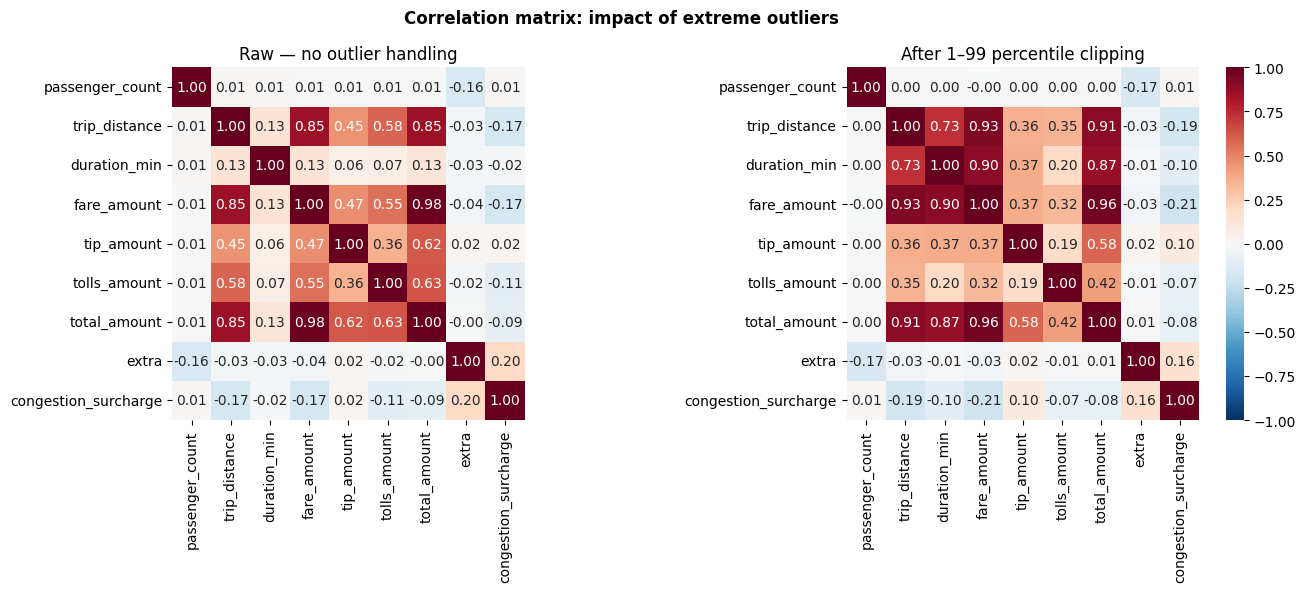

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

corr_cols = ["passenger_count", "trip_distance", "duration_min",
             "fare_amount", "tip_amount", "tolls_amount", "total_amount",
             "extra", "congestion_surcharge"]
# Filter scatter sample at 1-99 percentiles per column
scatter_sample = sample_df[corr_cols + ["payment_type"]].copy()
for c in corr_cols:
    lo, hi = scatter_sample[c].quantile([0.01, 0.99])
    scatter_sample = scatter_sample[(scatter_sample[c] >= lo) & (scatter_sample[c] <= hi)]

raw_corr = sample_df[corr_cols].corr()
sns.heatmap(raw_corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, ax=axes[0], cbar=False)
axes[0].set_title("Raw — no outlier handling")

clip_corr = scatter_sample[corr_cols].corr()
sns.heatmap(clip_corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, ax=axes[1])
axes[1].set_title("After 1–99 percentile clipping")

fig.suptitle("Correlation matrix: impact of extreme outliers", fontweight="bold")
plt.tight_layout()
plt.show()

### **3.3. Verify Data Quality**

#### **3.3.1. Time Inconsistencies**

In [14]:
# Temporal Range Validation
taxi_df.select(
    F.min("tpep_pickup_datetime").alias("start_date"),
    F.max("tpep_pickup_datetime").alias("end_date")
).show()

+-------------------+-------------------+
|         start_date|           end_date|
+-------------------+-------------------+
|2002-12-31 23:06:55|2021-06-10 11:10:48|
+-------------------+-------------------+



In [8]:
taxi_df = taxi_df.filter(
    (F.col("tpep_pickup_datetime") >= "2020-01-01") &
    (F.col("tpep_pickup_datetime") <= "2020-12-31")
)

taxi_df.select(
    F.min("tpep_pickup_datetime").alias("start_date"),
    F.max("tpep_pickup_datetime").alias("end_date")
).show()

+-------------------+-------------------+
|         start_date|           end_date|
+-------------------+-------------------+
|2020-01-01 00:00:00|2020-12-31 00:00:00|
+-------------------+-------------------+



The dataset was filtered to retain only records within the year 2020. A total of **45,072 records** (0.18% of the dataset) presented `tpep_pickup_datetime` values outside this range — either predating 2020 or extending beyond December 31, 2020 — and were removed as 
invalid entries.

#### **3.3.2. Outliers**

In [9]:
outlier_cols = [f.name for f in taxi_df.schema.fields
                if str(f.dataType) in ["DoubleType()", "LongType()", "IntegerType()"]]

quantiles = taxi_df.select([
    percentile_approx(c, 0.25).alias(f"{c}_q1") for c in outlier_cols
] + [
    percentile_approx(c, 0.75).alias(f"{c}_q3") for c in outlier_cols
]).collect()[0]

print(f"{'Column':<25} {'Q1':>10} {'Q3':>10} {'IQR':>10} {'Lower':>12} {'Upper':>12}")
print("-" * 80)

for c in outlier_cols:
    q1 = quantiles[f"{c}_q1"]
    q3 = quantiles[f"{c}_q3"]
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    print(f"{c:<25} {q1:>10.2f} {q3:>10.2f} {iqr:>10.2f} {lower:>12.2f} {upper:>12.2f}")

Column                            Q1         Q3        IQR        Lower        Upper
--------------------------------------------------------------------------------
DOLocationID                  107.00     234.00     127.00       -83.50       424.50
PULocationID                  114.00     234.00     120.00       -66.00       414.00
VendorID                        1.00       2.00       1.00        -0.50         3.50
passenger_count                 1.00       1.00       0.00         1.00         1.00
trip_distance                   0.99       3.00       2.01        -2.02         6.01
RatecodeID                      1.00       1.00       0.00         1.00         1.00
payment_type                    1.00       2.00       1.00        -0.50         3.50
fare_amount                     6.50      14.00       7.50        -4.75        25.25
extra                           0.00       2.50       2.50        -3.75         6.25
mta_tax                         0.50       0.50       0.00         0.

Outlier detection was performed using the **IQR (Interquartile Range)** method, where values below Q1 − 1.5×IQR or above Q3 + 1.5×IQR are considered outliers.

Several key findings emerge:

**`fare_amount`** has an upper bound of **$25.25**, meaning any trip costing more is statistically an outlier. However, airport trips and longer rides legitimately exceed this value, so a more permissive threshold of **$200** was applied instead of the strict IQR limit.

**`total_amount`** shows an upper bound of **$32.76**, with the same reasoning — legitimate trips can exceed this, particularly for airport runs or longer distances.

**`trip_distance`** has an upper bound of **6.01 miles**, which is consistent with typical NYC taxi trips. Values above this are statistically unusual but not necessarily erroneous — longer trips do occur. A hard cap of **1,000 miles** was applied to remove only clearly impossible values.

**`extra`**, **`tip_amount`** and **`tolls_amount`** all show lower bounds below zero, confirming the presence of negative values identified in the describe analysis.

**`mta_tax`**, `improvement_surcharge`, and `congestion_surcharge` show **zero IQR** — they are fixed-value fields with no variance, as expected.

**`passenger_count`** and `RatecodeID` also show zero IQR, indicating the vast majority of trips use standard rate (1) with 1 passenger.

#### **3.3.3. Numerical Columns**

In [10]:
numeric_cols = [f.name for f in taxi_df.schema.fields
                if str(f.dataType) in ["DoubleType()", "LongType()", "IntegerType()"]]

taxi_df.select(numeric_cols).describe().show(truncate=False)

+-------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+---------------------+------------------+--------------------+-----------+
|summary|DOLocationID      |PULocationID      |VendorID          |passenger_count   |trip_distance     |RatecodeID        |payment_type      |fare_amount       |extra             |mta_tax           |tip_amount        |tolls_amount       |improvement_surcharge|total_amount      |congestion_surcharge|airport_fee|
+-------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+---------------------+------------------+--------------------+-----------+
|count  |24604020          |24604020          |24604020      

A statistical summary of all numerical attributes revealed several data quality issues that require attention before any analysis or modelling can be performed. Outlier detection was additionally performed using the **IQR (Interquartile Range)** method, where values below Q1 − 1.5×IQR or above Q3 + 1.5×IQR are considered outliers.

#### Potentially Erroneous `fare_amount` and `total_amount`
Both fields present extreme outliers. `fare_amount` ranges from **-$1,259** to **$998,310**, and `total_amount` from **-$1,260** to **$1,000,003**. Negative values are physically impossible and likely result from system reversals or data entry errors. Values in the hundreds of thousands are equally implausible for NYC taxi trips. The IQR analysis confirms an upper bound of **$25.25** for `fare_amount` and **$32.76** for `total_amount`, reinforcing the presence of extreme outliers. These records will be removed by filtering `total_amount` to a reasonable range **(> $0 and < $10,000)**.

#### Unreasonable `trip_distance`
Trip distance ranges from **-30.62** to **350,914 miles** — the latter being equivalent to travelling around the Earth 14 times. Negative distances are impossible, and values above 1,000 miles are clearly erroneous. The IQR upper bound of **6.01 miles** confirms that the vast majority of NYC trips are short, making values above 1,000 miles unambiguously erroneous. Records with `trip_distance >= 1,000` will be removed.

#### Erroneous `passenger_count`
While the majority of trips have between 1 and 6 passengers, the field contains values of **0** (likely unrecorded by the driver) and up to **9**, which exceeds the legal NYC taxi capacity. The IQR shows zero variance — the median trip carries **1 passenger** — confirming that higher values are anomalous. Records with `passenger_count` of 0 or greater than 6 will be removed.

#### Anomalous `extra`, `mta_tax` and `fare_per_mile`
These fields also present negative minimum values and extreme maxima (e.g. `extra` reaching **$500,000**). The IQR confirms these as outliers — `extra` has an upper bound of **$6.25** under normal conditions. These anomalies are consistent with the same data entry or system errors identified above and will be addressed by the filters applied to `total_amount` and `trip_distance`.

#### Fixed-Value Fields
`mta_tax`, `improvement_surcharge`, and `congestion_surcharge` show **zero IQR**, confirming they are fixed-value fields with no variance, as expected from NYC TLC regulations.

#### RatecodeID
Additionally, `RatecodeID` was found to contain the value **99**, which does not correspond to any valid rate code in the NYC TLC data dictionary. These records are considered erroneous and will be removed by filtering `RatecodeID` to valid values only **(1 to 6)**.

#### **3.3.4. Missing values**

In [11]:
missing_df = taxi_df.select([
    _sum(col(c).isNull().cast("int")).alias(c)
    for c in taxi_df.columns
])

missing_df.show(truncate=False)

+------------+------------+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+----------+-------+---------------+----------+-------+---------------+
|DOLocationID|PULocationID|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|airport_fee|PU_Borough|PU_Zone|PU_service_zone|DO_Borough|DO_Zone|DO_service_zone|
+------------+------------+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+----------+-------+---------------+----------+--

**False Nulls**

This code performs a detailed audit of hidden missing values within all string-based columns of the dataset. Rather than relying solely on Spark’s native `NULL` detection, it searches for inconsistent textual placeholders such as `"nan"`, `"null"`, `"n/a"`, empty strings, and `"unknown"` that are often introduced during data collection or export processes.

After identifying these inconsistencies, the results are converted into a Pandas DataFrame for visualization. A customized horizontal bar chart is then generated using Seaborn and Matplotlib, where darker red tones indicate a higher proportion of hidden missing values. This visual approach allows problematic columns to be identified immediately and supports a more transparent assessment of data quality before cleaning operations begin.

Hunting for hidden textual inconsistencies...


C:\Users\nonof\AppData\Local\Temp\ipykernel_24156\1689130570.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


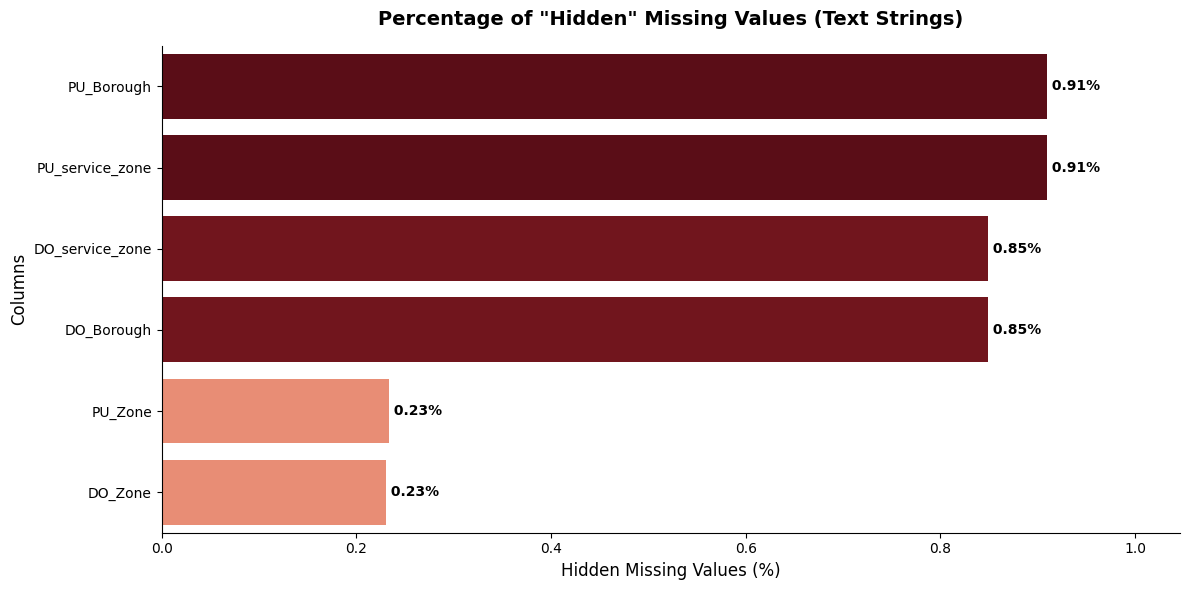

In [14]:
string_cols = [c for c, t in taxi_df.dtypes if t == 'string']

print("Hunting for hidden textual inconsistencies...")
hidden_nulls_exprs = [
    _sum(
        when(lower(trim(col(c))).isin('nan', 'null', 'n/a', 'na', '', 'unknown'), 1).otherwise(0)
    ).alias(c)
    for c in string_cols
]

hidden_missing_df = taxi_df.select(hidden_nulls_exprs)

missing_pd = hidden_missing_df.toPandas()
missing_pd_melted = missing_pd.melt(var_name='Column', value_name='Missing_Values')
missing_pd_melted = missing_pd_melted[missing_pd_melted['Missing_Values'] > 0]

if not missing_pd_melted.empty:
    TOTAL_ROWS = taxi_df.count()
    missing_pd_melted['Percentage'] = (missing_pd_melted['Missing_Values'] / TOTAL_ROWS) * 100
    missing_pd_melted = missing_pd_melted.sort_values(by='Percentage', ascending=False)

    max_pct = missing_pd_melted['Percentage'].max()
    norm = mcolors.Normalize(vmin=-max_pct * 0.3, vmax=max_pct)
    mapper = cm.ScalarMappable(norm=norm, cmap='Reds')

    missing_pd_melted['BarColor'] = [mapper.to_rgba(p) for p in missing_pd_melted['Percentage']]

    plt.figure(figsize=(12, 6))

    sns.barplot(
        data=missing_pd_melted,
        x='Percentage',
        y='Column',
        palette=list(missing_pd_melted['BarColor'])
    )

    plt.title('Percentage of "Hidden" Missing Values (Text Strings)', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Hidden Missing Values (%)', fontsize=12)
    plt.ylabel('Columns', fontsize=12)

    plt.xlim(0, max_pct * 1.15)

    for index, row in enumerate(missing_pd_melted.itertuples()):
        plt.text(row.Percentage, index, f' {row.Percentage:.2f}%', va='center', fontweight='bold')

    sns.despine()
    plt.tight_layout()
    plt.show()
else:
    print("Falsely missing values (like 'nan', 'null', 'n/a', etc.) were not found in string columns.")

**Converting False Nulls into Missing Values**

This code standardizes hidden textual inconsistencies by converting all non-valid placeholder strings into proper `NULL` values recognized by Spark. The transformation is applied dynamically across every string column in the dataset using conditional logic combined with normalization techniques such as trimming whitespace and converting text to lowercase.

By replacing inconsistent textual representations with standardized null values, the dataset becomes significantly easier to clean, validate, and analyze. The final verification step confirms the success of the transformation by computing the number of remaining null values in each string column after the cleaning process.

In [15]:
bad_strings = ['nan', 'null', 'n/a', 'na', '', 'unknown']

string_cols = [c for c, t in taxi_df.dtypes if t == 'string']

for c in string_cols:
    taxi_df = taxi_df.withColumn(
        c,
        when(lower(trim(col(c))).isin(bad_strings), lit(None).cast("string"))
        .otherwise(col(c))
    )

print("Conversion completed! Verifying results...")


print("\nNulls after cleaning text columns:")
taxi_df.select([
    _sum(when(isnull(col(c)), 1).otherwise(0)).alias(c)
    for c in string_cols
]).show(vertical=True)

Conversion completed! Verifying results...

Nulls after cleaning text columns:
-RECORD 0--------------------
 store_and_fwd_flag | 806563 
 PU_Borough         | 223831 
 PU_Zone            | 57481  
 PU_service_zone    | 223831 
 DO_Borough         | 208937 
 DO_Zone            | 56807  
 DO_service_zone    | 208937 



+------------+------------+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+----------+-------+---------------+----------+-------+---------------+
|DOLocationID|PULocationID|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|airport_fee|PU_Borough|PU_Zone|PU_service_zone|DO_Borough|DO_Zone|DO_service_zone|
+------------+------------+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+----------+-------+---------------+----------+--

C:\Users\nonof\AppData\Local\Temp\ipykernel_24156\1221990556.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


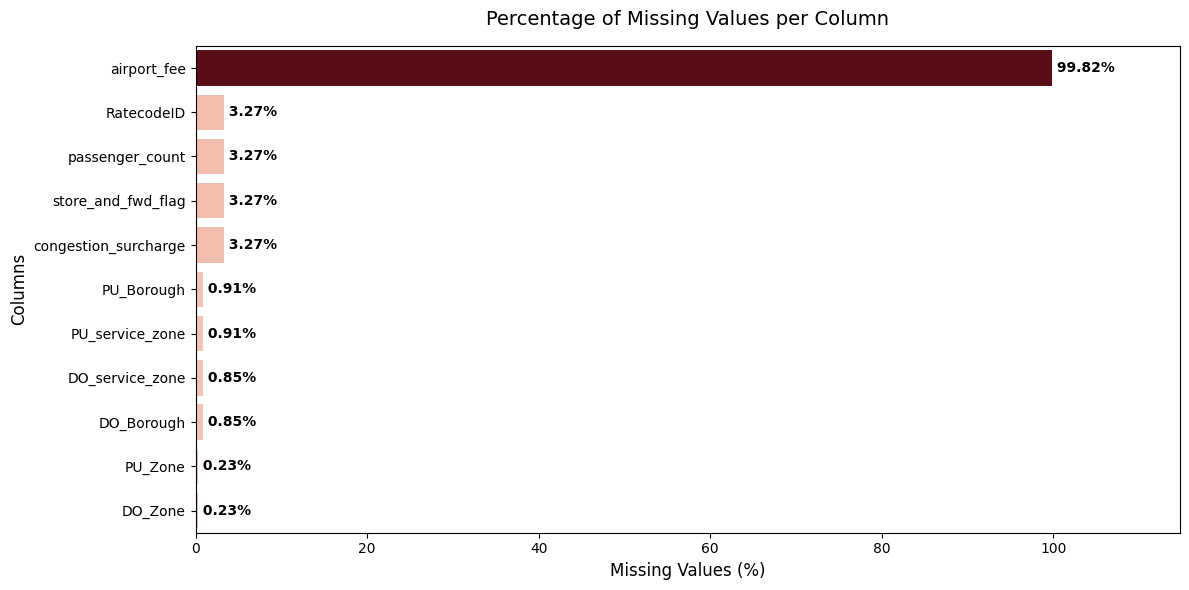

In [16]:
# 1. Prepare data
missing_df = taxi_df.select([
    _sum(col(c).isNull().cast("int")).alias(c)
    for c in taxi_df.columns
])

missing_df.show(truncate=False)

missing_pd = missing_df.toPandas()
missing_pd_melted = missing_pd.melt(var_name='Column', value_name='Missing_Values')
missing_pd_melted = missing_pd_melted[missing_pd_melted['Missing_Values'] > 0]

# 2. Calculate percentage
TOTAL_ROWS = 24649092
missing_pd_melted['Percentage'] = (missing_pd_melted['Missing_Values'] / TOTAL_ROWS) * 100
missing_pd_melted = missing_pd_melted.sort_values(by='Percentage', ascending=False)

# 3. MANUAL COLOR MAPPING (Fixed: Avoids hue_norm error)
max_pct = missing_pd_melted['Percentage'].max()
# We create a normalization object that avoids pure white (vmin)
norm = mcolors.Normalize(vmin=-max_pct * 0.3, vmax=max_pct)
mapper = cm.ScalarMappable(norm=norm, cmap='Reds')

# Assign a specific hex color to each row based on its percentage
missing_pd_melted['BarColor'] = [mapper.to_rgba(p) for p in missing_pd_melted['Percentage']]

# 4. Create the chart
plt.figure(figsize=(12, 6))

# We pass the pre-calculated colors directly to 'palette' or 'color'
sns.barplot(
    data=missing_pd_melted,
    x='Percentage',
    y='Column',
    palette=list(missing_pd_melted['BarColor'])
)

plt.title('Percentage of Missing Values per Column', fontsize=14, pad=15)
plt.xlabel('Missing Values (%)', fontsize=12)
plt.ylabel('Columns', fontsize=12)

# Extend X-axis slightly
plt.xlim(0, max_pct * 1.15)

# Add labels
for index, row in enumerate(missing_pd_melted.itertuples()):
    plt.text(row.Percentage, index, f' {row.Percentage:.2f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [17]:
print("Starting Data Cleaning Pipeline...")
total_rows = taxi_df.count()

# 100% Missing
taxi_df = taxi_df.drop("airport_fee")

# ~3.29% Missing
taxi_df = taxi_df \
    .withColumn(
        "RatecodeID",
        when(col("RatecodeID").isNull(),
             # If origin or destination is JFK (Zone ID 132 is JFK), apply RateCode 2
             when((col("PULocationID") == 132) | (col("DOLocationID") == 132), 2.0)
             # Otherwise, apply the standard fare (1)
             .otherwise(1.0)
        ).otherwise(col("RatecodeID"))
    ) \
    .withColumn(
        "congestion_surcharge",
        when(col("congestion_surcharge").isNull(),
             # If started or ended in Manhattan, apply the $2.50 fee
             when((col("PU_Borough") == 'Manhattan') | (col("DO_Borough") == 'Manhattan'), 2.5)
             .otherwise(0.0)
        ).otherwise(col("congestion_surcharge"))
    ) \
    .fillna({
        "passenger_count": 1.0,
        "store_and_fwd_flag": "N"
    })

# < 1% Missing
# Drop rows where critical geographic or categorical data is still missing
geo_cols_to_check = [
    "PU_Borough", "PU_service_zone", "PU_Zone",
    "DO_Borough", "DO_service_zone", "DO_Zone"
]

taxi_df = taxi_df.dropna(subset=geo_cols_to_check)

print("Data Cleaning and Imputation completed!")

# Validation
check_cols = [
    "passenger_count", "RatecodeID", "store_and_fwd_flag",
    "congestion_surcharge", "PU_Borough", "DO_Borough"
]

print("\nFinal Null Count Check (Should be all 0):")
taxi_df.select([
    _sum(col(c).isNull().cast("int")).alias(c)
    for c in check_cols
]).show(vertical=True)

Starting Data Cleaning Pipeline...
Data Cleaning and Imputation completed!

Final Null Count Check (Should be all 0):
-RECORD 0-------------------
 passenger_count      | 0   
 RatecodeID           | 0   
 store_and_fwd_flag   | 0   
 congestion_surcharge | 0   
 PU_Borough           | 0   
 DO_Borough           | 0   



#### **3.3.5. Global Inconsistencies**

In [18]:
raw_row_count = taxi_df.count()
print(f"Initial row count: {raw_row_count:,}\n")

# -- Helper: trip duration in minutes (temporary, dropped at the end) --
taxi_df = taxi_df.withColumn(
    "duration_min",
    (F.unix_timestamp("tpep_dropoff_datetime") - F.unix_timestamp("tpep_pickup_datetime")) / 60.0
)

# ------------------------------------------------------------
# STEP 1 — Detect inconsistencies (report counts before fixing)
# ------------------------------------------------------------
checks = {
    # Duplicates
    "Exact duplicate rows":
        raw_row_count - taxi_df.distinct().count(),

    # Temporal anomalies
    "Dropoff before pickup":
        taxi_df.filter(F.col("tpep_dropoff_datetime") < F.col("tpep_pickup_datetime")).count(),
    "Duration < 1 minute":
        taxi_df.filter(F.col("duration_min") < 1).count(),
    "Duration > 6 hours":
        taxi_df.filter(F.col("duration_min") > 360).count(),
    "Pickup outside 2020":
        taxi_df.filter(F.year("tpep_pickup_datetime") != 2020).count(),

    # Distance anomalies
    "trip_distance <= 0":
        taxi_df.filter(F.col("trip_distance") <= 0).count(),
    "trip_distance > 100 miles":
        taxi_df.filter(F.col("trip_distance") > 100).count(),

    # Speed anomalies (derived)
    "Avg speed > 100 mph":
        taxi_df.filter(
            (F.col("duration_min") > 1) &
            ((F.col("trip_distance") / (F.col("duration_min") / 60)) > 100)
        ).count(),

    # Financial anomalies
    "fare_amount < 2.5 (below NYC initial charge)":
        taxi_df.filter(F.col("fare_amount") < 2.5).count(),
    "fare_amount > 500":
        taxi_df.filter(F.col("fare_amount") > 500).count(),
    "total_amount <= 0":
        taxi_df.filter(F.col("total_amount") <= 0).count(),
    "total_amount > 600":
        taxi_df.filter(F.col("total_amount") > 600).count(),
    "tip_amount < 0":
        taxi_df.filter(F.col("tip_amount") < 0).count(),
    "total_amount != sum of components (tol. 0.1)":
        taxi_df.filter(
            F.abs(
                F.col("total_amount") - (
                    F.col("fare_amount") + F.col("extra") + F.col("mta_tax") +
                    F.col("tip_amount") + F.col("tolls_amount") +
                    F.col("improvement_surcharge") + F.coalesce(F.col("congestion_surcharge"), F.lit(0))
                )
            ) > 0.1
        ).count(),

    # Passenger count
    "passenger_count = 0":
        taxi_df.filter(F.col("passenger_count") == 0).count(),
    "passenger_count > 6":
        taxi_df.filter(F.col("passenger_count") > 6).count(),

    # Invalid categorical codes
    "Invalid RatecodeID (not in 1..6)":
        taxi_df.filter(~F.col("RatecodeID").isin([1, 2, 3, 4, 5, 6])).count(),
    "Invalid PULocationID (not in 1..263)":
        taxi_df.filter(~F.col("PULocationID").between(1, 263)).count(),
    "Invalid DOLocationID (not in 1..263)":
        taxi_df.filter(~F.col("DOLocationID").between(1, 263)).count(),
}

# Build report
import pandas as pd
quality_df = pd.DataFrame(list(checks.items()), columns=["Inconsistency", "Count"])
quality_df["% of total"] = (100 * quality_df["Count"] / raw_row_count).round(3)
quality_df = quality_df.sort_values("Count", ascending=False).reset_index(drop=True)

print("=" * 75)
print("DATA INCONSISTENCIES DETECTED")
print("=" * 75)
print(quality_df.to_string(index=False))

# ------------------------------------------------------------
# STEP 2 — Apply cleaning rules
# ------------------------------------------------------------
taxi_clean = (
    taxi_df
    # 2.1 — Deduplicate
    .dropDuplicates()

    # 2.2 — Temporal validity
    .filter(F.col("tpep_dropoff_datetime") > F.col("tpep_pickup_datetime"))
    .filter((F.col("duration_min") >= 1) & (F.col("duration_min") <= 360))
    .filter(F.year("tpep_pickup_datetime") == 2020)

    # 2.3 — Distance validity
    .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") <= 100))

    # 2.4 — Speed sanity check
    .filter((F.col("trip_distance") / (F.col("duration_min") / 60)) < 100)

    # 2.5 — Financial validity
    .filter((F.col("fare_amount") >= 2.5) & (F.col("fare_amount") <= 500))
    .filter((F.col("total_amount") > 0) & (F.col("total_amount") <= 600))
    .filter(F.col("tip_amount") >= 0)

    # 2.6 — Passenger count
    .filter((F.col("passenger_count") >= 1) & (F.col("passenger_count") <= 6))

    # 2.7 — Valid categorical codes
    .filter(F.col("RatecodeID").isin([1, 2, 3, 4, 5, 6]))
    .filter(F.col("PULocationID").between(1, 263))
    .filter(F.col("DOLocationID").between(1, 263))

    # 2.8 — Drop helper column
    .drop("duration_min")
)

# Cache + register view for downstream queries
taxi_clean.cache()
taxi_clean.createOrReplaceTempView("taxi_clean")

clean_count = taxi_clean.count()
removed = raw_row_count - clean_count
retention = 100 * clean_count / raw_row_count

taxi_df = taxi_clean

print("\n" + "=" * 75)
print("CLEANING RESULTS")
print("=" * 75)
print(f"Rows before cleaning : {raw_row_count:,}")
print(f"Rows after cleaning  : {clean_count:,}")
print(f"Rows removed         : {removed:,} ({100 - retention:.2f}%)")
print(f"Retention rate       : {retention:.2f}%")
print(f"Final column count   : {len(taxi_clean.columns)}")
print("=" * 75)

Initial row count: 24,285,406

DATA INCONSISTENCIES DETECTED
                               Inconsistency   Count  % of total
total_amount != sum of components (tol. 0.1) 7532187      31.015
                         passenger_count = 0  482390       1.986
                          trip_distance <= 0  282114       1.162
                         Duration < 1 minute  207062       0.853
fare_amount < 2.5 (below NYC initial charge)  100846       0.415
                           total_amount <= 0   95288       0.392
                          Duration > 6 hours   47189       0.194
                        Exact duplicate rows   12841       0.053
                         Avg speed > 100 mph    1176       0.005
                              tip_amount < 0     863       0.004
            Invalid RatecodeID (not in 1..6)     791       0.003
                   trip_distance > 100 miles     246       0.001
                       Dropoff before pickup     194       0.001
                         pass

#### **Summary of data-quality findings**

| Issue | Severity | Strategy |
|---|---|---|
| `airport_fee` 100% null in 2020 | High | **Drop column** |
| `RatecodeID` null (~3.3%) | Medium | **Impute** (RateCode 2 if JFK zone, else 1 — Standard) |
| `congestion_surcharge` null | Medium | **Impute** ($2.50 if pickup or dropoff in Manhattan, else $0) |
| `passenger_count` null | Low | **Impute** with 1 (default fare-paying passenger) |
| `store_and_fwd_flag` null | Low | **Impute** with `'N'` (default — not store-and-forward) |
| Hidden textual nulls in string cols (`'nan'`, `'null'`, `'n/a'`, …) | Low | **Normalize** to real NULL, then drop |
| Geographic fields (`PU_Borough`, `PU_Zone`, `PU_service_zone`, `DO_*`) still null after lookup join | Low (<1%) | **Drop rows** |
| Exact duplicate rows | Very low | **Drop** |
| Pickup outside 2020 (`2008`, `2030`, …) | Very low (<0.01%) | **Filter** to year = 2020 |
| `dropoff <= pickup` | Low | **Filter** |
| Duration `< 1 min` | Medium | **Filter** (likely meter errors) |
| Duration `> 6 h` | Low | **Filter** (implausible for urban taxi) |
| `trip_distance <= 0` | Medium | **Filter** to `> 0` |
| `trip_distance > 100 miles` | Low | **Filter** (covers Nassau/Westchester at the upper end) |
| Average speed `> 100 mph` | Low | **Filter** (physically implausible in traffic) |
| `fare_amount` below NYC initial charge ($2.50) | Medium | **Filter** to `>= 2.5` |
| `fare_amount > 500` | Low | **Filter** (outlier / meter error) |
| `total_amount <= 0` | Medium | **Filter** (refunds, disputes, reversals) |
| `total_amount > 600` | Low | **Filter** (outlier) |
| `tip_amount < 0` | Low | **Filter** |
| `total_amount` ≠ sum of components (tol. 0.1) | Medium | **Report only** (rounding/reversal artefacts; not removed) |
| `passenger_count = 0` | Medium | **Filter** to `>= 1` |
| `passenger_count > 6` | Low | **Filter** (yellow-taxi legal capacity) |
| Invalid `RatecodeID` (not in 1–6) | Low | **Filter** to TLC catalogue |
| Invalid `PULocationID` / `DOLocationID` (not in 1–263) | Low | **Filter** to TLC zone catalogue |

### **3.4. Feature Engineering**

In [19]:
print("Starting feature engineering...")

taxi_features = (
    taxi_df

    # --- Temporal features (derived from pickup timestamp) ---
    .withColumn("pickup_hour",        F.hour("tpep_pickup_datetime"))
    .withColumn("pickup_day_of_week", F.dayofweek("tpep_pickup_datetime"))  # 1=Sun, 7=Sat
    .withColumn("pickup_month",       F.month("tpep_pickup_datetime"))
    .withColumn("pickup_date",        F.to_date("tpep_pickup_datetime"))

    # --- Operational metrics ---
    .withColumn(
        "trip_duration_min",
        (F.unix_timestamp("tpep_dropoff_datetime") - F.unix_timestamp("tpep_pickup_datetime")) / 60.0
    )
    .withColumn(
        "speed_mph",
        F.when(
            F.col("trip_duration_min") > 0,
            F.col("trip_distance") / (F.col("trip_duration_min") / 60.0)
        )
    )
    .withColumn(
        "fare_per_mile",
        F.when(F.col("trip_distance") > 0, F.col("fare_amount") / F.col("trip_distance"))
    )

    # --- Behavioural feature: tip percentage (credit-card only) ---
    # Cash tips are not recorded by the meter, so we restrict to payment_type = 1
    .withColumn(
        "tip_pct",
        F.when(
            (F.col("payment_type") == 1) & (F.col("fare_amount") > 0),
            (F.col("tip_amount") / F.col("fare_amount")) * 100
        ).otherwise(0.0)
    )

    # --- Temporal flags ---
    # Rush hour: weekday mornings (7–9) and evenings (16–19)
    .withColumn(
        "is_rush_hour",
        (
            (F.col("pickup_day_of_week").between(2, 6)) &  # Mon–Fri
            (
                F.col("pickup_hour").between(7, 9) |
                F.col("pickup_hour").between(16, 19)
            )
        )
    )
    .withColumn(
        "is_weekend",
        F.col("pickup_day_of_week").isin([1, 7])  # Sun or Sat
    )

    # --- Time-of-day bucket (for visual aggregations) ---
    .withColumn(
        "time_of_day",
        F.when(F.col("pickup_hour").between(0, 5), "Night")
         .when(F.col("pickup_hour").between(6, 11), "Morning")
         .when(F.col("pickup_hour").between(12, 17), "Afternoon")
         .otherwise("Evening")
    )

    # --- Human-readable categorical labels ---
    .withColumn(
        "payment_name",
        F.when(F.col("payment_type") == 1, "Credit Card")
         .when(F.col("payment_type") == 2, "Cash")
         .when(F.col("payment_type") == 3, "No Charge")
         .when(F.col("payment_type") == 4, "Dispute")
         .when(F.col("payment_type") == 5, "Unknown")
         .when(F.col("payment_type") == 6, "Voided")
         .otherwise("Other")
    )
    .withColumn(
        "vendor_name",
        F.when(F.col("VendorID") == 1, "Creative Mobile")
         .when(F.col("VendorID") == 2, "VeriFone")
         .otherwise("Other")
    )
    .withColumn(
        "rate_name",
        F.when(F.col("RatecodeID") == 1, "Standard")
         .when(F.col("RatecodeID") == 2, "JFK")
         .when(F.col("RatecodeID") == 3, "Newark")
         .when(F.col("RatecodeID") == 4, "Nassau/Westchester")
         .when(F.col("RatecodeID") == 5, "Negotiated")
         .when(F.col("RatecodeID") == 6, "Group Ride")
         .otherwise("Other")
    )
)

# Cache the enriched DataFrame — every downstream query reuses these features
taxi_features.cache()
taxi_features.createOrReplaceTempView("taxi_features")
taxi_df = taxi_features

print(f"Feature engineering complete.")
print(f"Total columns after feature engineering: {len(taxi_features.columns)}")
print(f"\nNew features added:")
print("  Temporal     : pickup_hour, pickup_day_of_week, pickup_month, pickup_date")
print("  Operational  : trip_duration_min, speed_mph, fare_per_mile")
print("  Behavioural  : tip_pct")
print("  Flags        : is_rush_hour, is_weekend, time_of_day")
print("  Labels       : payment_name, vendor_name, rate_name")

Starting feature engineering...
Feature engineering complete.
Total columns after feature engineering: 38

New features added:
  Temporal     : pickup_hour, pickup_day_of_week, pickup_month, pickup_date
  Operational  : trip_duration_min, speed_mph, fare_per_mile
  Behavioural  : tip_pct
  Flags        : is_rush_hour, is_weekend, time_of_day
  Labels       : payment_name, vendor_name, rate_name


---

## **4. Queries**

In [20]:
taxi_df.createOrReplaceTempView("taxi_data")

### **4.1. Billing and Tips**

#### Query 1

Spark

In [36]:
start_time = time.time()

q1_api_df = taxi_df.filter(col("fare_amount") > 0) \
    .withColumn("tip_pct", (col("tip_amount") / col("fare_amount")) * 100) \
    .groupBy("PU_Borough") \
    .agg(
        avg("tip_pct").alias("avg_tip_pct"),
        avg("total_amount").alias("avg_total")
    ) \
    .orderBy("avg_total", ascending=False)

q1_pd = q1_api_df.toPandas()

q1_api_time = time.time() - start_time

print(f"Q1 PySpark API Time: {q1_api_time:.4f}s")

Q1 PySpark API Time: 55.2159s


SQL

In [37]:
start_time = time.time()

q1_sql = spark.sql("""
    SELECT
        PU_Borough,
        AVG((tip_amount / fare_amount) * 100) AS avg_tip_pct,
        AVG(total_amount) AS avg_total
    FROM taxi_data
    WHERE fare_amount > 0
    GROUP BY PU_Borough
    ORDER BY avg_total DESC
""")

q1_pd_sql = q1_sql.toPandas()

q1_sql_time = time.time() - start_time

print(f"Q1 Spark SQL Time: {q1_sql_time:.4f}s")

Q1 Spark SQL Time: 1.4591s


Visualization

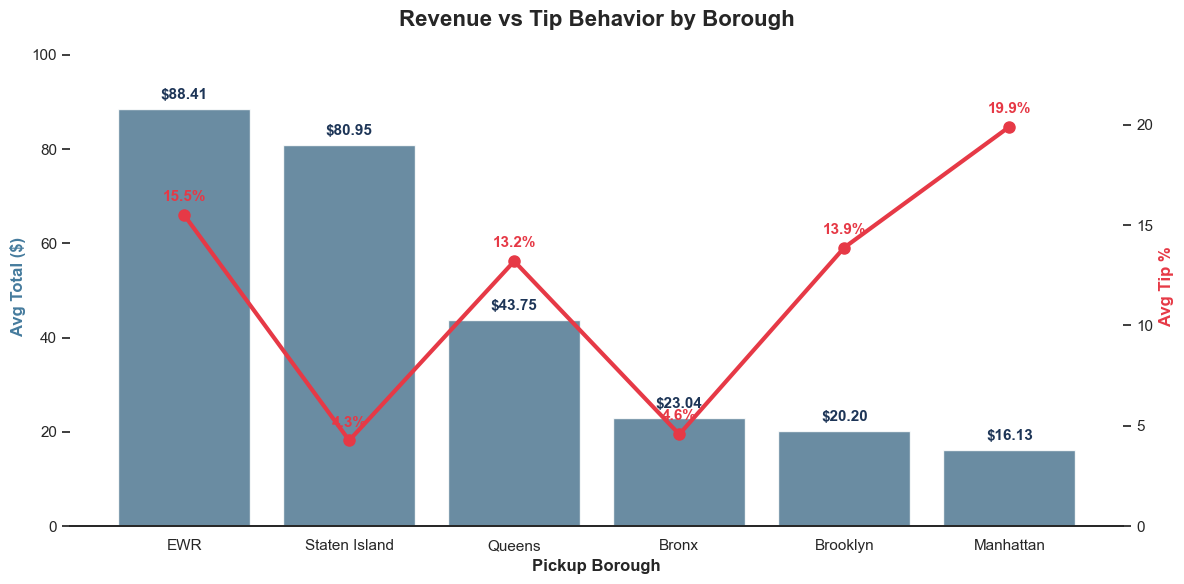

In [38]:
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'

main_color = "#457b9d"
highlight_color = "#e63946"

fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')

sns.barplot(data=q1_pd, x="PU_Borough", y="avg_total", color=main_color, alpha=0.85, ax=ax)
ax.set_title("Revenue vs Tip Behavior by Borough", fontweight='bold', fontsize=16, pad=15)
ax.set_ylabel("Avg Total ($)", fontweight='bold', color=main_color)
ax.set_xlabel("Pickup Borough", fontweight='bold')

for container in ax.containers:
    ax.bar_label(container, fmt='$%.2f', padding=5, fontweight='bold', color='#1d3557', fontsize=11)

ax.set_ylim(0, q1_pd["avg_total"].max() * 1.15)

axb = ax.twinx()
axb.plot(q1_pd["PU_Borough"], q1_pd["avg_tip_pct"], color=highlight_color, marker='o', linewidth=3, markersize=8)
axb.set_ylabel("Avg Tip %", fontweight='bold', color=highlight_color)
axb.grid(False)

for i, val in enumerate(q1_pd["avg_tip_pct"]):
    axb.annotate(f'{val:.1f}%', (i, val), textcoords="offset points", xytext=(0, 10),
                 ha='center', color=highlight_color, fontweight='bold', fontsize=11)

axb.set_ylim(0, q1_pd["avg_tip_pct"].max() * 1.20)

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

#### Query 2

Spark

In [39]:
start_time = time.time()

q2_api_df = taxi_df.filter((col("payment_type") == 1) & (col("fare_amount") > 0)) \
    .withColumn("dist_tier",
        when(col("trip_distance") < 2, "1. Short (<2mi)")
        .when((col("trip_distance") >= 2) & (col("trip_distance") < 5), "2. Medium (2-5mi)")
        .when((col("trip_distance") >= 5) & (col("trip_distance") < 10), "3. Long (5-10mi)")
        .otherwise("4. Very Long (>10mi)")
    ) \
    .withColumn("tip_pct", (col("tip_amount") / col("fare_amount")) * 100) \
    .filter(col("tip_pct") <= 100) \
    .groupBy("dist_tier") \
    .agg(
        avg("tip_amount").alias("avg_tip_usd"),
        avg("tip_pct").alias("avg_tip_pct")
    ).orderBy("dist_tier")

q2_pd = q2_api_df.toPandas()

q2_api_time = time.time() - start_time

print(f"Q2 PySpark API Time: {q2_api_time:.4f}s")

Q2 PySpark API Time: 1.4859s


SQL

In [40]:
start_time = time.time()

q2_sql = spark.sql("""
    WITH Tiers AS (
        SELECT
            tip_amount,
            (tip_amount / fare_amount) * 100 as tip_pct,
            CASE
                WHEN trip_distance < 2 THEN '1. Short (<2mi)'
                WHEN trip_distance >= 2 AND trip_distance < 5 THEN '2. Medium (2-5mi)'
                WHEN trip_distance >= 5 AND trip_distance < 10 THEN '3. Long (5-10mi)'
                ELSE '4. Very Long (>10mi)'
            END as dist_tier
        FROM taxi_data
        WHERE payment_type = 1 AND fare_amount > 0
    )
    SELECT
        dist_tier,
        AVG(tip_amount) as avg_tip_usd,
        AVG(tip_pct) as avg_tip_pct
    FROM Tiers
    WHERE tip_pct <= 100
    GROUP BY dist_tier
    ORDER BY dist_tier
""")

q2_pd_sql = q2_sql.toPandas()

q2_sql_time = time.time() - start_time

print(f"Q2 Spark SQL Time: {q2_sql_time:.4f}s")

Q2 Spark SQL Time: 0.7450s


Visualization

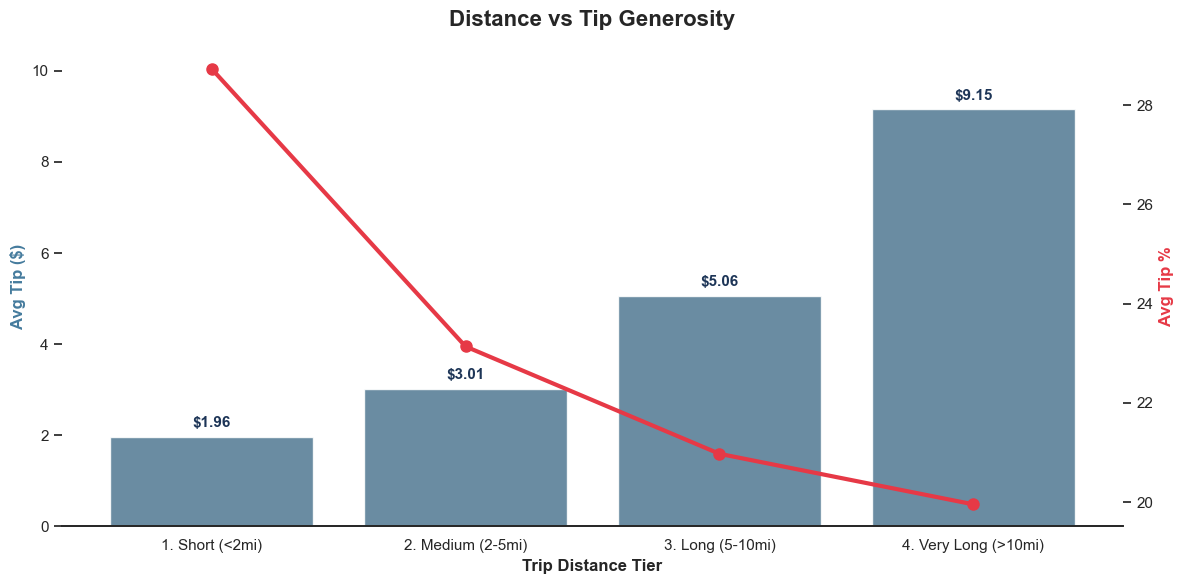

In [41]:
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'

main_color = "#457b9d"
highlight_color = "#e63946"

fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')

sns.barplot(data=q2_pd, x="dist_tier", y="avg_tip_usd", color=main_color, alpha=0.85, ax=ax)
ax.set_title("Distance vs Tip Generosity", fontweight='bold', fontsize=16, pad=15)
ax.set_ylabel("Avg Tip ($)", fontweight='bold', color=main_color)
ax.set_xlabel("Trip Distance Tier", fontweight='bold')

for container in ax.containers:
    ax.bar_label(container, fmt='$%.2f', padding=5, fontweight='bold', color='#1d3557', fontsize=11)

ax.set_ylim(0, q2_pd["avg_tip_usd"].max() * 1.15)

axb = ax.twinx()
axb.plot(range(len(q2_pd)), q2_pd["avg_tip_pct"], color=highlight_color, marker='o', linewidth=3, markersize=8)
axb.set_ylabel("Avg Tip %", fontweight='bold', color=highlight_color)
axb.grid(False)

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

#### Query 3

In [42]:
import time
from pyspark.sql.functions import avg

start_time = time.time()

q3_api_df = taxi_df.selectExpr(
    "avg(fare_amount) as avg_fare",
    "avg(tip_amount) as avg_tip",
    "avg(tolls_amount) as avg_tolls",
    "avg(congestion_surcharge) as avg_surcharge"
)

q3_pd = q3_api_df.toPandas()

q3_api_time = time.time() - start_time
print(f"Q3 PySpark API Time: {q3_api_time:.4f}s")

Q3 PySpark API Time: 0.4760s


In [43]:
start_time = time.time()

q3_sql = spark.sql("""
    SELECT
        AVG(fare_amount) as avg_fare,
        AVG(tip_amount) as avg_tip,
        AVG(tolls_amount) as avg_tolls,
        AVG(congestion_surcharge) as avg_surcharge
    FROM taxi_data
""")

q3_pd_sql = q3_sql.toPandas()
q3_sql_time = time.time() - start_time
print(f"Q3 Spark SQL Time: {q3_sql_time:.4f}s")

Q3 Spark SQL Time: 0.5297s


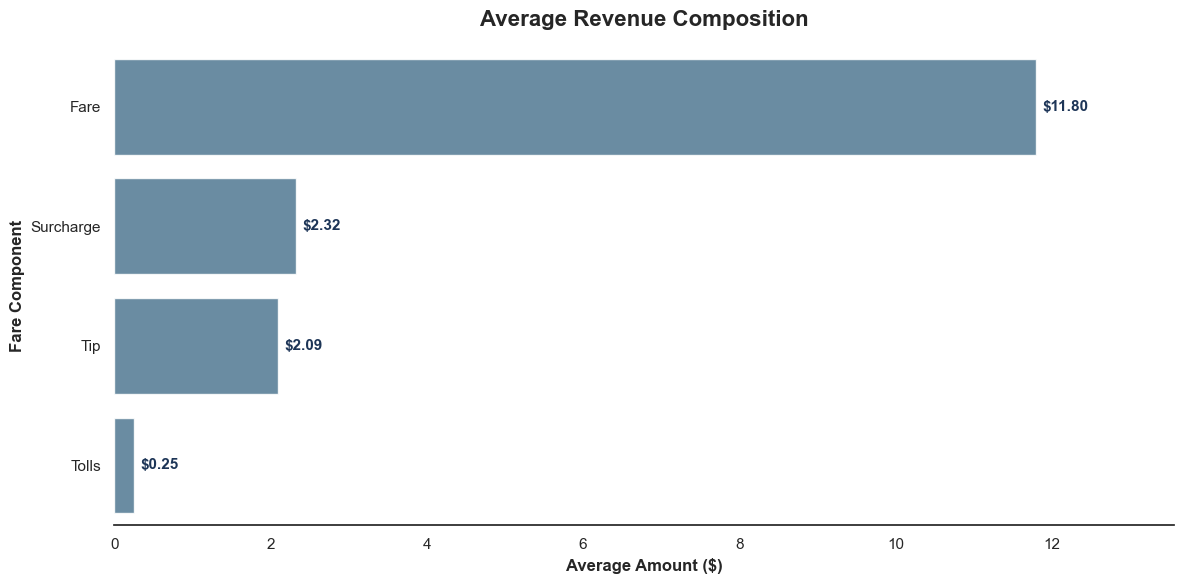

In [44]:
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'

main_color = "#457b9d"

q3_plot = q3_pd.T.reset_index()
q3_plot.columns = ['Component', 'Value']
q3_plot['Component'] = q3_plot['Component'].str.replace('avg_', '').str.title()
q3_plot = q3_plot.sort_values(by='Value', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')

sns.barplot(data=q3_plot, x='Value', y='Component', color=main_color, alpha=0.85, ax=ax)

ax.set_title("Average Revenue Composition", fontweight='bold', fontsize=16, pad=15)
ax.set_xlabel("Average Amount ($)", fontweight='bold')
ax.set_ylabel("Fare Component", fontweight='bold')

for container in ax.containers:
    ax.bar_label(container, fmt='$%.2f', padding=5, fontweight='bold', color='#1d3557', fontsize=11)

ax.set_xlim(0, q3_plot['Value'].max() * 1.15)

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

#### Query 4

In [45]:
from pyspark.sql.functions import when

start_time = time.time()

q4_api_df = taxi_df.withColumn(
    "payment_name",
    when(col("payment_type") == 1, "Credit Card")
    .when(col("payment_type") == 2, "Cash")
    .otherwise("Other")
).groupBy("payment_name") \
 .agg(
    spark_sum("total_amount").alias("total_rev"),
    avg("tip_amount").alias("avg_tip")
)

q4_pd = q4_api_df.toPandas()
q4_api_time = time.time() - start_time
print(f"Q4 PySpark API Time: {q4_api_time:.4f}s")

Q4 PySpark API Time: 0.7773s


In [46]:
start_time = time.time()

q4_sql = spark.sql("""
    SELECT
        CASE
            WHEN payment_type = 1 THEN 'Credit Card'
            WHEN payment_type = 2 THEN 'Cash'
            ELSE 'Other'
        END as payment_name,
        SUM(total_amount) as total_rev,
        AVG(tip_amount) as avg_tip
    FROM taxi_data
    GROUP BY 1
""")

q4_pd_sql = q4_sql.toPandas()
q4_sql_time = time.time() - start_time
print(f"Q4 Spark SQL Time: {q4_sql_time:.4f}s")

Q4 Spark SQL Time: 0.5736s


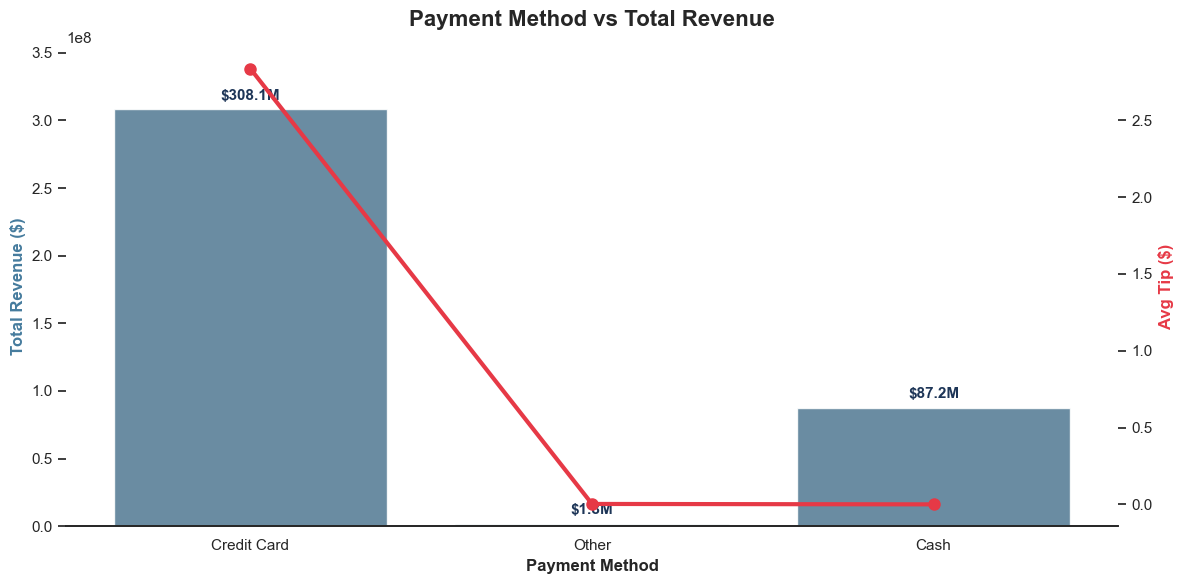

In [47]:
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'

main_color = "#457b9d"
highlight_color = "#e63946"

fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')

sns.barplot(data=q4_pd, x="payment_name", y="total_rev", color=main_color, alpha=0.85, ax=ax)
ax.set_title("Payment Method vs Total Revenue", fontweight='bold', fontsize=16, pad=15)
ax.set_ylabel("Total Revenue ($)", fontweight='bold', color=main_color)
ax.set_xlabel("Payment Method", fontweight='bold')

for container in ax.containers:
    labels = [f"${v/1e6:.1f}M" if v >= 1e6 else f"${v/1e3:.1f}k" for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=5, fontweight='bold', color='#1d3557', fontsize=11)

ax.set_ylim(0, q4_pd["total_rev"].max() * 1.15)

axb = ax.twinx()
axb.plot(q4_pd["payment_name"], q4_pd["avg_tip"], color=highlight_color, marker='o', linewidth=3, markersize=8)
axb.set_ylabel("Avg Tip ($)", fontweight='bold', color=highlight_color)
axb.grid(False)

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

#### Query 5

In [48]:
start_time = time.time()

q5_api_df = taxi_df.filter(col("passenger_count") > 0) \
    .groupBy("passenger_count") \
    .agg(
        avg("total_amount").alias("avg_total"),
        avg("tip_amount").alias("avg_tip"),
        spark_count("*").alias("trip_count")
    ).orderBy("passenger_count")

q5_pd = q5_api_df.toPandas()
q5_api_time = time.time() - start_time
print(f"Q5 PySpark API Time: {q5_api_time:.4f}s")

Q5 PySpark API Time: 1.1410s


In [49]:
start_time = time.time()

q5_sql = spark.sql("""
    SELECT
        passenger_count,
        AVG(total_amount) as avg_total,
        AVG(tip_amount) as avg_tip,
        COUNT(*) as trip_count
    FROM taxi_data
    WHERE passenger_count > 0
    GROUP BY passenger_count
    ORDER BY passenger_count
""")

q5_pd_sql = q5_sql.toPandas()
q5_sql_time = time.time() - start_time
print(f"Q5 Spark SQL Time: {q5_sql_time:.4f}s")

Q5 Spark SQL Time: 0.9440s


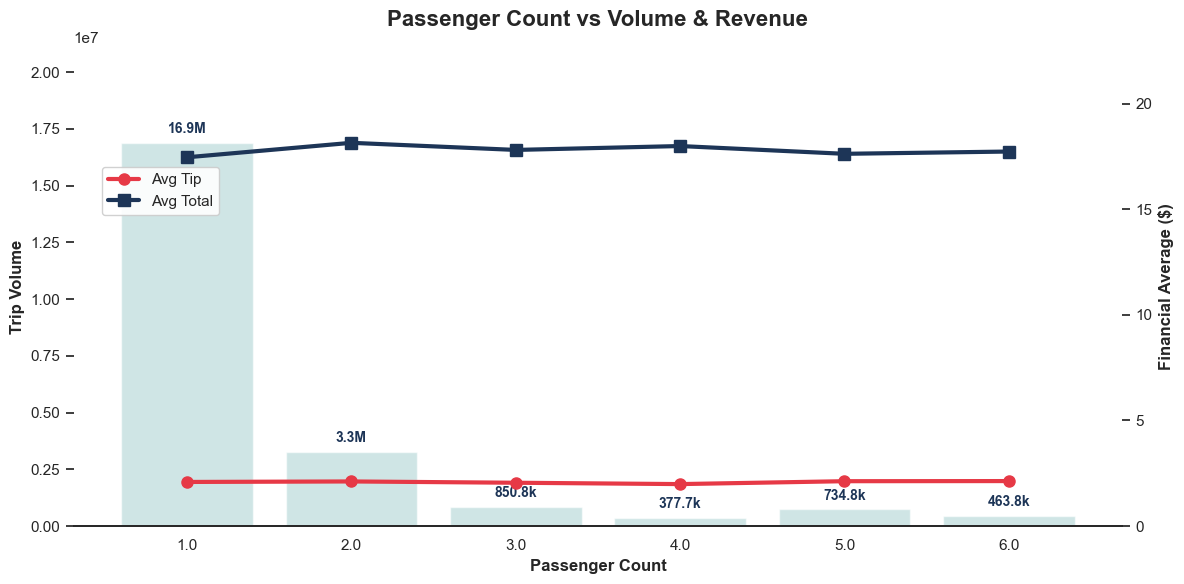

In [50]:
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'

highlight_color = "#e63946"

fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')

sns.barplot(data=q5_pd, x="passenger_count", y="trip_count", color="#a8dadc", alpha=0.6, ax=ax)
ax.set_ylabel("Trip Volume", fontweight='bold')
ax.set_xlabel("Passenger Count", fontweight='bold')

for container in ax.containers:
    labels = [f"{v/1e6:.1f}M" if v >= 1e6 else (f"{v/1e3:.1f}k" if v >= 1e3 else str(int(v))) for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=5, color='#1d3557', fontsize=10, fontweight='bold')

ax.set_ylim(0, q5_pd["trip_count"].max() * 1.25)

axb = ax.twinx()
axb.plot(range(len(q5_pd)), q5_pd["avg_tip"], color=highlight_color, marker='o', linewidth=3, label="Avg Tip", markersize=8)
axb.plot(range(len(q5_pd)), q5_pd["avg_total"], color="#1d3557", marker='s', linewidth=3, label="Avg Total", markersize=8)
axb.set_ylabel("Financial Average ($)", fontweight='bold')

axb.set_ylim(0, q5_pd["avg_total"].max() * 1.25)
axb.legend(loc='center left', bbox_to_anchor=(0.02, 0.7), frameon=True, facecolor='white', framealpha=0.9, edgecolor='#cccccc')

ax.set_title("Passenger Count vs Volume & Revenue", fontsize=16, fontweight='bold', pad=15)

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

#### Query 6

Spark

In [55]:
start_time = time.time()

q6_api_df = taxi_df.filter((col("payment_type") == 1) & (col("fare_amount") > 0)) \
    .withColumn("tip_pct", (col("tip_amount") / col("fare_amount")) * 100) \
    .filter(col("tip_pct") <= 100) \
    .groupBy("pickup_hour") \
    .agg(avg("tip_pct").alias("avg_tip_pct")) \
    .orderBy("pickup_hour")

q6_pd = q6_api_df.toPandas()

q6_api_time = time.time() - start_time

print(f"Q6 PySpark API Time: {q6_api_time:.4f}s")

Q6 PySpark API Time: 1.3779s


SQL

In [56]:
start_time = time.time()

q6_sql = spark.sql("""
    SELECT
        pickup_hour,
        AVG((tip_amount / fare_amount) * 100) AS avg_tip_pct
    FROM taxi_data
    WHERE payment_type = 1
      AND fare_amount > 0
      AND (tip_amount / fare_amount) * 100 <= 100
    GROUP BY pickup_hour
    ORDER BY pickup_hour
""")

q6_pd_sql = q6_sql.toPandas()

q6_sql_time = time.time() - start_time

print(f"Q6 Spark SQL Time: {q6_sql_time:.4f}s")

Q6 Spark SQL Time: 1.2571s


Visualization

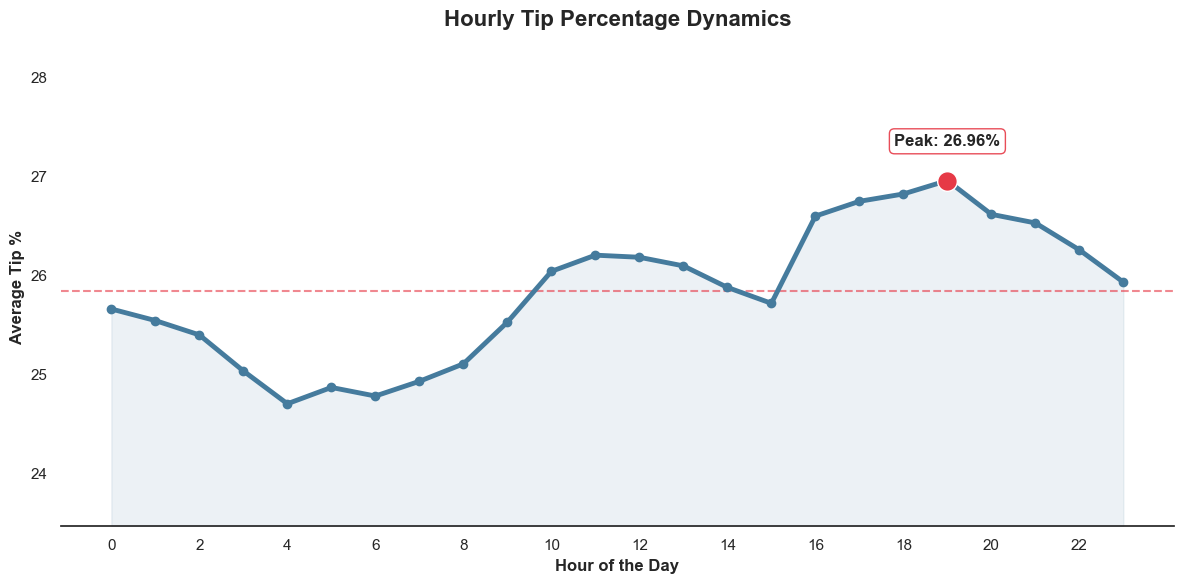

In [58]:
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'

main_color = "#457b9d"
highlight_color = "#e63946"

fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')

peak_row = q6_pd.loc[q6_pd['avg_tip_pct'].idxmax()]
peak_hour, peak_tip = int(peak_row['pickup_hour']), peak_row['avg_tip_pct']
global_avg = q6_pd['avg_tip_pct'].mean()

y_min = q6_pd["avg_tip_pct"].min() * 0.95
y_max = q6_pd["avg_tip_pct"].max() * 1.05

ax.plot(q6_pd["pickup_hour"], q6_pd["avg_tip_pct"], marker='o', linewidth=3.5, color=main_color, zorder=3)

ax.fill_between(q6_pd["pickup_hour"], q6_pd["avg_tip_pct"], y_min, alpha=0.1, color=main_color)

ax.axhline(global_avg, linestyle='--', color=highlight_color, alpha=0.6, label="Global Avg")
ax.scatter(peak_hour, peak_tip, s=200, color=highlight_color, zorder=5, edgecolor='white')

ax.annotate(f'Peak: {peak_tip:.2f}%', (peak_hour, peak_tip), xytext=(0, 25),
            textcoords='offset points', ha='center', fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=highlight_color, alpha=0.9), zorder=6)

ax.set_title("Hourly Tip Percentage Dynamics", fontsize=16, fontweight='bold', pad=15)
ax.set_xticks(range(0, 24, 2))
ax.set_ylabel("Average Tip %", fontweight='bold')
ax.set_xlabel("Hour of the Day", fontweight='bold')

ax.set_ylim(y_min, y_max)

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

#### Query 7

Spark

In [62]:
start_time = time.time()

# 1. Isolate the Top 8 Zones
top_zones_df = taxi_df.groupBy("PU_Zone") \
    .agg(_sum("total_amount").alias("tot_rev")) \
    .orderBy(desc("tot_rev")) \
    .limit(8).toPandas()
top_zones_list = top_zones_df['PU_Zone'].tolist()

# 2. Hourly revenue for these zones
hourly_zones = taxi_df.filter(col("PU_Zone").isin(top_zones_list)) \
    .groupBy("pickup_hour", "PU_Zone") \
    .agg(_sum("total_amount").alias("hourly_revenue"))

# 3. Calculate RANKING (1 to 8) within each hour
window_hour = Window.partitionBy("pickup_hour").orderBy(desc("hourly_revenue"))
q7_api_df = hourly_zones.withColumn("rank", rank().over(window_hour))

q7_pd = q7_api_df.toPandas()

q7_api_time = time.time() - start_time

print(f"Q7 PySpark API Time: {q7_api_time:.4f}s")

Q7 PySpark API Time: 6.4901s


SQL

In [64]:
start_time = time.time()

q7_sql = spark.sql("""
    WITH TopZones AS (
        SELECT PU_Zone, SUM(total_amount) as tot_rev
        FROM taxi_data
        GROUP BY PU_Zone
        ORDER BY tot_rev DESC
        LIMIT 8
    ),
    HourlyZones AS (
        SELECT
            t.pickup_hour,
            t.PU_Zone,
            SUM(t.total_amount) as hourly_revenue
        FROM taxi_data t
        INNER JOIN TopZones tz ON t.PU_Zone = tz.PU_Zone
        GROUP BY t.pickup_hour, t.PU_Zone
    ),
    RankedZones AS (
        SELECT
            pickup_hour,
            PU_Zone,
            hourly_revenue,
            RANK() OVER (PARTITION BY pickup_hour ORDER BY hourly_revenue DESC) as rank
        FROM HourlyZones
    )
    SELECT * FROM RankedZones ORDER BY pickup_hour, rank
""")

q7_pd_sql = q7_sql.toPandas()

q7_sql_time = time.time() - start_time

print(f"Q7 Spark SQL Time: {q7_sql_time:.4f}s")

Q7 Spark SQL Time: 7.9293s


Visualization

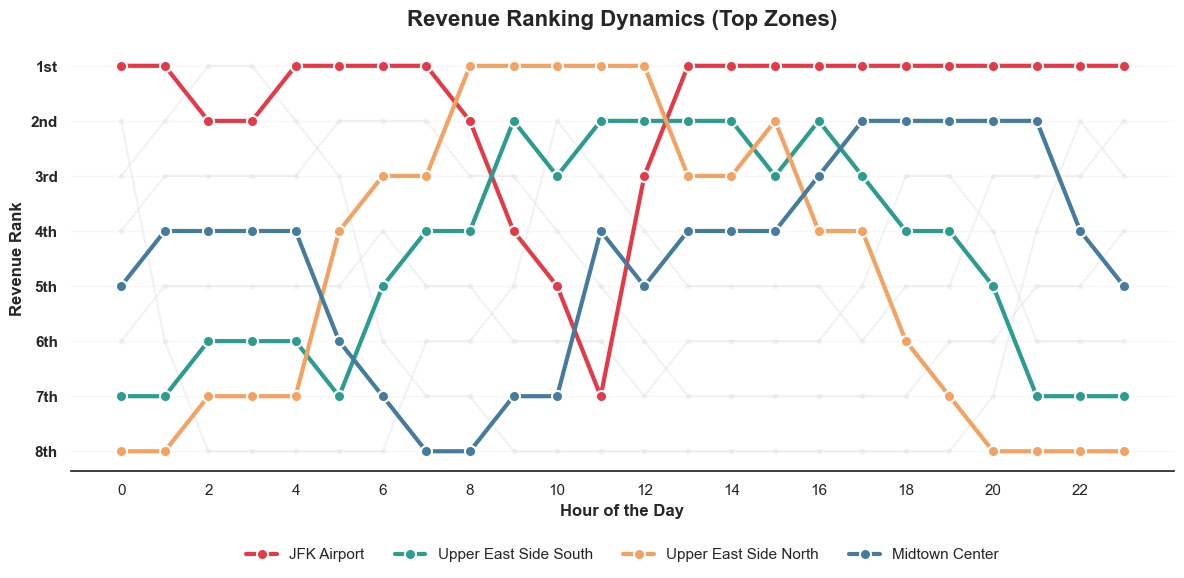

In [65]:
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')

top_zone_colors = ['#e63946', '#2a9d8f', '#f4a261', '#457b9d']

for i, zone in enumerate(top_zones_list):
    zone_data = q7_pd[q7_pd['PU_Zone'] == zone].sort_values('pickup_hour')
    is_top = i < 4
    color = top_zone_colors[i] if is_top else '#e0e0e0'
    ax.plot(zone_data['pickup_hour'], zone_data['rank'], marker='o', 
            linewidth=3 if is_top else 1.5, alpha=1 if is_top else 0.4,
            markersize=8 if is_top else 4, label=zone if is_top else None, color=color,
            markeredgecolor='white', markeredgewidth=1.5 if is_top else 0, zorder=5 if is_top else 1)

ax.invert_yaxis()
ax.set_yticks(range(1, 9))
ax.set_yticklabels(["1st", "2nd", "3rd", "4th", "5th", "6th", "7th", "8th"], fontweight='bold')
ax.set_xticks(range(0, 24, 2))
ax.set_title("Revenue Ranking Dynamics (Top Zones)", fontsize=16, fontweight='bold', pad=15)
ax.set_ylabel("Revenue Rank", fontweight='bold')
ax.set_xlabel("Hour of the Day", fontweight='bold')
ax.grid(axis='y', alpha=0.15)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, frameon=False, fontsize=11)

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

#### Query 8

Spark

In [68]:
start_time = time.time()

route_agg = taxi_df.groupBy("PU_Borough", "DO_Borough") \
    .agg(_sum("total_amount").alias("rev"))

windowRank = Window.partitionBy("PU_Borough").orderBy(desc("rev"))
windowBorough = Window.partitionBy("PU_Borough")

q8_api_df = route_agg \
    .withColumn("rank", rank().over(windowRank)) \
    .withColumn("max_borough_rev", spark_max("rev").over(windowBorough)) \
    .withColumn("total_borough_rev", _sum("rev").over(windowBorough)) \
    .filter(col("rank") <= 3) \
    .orderBy(desc("total_borough_rev"), desc("rev"))

q8_pd = q8_api_df.toPandas()

q8_api_time = time.time() - start_time

print(f"Q8 PySpark API Time: {q8_api_time:.4f}s")

Q8 PySpark API Time: 1.6816s


SQL

In [69]:
start_time = time.time()

q8_sql = spark.sql("""
    WITH RouteAgg AS (
        SELECT
            PU_Borough,
            DO_Borough,
            SUM(total_amount) as rev
        FROM taxi_data
        GROUP BY PU_Borough, DO_Borough
    ),
    Ranked AS (
        SELECT
            PU_Borough,
            DO_Borough,
            rev,
            ROW_NUMBER() OVER(PARTITION BY PU_Borough ORDER BY rev DESC) as rank,
            MAX(rev) OVER(PARTITION BY PU_Borough) as max_borough_rev,
            SUM(rev) OVER(PARTITION BY PU_Borough) as total_borough_rev
        FROM RouteAgg
    )
    SELECT * FROM Ranked
    WHERE rank <= 3
    ORDER BY total_borough_rev DESC, rev DESC
""")

q8_pd_sql = q8_sql.toPandas()

q8_sql_time = time.time() - start_time

print(f"Q8 Spark SQL Time: {q8_sql_time:.4f}s")

Q8 Spark SQL Time: 2.6028s


Visualization

/var/folders/yp/65klpy9935xg61n4lft7zjrm0000gn/T/ipykernel_17206/1129047671.py:55: UserWarning: Glyph 10132 (\N{HEAVY WIDE-HEADED RIGHTWARDS ARROW}) missing from font(s) Arial.
  plt.tight_layout()
/Users/luanalima/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10132 (\N{HEAVY WIDE-HEADED RIGHTWARDS ARROW}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


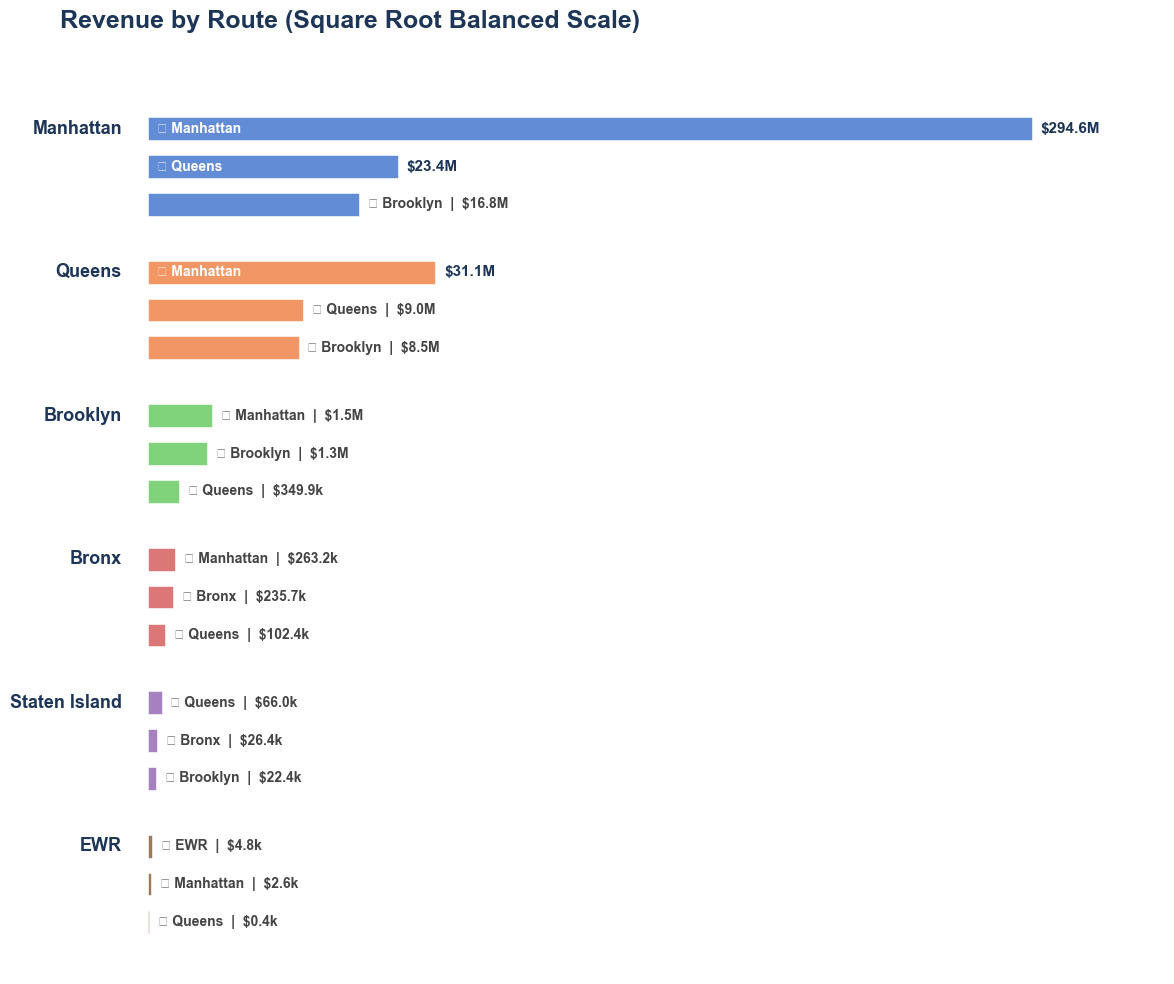

In [70]:
q8_pd['sqrt_rev'] = np.sqrt(q8_pd['rev'])
q8_pd['bar_length'] = q8_pd['sqrt_rev'] / q8_pd['sqrt_rev'].max()
q8_pd['Dest_Label'] = "\u2794 " + q8_pd['DO_Borough']

y_positions, current_y = [], 0
for i, rnk in enumerate(q8_pd['rank']):
    if rnk == 1 and i != 0:
        current_y += 1.8
    else:
        current_y += 1.0
    y_positions.append(current_y)
q8_pd['y_pos'] = y_positions

plt.figure(figsize=(12, 10), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')

palette = sns.color_palette("muted", n_colors=len(q8_pd['PU_Borough'].unique()))
color_dict = dict(zip(q8_pd['PU_Borough'].unique(), palette))

bars = ax.barh(q8_pd['y_pos'], q8_pd['bar_length'],
                color=[color_dict[b] for b in q8_pd['PU_Borough']],
                height=0.6, alpha=0.85, edgecolor='white', linewidth=0.5)

for row in q8_pd.itertuples():
    if row.rev >= 1000000:
        money_text = f"${row.rev / 1_000_000:.1f}M"
    else:
        money_text = f"${row.rev / 1_000:.1f}k"

    if row.rank == 1:
        plt.text(-0.03, row.y_pos, f"{row.PU_Borough}", ha='right', va='center',
                 fontsize=13, fontweight='900', color='#1d3557')

    if row.bar_length > 0.28:
        plt.text(0.01, row.y_pos, row.Dest_Label, ha='left', va='center',
                 fontsize=10, fontweight='bold', color='white')
        plt.text(row.bar_length + 0.01, row.y_pos, money_text, ha='left', va='center',
                 fontsize=11, fontweight='bold', color='#1d3557')
    else:
        combined_text = f"{row.Dest_Label}  |  {money_text}"
        plt.text(row.bar_length + 0.01, row.y_pos, combined_text,
                 ha='left', va='center', fontsize=10, fontweight='bold', color='#444444')

plt.yticks([])
plt.xticks([])
plt.gca().invert_yaxis()

plt.title("Revenue by Route (Square Root Balanced Scale)",
          fontsize=18, fontweight='900', pad=35, color='#1d3557', loc='left')

plt.xlim(-0.10, 1.15)

sns.despine(left=True, bottom=True, right=True, top=True)
plt.tight_layout()
plt.show()

#### Dashboard

First Dashboard

/var/folders/yp/65klpy9935xg61n4lft7zjrm0000gn/T/ipykernel_17206/3836434852.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


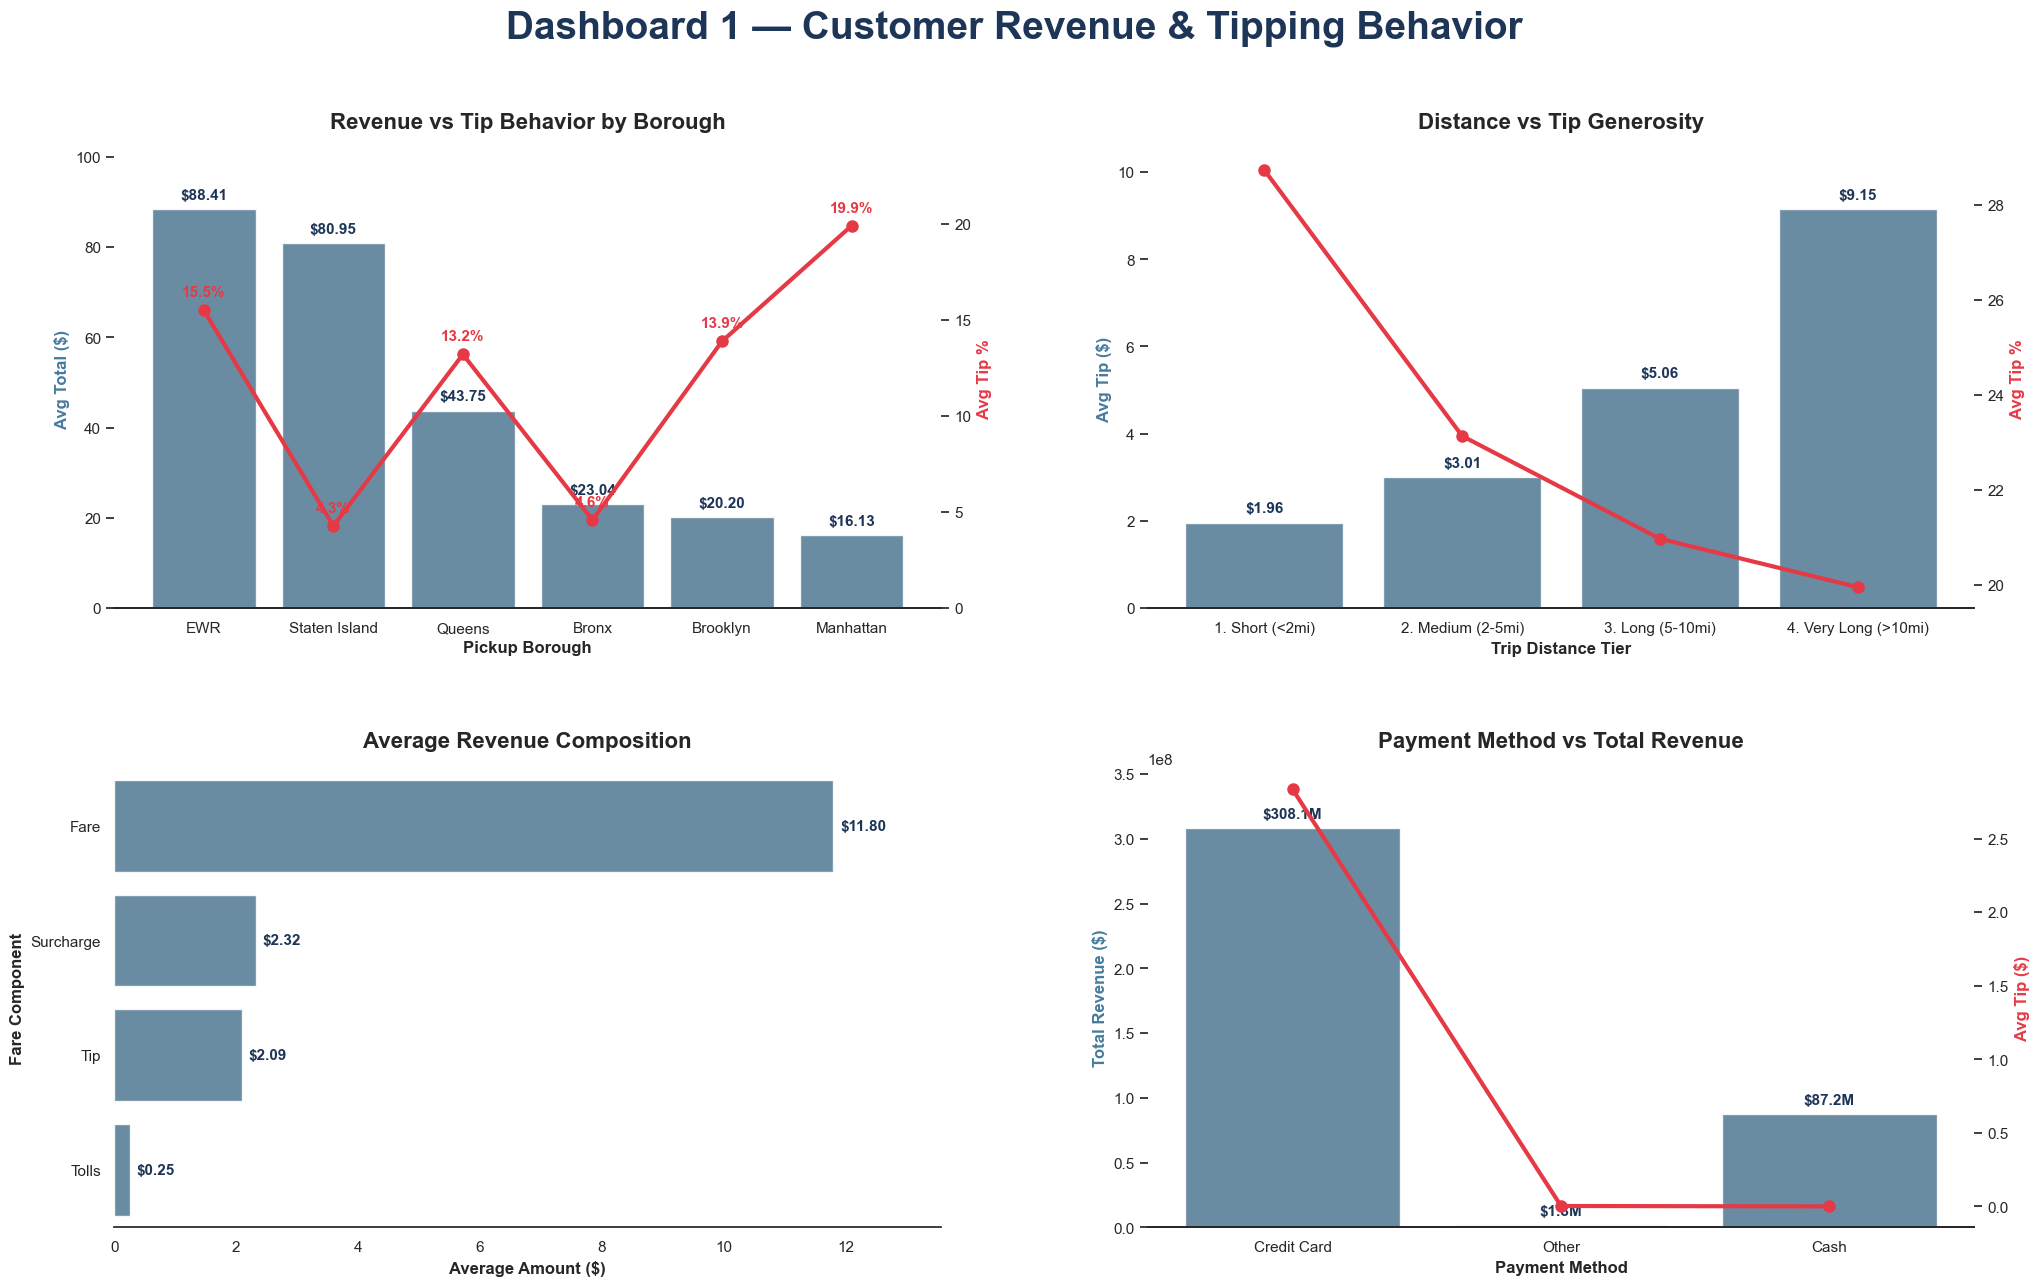

In [71]:
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'

fig = plt.figure(figsize=(24, 14), facecolor='white')
gs = GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.25)

fig.suptitle(
    "Dashboard 1 — Customer Revenue & Tipping Behavior",
    fontsize=28, fontweight='bold', y=0.98, color="#1d3557"
)

main_color = "#457b9d"
highlight_color = "#e63946"

# Q1 — TOP LEFT: Borough Revenue vs Tip Percentage
ax1 = fig.add_subplot(gs[0, 0])

sns.barplot(data=q1_pd, x="PU_Borough", y="avg_total", color=main_color, alpha=0.85, ax=ax1)
ax1.set_title("Revenue vs Tip Behavior by Borough", fontweight='bold', fontsize=16, pad=15)
ax1.set_ylabel("Avg Total ($)", fontweight='bold', color=main_color)
ax1.set_xlabel("Pickup Borough", fontweight='bold')

for container in ax1.containers:
    ax1.bar_label(container, fmt='$%.2f', padding=5, fontweight='bold', color='#1d3557', fontsize=11)

ax1.set_ylim(0, q1_pd["avg_total"].max() * 1.15)

ax1b = ax1.twinx()
ax1b.plot(q1_pd["PU_Borough"], q1_pd["avg_tip_pct"], color=highlight_color, marker='o', linewidth=3, markersize=8)
ax1b.set_ylabel("Avg Tip %", fontweight='bold', color=highlight_color)
ax1b.grid(False)

for i, val in enumerate(q1_pd["avg_tip_pct"]):
    ax1b.annotate(f'{val:.1f}%', (i, val), textcoords="offset points", xytext=(0, 10),
                  ha='center', color=highlight_color, fontweight='bold', fontsize=11)

ax1b.set_ylim(0, q1_pd["avg_tip_pct"].max() * 1.20)

# Q2 — TOP RIGHT: Tip Paradox by Distance
ax2 = fig.add_subplot(gs[0, 1])

sns.barplot(data=q2_pd, x="dist_tier", y="avg_tip_usd", color=main_color, alpha=0.85, ax=ax2)
ax2.set_title("Distance vs Tip Generosity", fontweight='bold', fontsize=16, pad=15)
ax2.set_ylabel("Avg Tip ($)", fontweight='bold', color=main_color)
ax2.set_xlabel("Trip Distance Tier", fontweight='bold')

for container in ax2.containers:
    ax2.bar_label(container, fmt='$%.2f', padding=5, fontweight='bold', color='#1d3557', fontsize=11)

ax2.set_ylim(0, q2_pd["avg_tip_usd"].max() * 1.15)

ax2b = ax2.twinx()
ax2b.plot(range(len(q2_pd)), q2_pd["avg_tip_pct"], color=highlight_color, marker='o', linewidth=3, markersize=8)
ax2b.set_ylabel("Avg Tip %", fontweight='bold', color=highlight_color)
ax2b.grid(False)

# Q3 — BOTTOM LEFT: Revenue Composition
ax3 = fig.add_subplot(gs[1, 0])

q3_plot = q3_pd.T.reset_index()
q3_plot.columns = ['Component', 'Value']
q3_plot['Component'] = q3_plot['Component'].str.replace('avg_', '').str.title()
q3_plot = q3_plot.sort_values(by='Value', ascending=False)

sns.barplot(data=q3_plot, x='Value', y='Component', color=main_color, alpha=0.85, ax=ax3)

ax3.set_title("Average Revenue Composition", fontweight='bold', fontsize=16, pad=15)
ax3.set_xlabel("Average Amount ($)", fontweight='bold')
ax3.set_ylabel("Fare Component", fontweight='bold')

for container in ax3.containers:
    ax3.bar_label(container, fmt='$%.2f', padding=5, fontweight='bold', color='#1d3557', fontsize=11)

ax3.set_xlim(0, q3_plot['Value'].max() * 1.15)

# Q4 — BOTTOM RIGHT: Payment Method Impact
ax4 = fig.add_subplot(gs[1, 1])

sns.barplot(data=q4_pd, x="payment_name", y="total_rev", color=main_color, alpha=0.85, ax=ax4)
ax4.set_title("Payment Method vs Total Revenue", fontweight='bold', fontsize=16, pad=15)
ax4.set_ylabel("Total Revenue ($)", fontweight='bold', color=main_color)
ax4.set_xlabel("Payment Method", fontweight='bold')

for container in ax4.containers:
    labels = [f"${v/1e6:.1f}M" if v >= 1e6 else f"${v/1e3:.1f}k" for v in container.datavalues]
    ax4.bar_label(container, labels=labels, padding=5, fontweight='bold', color='#1d3557', fontsize=11)

ax4.set_ylim(0, q4_pd["total_rev"].max() * 1.15)

ax4b = ax4.twinx()
ax4b.plot(q4_pd["payment_name"], q4_pd["avg_tip"], color=highlight_color, marker='o', linewidth=3, markersize=8)
ax4b.set_ylabel("Avg Tip ($)", fontweight='bold', color=highlight_color)
ax4b.grid(False)

sns.despine(left=True, bottom=False)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Second Dashboard

/Users/luanalima/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10132 (\N{HEAVY WIDE-HEADED RIGHTWARDS ARROW}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


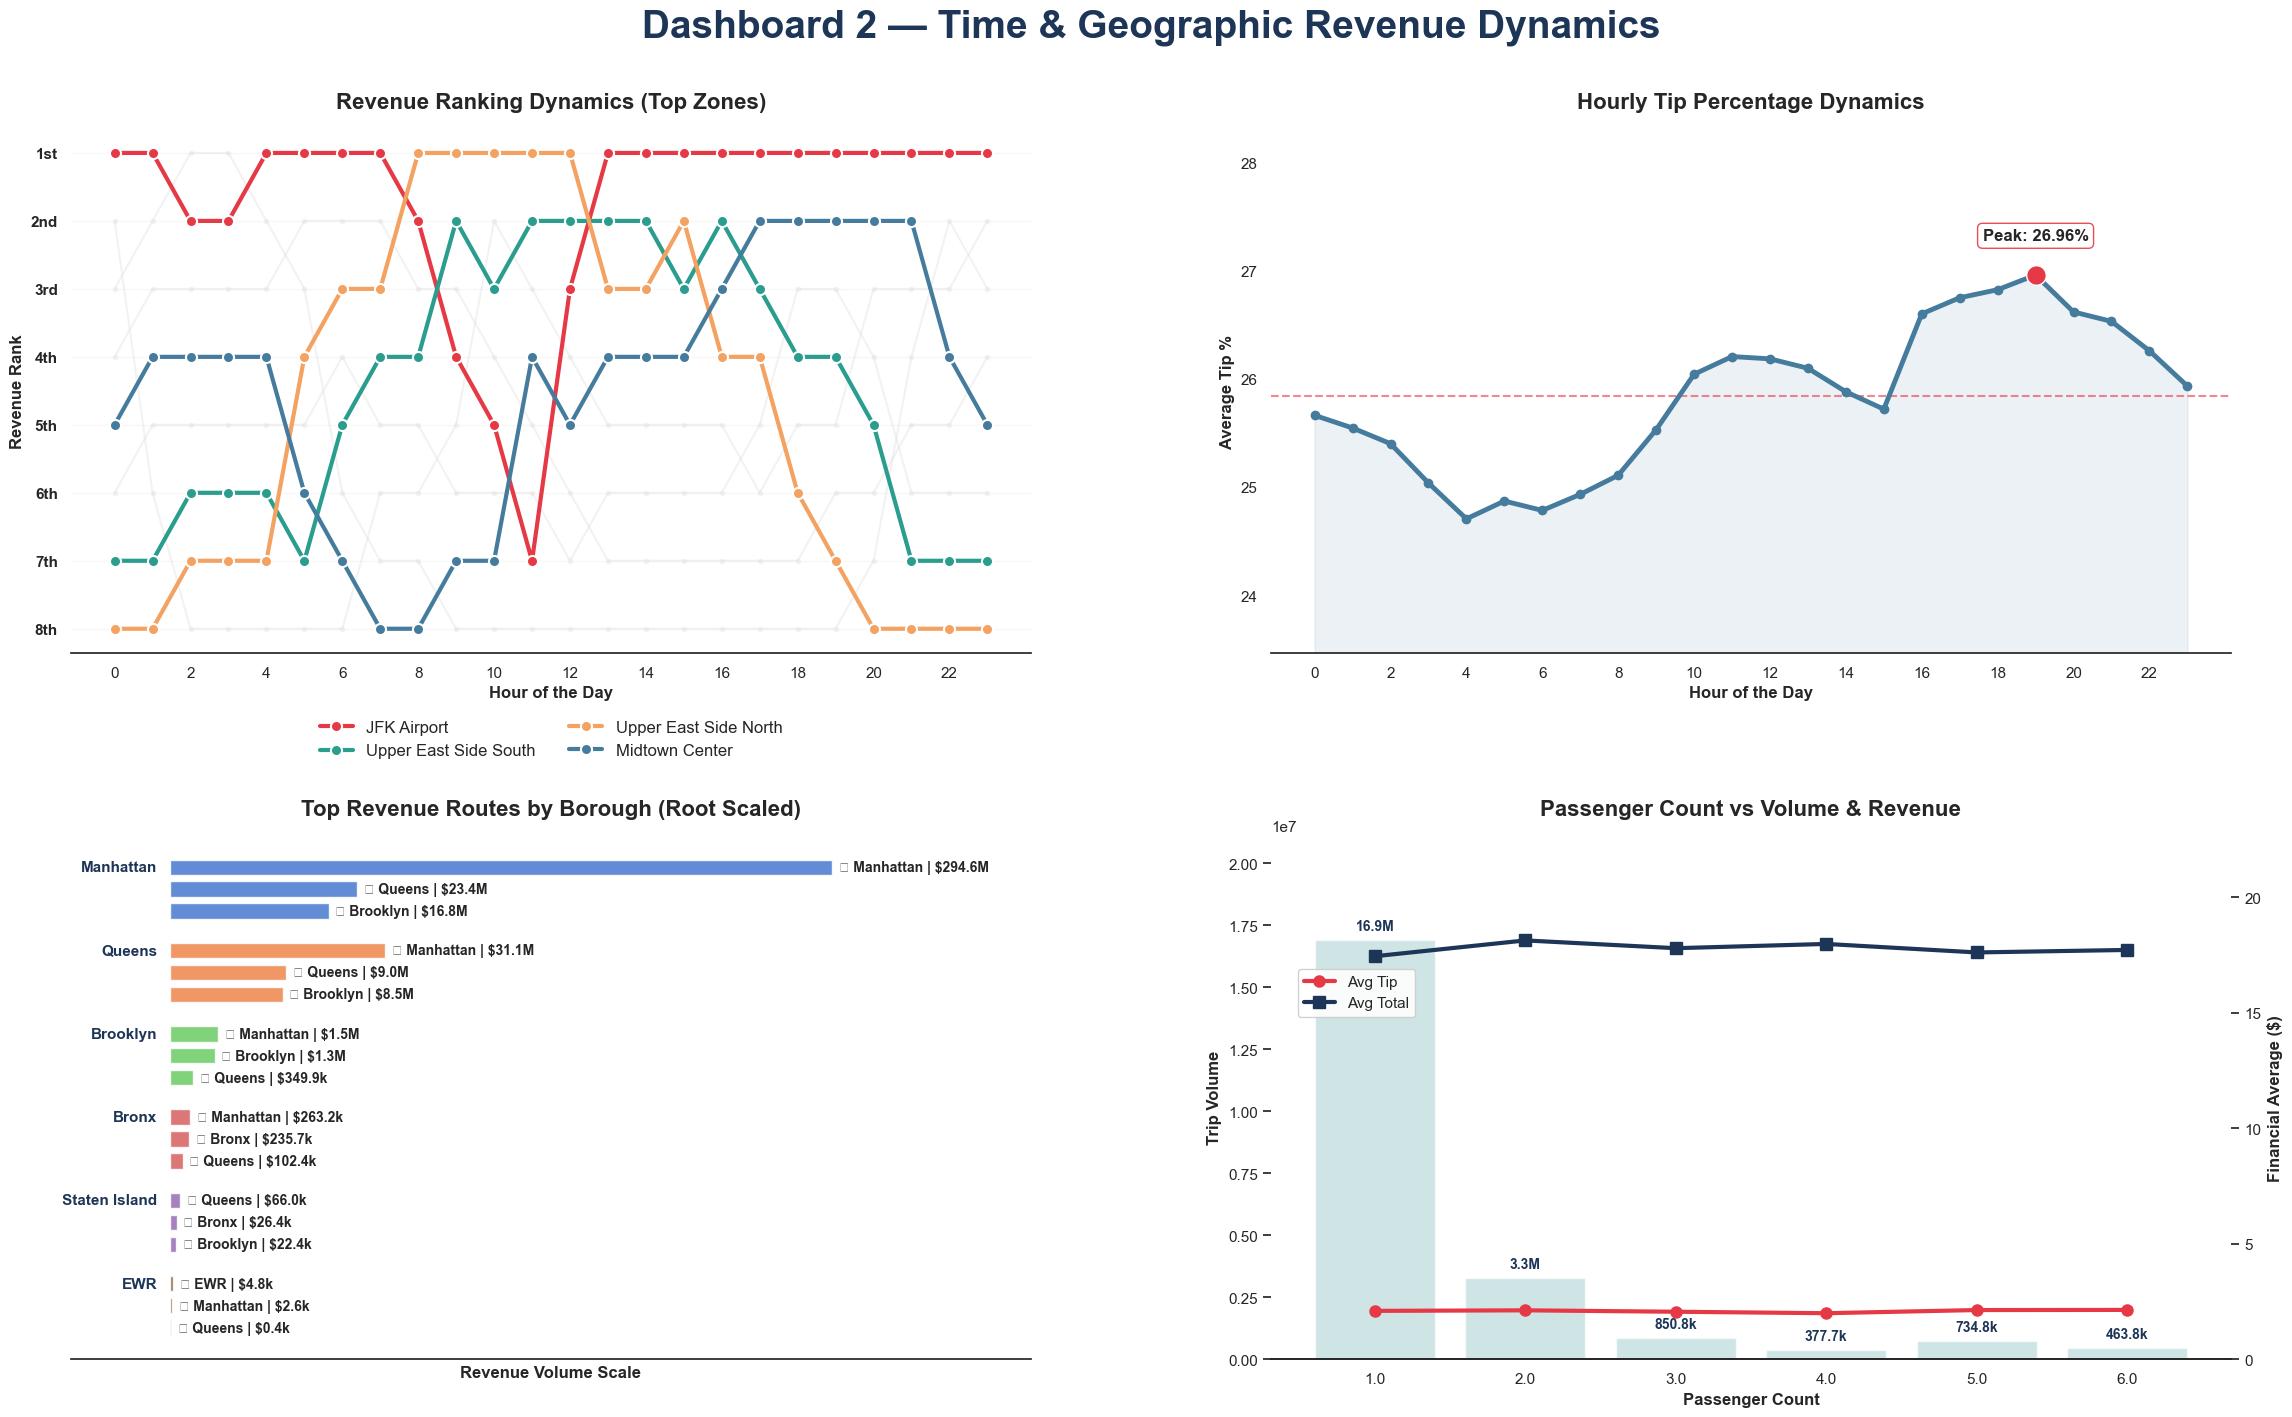

In [73]:
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'

fig = plt.figure(figsize=(24, 15), facecolor='white')

gs = GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.25)

fig.suptitle(
    "Dashboard 2 — Time & Geographic Revenue Dynamics",
    fontsize=28, fontweight='bold', color="#1d3557", y=0.98
)

main_color = "#457b9d"
highlight_color = "#e63946"

# Q7: TOP LEFT (Ranked Zones)
ax1 = fig.add_subplot(gs[0, 0])
top_zone_colors = ['#e63946', '#2a9d8f', '#f4a261', '#457b9d']

for i, zone in enumerate(top_zones_list):
    zone_data = q7_pd[q7_pd['PU_Zone'] == zone].sort_values('pickup_hour')
    is_top = i < 4
    color = top_zone_colors[i] if is_top else '#e0e0e0'
    ax1.plot(zone_data['pickup_hour'], zone_data['rank'], marker='o', 
             linewidth=3 if is_top else 1.5, alpha=1 if is_top else 0.4,
             markersize=8 if is_top else 4, label=zone if is_top else None, color=color,
             markeredgecolor='white', markeredgewidth=1.5 if is_top else 0, zorder=5 if is_top else 1)

ax1.invert_yaxis()
ax1.set_yticks(range(1, 9))
ax1.set_yticklabels(["1st", "2nd", "3rd", "4th", "5th", "6th", "7th", "8th"], fontweight='bold')
ax1.set_xticks(range(0, 24, 2))
ax1.set_title("Revenue Ranking Dynamics (Top Zones)", fontsize=16, fontweight='bold', pad=15)
ax1.set_ylabel("Revenue Rank", fontweight='bold')
ax1.set_xlabel("Hour of the Day", fontweight='bold')
ax1.grid(axis='y', alpha=0.15)

ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.10), ncol=2, frameon=False, fontsize=12)

# Q6: TOP RIGHT (Hourly Tip %)
ax2 = fig.add_subplot(gs[0, 1])
peak_row = q6_pd.loc[q6_pd['avg_tip_pct'].idxmax()]
peak_hour, peak_tip = int(peak_row['pickup_hour']), peak_row['avg_tip_pct']
global_avg = q6_pd['avg_tip_pct'].mean()

y_min = q6_pd["avg_tip_pct"].min() * 0.95
y_max = q6_pd["avg_tip_pct"].max() * 1.05

ax2.plot(q6_pd["pickup_hour"], q6_pd["avg_tip_pct"], marker='o', linewidth=3.5, color=main_color, zorder=3)
ax2.fill_between(q6_pd["pickup_hour"], q6_pd["avg_tip_pct"], y_min, alpha=0.1, color=main_color)
ax2.axhline(global_avg, linestyle='--', color=highlight_color, alpha=0.6, label="Global Avg")
ax2.scatter(peak_hour, peak_tip, s=200, color=highlight_color, zorder=5, edgecolor='white')

ax2.annotate(f'Peak: {peak_tip:.2f}%', (peak_hour, peak_tip), xytext=(0, 25),
             textcoords='offset points', ha='center', fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=highlight_color, alpha=0.9), zorder=6)

ax2.set_title("Hourly Tip Percentage Dynamics", fontsize=16, fontweight='bold', pad=15)
ax2.set_xticks(range(0, 24, 2))
ax2.set_ylabel("Average Tip %", fontweight='bold')
ax2.set_xlabel("Hour of the Day", fontweight='bold')
ax2.set_ylim(y_min, y_max)

# Q8: BOTTOM LEFT (Revenue Routes)
ax3 = fig.add_subplot(gs[1, 0])
palette = sns.color_palette("muted", n_colors=len(q8_pd['PU_Borough'].unique()))
color_dict = dict(zip(q8_pd['PU_Borough'].unique(), palette))

ax3.barh(q8_pd['y_pos'], q8_pd['bar_length'], height=0.7,
         color=[color_dict[b] for b in q8_pd['PU_Borough']], alpha=0.85)

for row in q8_pd.itertuples():
    money_text = f"${row.rev/1e6:.1f}M" if row.rev >= 1e6 else f"${row.rev/1e3:.1f}k"

    if row.rank == 1:
        ax3.text(-0.02, row.y_pos, row.PU_Borough, ha='right', va='center', fontweight='bold', color='#1d3557', fontsize=11)

    label_x = row.bar_length + 0.01
    ax3.text(label_x, row.y_pos, f"{row.Dest_Label} | {money_text}", va='center', fontsize=10, fontweight='bold')

ax3.set_title("Top Revenue Routes by Borough (Root Scaled)", fontsize=16, fontweight='bold', pad=15)
ax3.set_yticks([])
ax3.set_xticks([])
ax3.invert_yaxis()
ax3.set_xlim(-0.15, 1.3)
ax3.set_xlabel("Revenue Volume Scale", fontweight='bold')

# Q5: BOTTOM RIGHT (Passenger Count)
ax4 = fig.add_subplot(gs[1, 1])
sns.barplot(data=q5_pd, x="passenger_count", y="trip_count", color="#a8dadc", alpha=0.6, ax=ax4)
ax4.set_ylabel("Trip Volume", fontweight='bold')
ax4.set_xlabel("Passenger Count", fontweight='bold')

for container in ax4.containers:
    labels = [f"{v/1e6:.1f}M" if v >= 1e6 else (f"{v/1e3:.1f}k" if v >= 1e3 else str(int(v))) for v in container.datavalues]
    ax4.bar_label(container, labels=labels, padding=5, color='#1d3557', fontsize=10, fontweight='bold')

ax4.set_ylim(0, q5_pd["trip_count"].max() * 1.25)

ax4b = ax4.twinx()
ax4b.plot(range(len(q5_pd)), q5_pd["avg_tip"], color=highlight_color, marker='o', linewidth=3, label="Avg Tip", markersize=8)
ax4b.plot(range(len(q5_pd)), q5_pd["avg_total"], color="#1d3557", marker='s', linewidth=3, label="Avg Total", markersize=8)
ax4b.set_ylabel("Financial Average ($)", fontweight='bold')

ax4b.set_ylim(0, q5_pd["avg_total"].max() * 1.25)
ax4b.legend(loc='center left', bbox_to_anchor=(0.02, 0.7), frameon=True, facecolor='white', framealpha=0.9, edgecolor='#cccccc')

ax4.set_title("Passenger Count vs Volume & Revenue", fontsize=16, fontweight='bold', pad=15)

sns.despine(fig=fig, left=True, bottom=False)

plt.subplots_adjust(top=0.90, bottom=0.08, left=0.05, right=0.95)
plt.show()

#### Dashboard 1 — Customer Revenue & Tipping Behavior

This dashboard explores the relationship between customer spending patterns, tipping behavior, payment methods, and trip characteristics across New York City taxi operations. It provides insight into how revenue is generated and how customer behavior varies according to geography, trip distance, and payment preferences.

##### Business Questions Addressed

* Which boroughs generate the highest-value trips and the most generous tipping behavior?
* Does a higher trip cost or longer distance lead to proportionally larger tips?
* What are the main components contributing to the average trip revenue?
* How do payment methods influence both total revenue and driver gratuities?

##### Overall Insight

The analysis reveals a clear paradox in customer tipping behavior: higher fares and longer trips do not necessarily produce higher tipping percentages. In addition, the dashboard demonstrates the strategic importance of electronic payments, particularly credit card transactions, which consistently generate significantly higher revenue and recorded gratuities than cash payments.

##### Chart-Level Insights

###### Revenue vs. Tip Behavior by Borough

An inverse relationship emerges between average trip cost and tip percentage across boroughs. Trips originating from EWR Airport and Staten Island generate the highest average revenues ($90.10 and $79.51, respectively), while Manhattan records the highest average tipping percentage (19.8%) despite having the lowest average trip cost ($16.44). This suggests that lower-cost urban trips may encourage proportionally more generous tipping behavior.

###### Distance vs. Tip Generosity

The analysis indicates evidence of “tip fatigue” on longer journeys. Although the absolute value of tips increases with trip distance, reaching an average of $9.15 for trips exceeding 10 miles, the proportional generosity of passengers declines substantially. Average tip percentages decrease from approximately 28% on short trips to nearly 20% on very long trips.

###### Average Revenue Composition

The fare amount constitutes the largest component of average trip revenue, with an average contribution of $12.40 per trip. Interestingly, mandatory surcharges ($2.29) slightly exceed voluntary gratuities ($2.08), highlighting the growing importance of operational and regulatory fees within the overall revenue structure.

###### Payment Method vs. Total Revenue

Credit card payments dominate the taxi economy, accounting for approximately $310 million in total revenue and generating the highest average gratuities. By contrast, cash payments produce substantially lower recorded tip values despite contributing $88.2 million in revenue. This discrepancy likely reflects the inability to capture informal cash tipping within the dataset.

---

#### Dashboard 2 — Time & Geographic Revenue Dynamics

This dashboard focuses on the temporal and spatial distribution of taxi revenue, highlighting how revenue generation evolves throughout the day and across different geographic areas. It also examines the concentration of profitable routes and the operational impact of passenger group size.

##### Business Questions Addressed

* At what times of day are drivers most likely to receive higher gratuities?
* Which pickup zones consistently dominate revenue generation throughout the day?
* Which origin–destination routes contribute most significantly to total market revenue?
* How does passenger count influence trip volume and financial return?

##### Overall Insight

The results demonstrate that taxi revenue is highly concentrated both geographically and temporally. The most profitable operational strategy consists of targeting intra-Manhattan trips while aligning driving schedules with evening demand peaks, particularly around 7:00 PM. Meanwhile, airport-related traffic—especially JFK Airport—acts as a stable and reliable source of revenue throughout the entire day.

##### Chart-Level Insights

###### Revenue Ranking Dynamics

JFK Airport consistently maintains the highest revenue rank throughout nearly the entire 24-hour cycle, demonstrating its role as a stable anchor of taxi demand. In contrast, major Manhattan zones such as Midtown Center and the Upper East Side exhibit greater volatility, with rankings fluctuating significantly according to commuting and business activity patterns.

###### Hourly Tip Percentage Dynamics

Passenger generosity increases progressively during the afternoon and reaches its maximum during evening hours. Average tipping percentages peak at 26.96% around 7:00 PM, coinciding with post-work and dinner-related travel demand. Conversely, early morning periods between 4:00 AM and 6:00 AM record the lowest tipping levels.

###### Top Revenue Routes by Borough

The analysis reveals a strong concentration of revenue within localized travel patterns. Manhattan-to-Manhattan trips overwhelmingly dominate the market, generating approximately $302.5 million in revenue. Cross-borough routes, such as Manhattan-to-Queens connections, contribute substantially less revenue by comparison.

###### Passenger Count vs. Volume and Revenue

Taxi activity is overwhelmingly driven by single-passenger trips, which account for approximately 17.7 million journeys. Nevertheless, larger passenger groups—although relatively rare—generate disproportionately higher average fares and gratuities, indicating that group travel represents a high-value but low-frequency segment of the market.


### **4.2. Geographic Patterns**

#### 4.2.1. Query 1 — Top 10 pickup locations

> *Which are the 10 most frequent pickup zones in 2020?*

The simplest geographic aggregate. We rank the 263 taxi zones by their pickup count and inspect the leading 10. This is also a sanity check: the result should align with our prior expectation that activity concentrates in Manhattan and the airports.

In [75]:
# Spark DataFrame API
q1_df = (
    taxi_df
    .groupBy("PULocationID", "PU_Zone", "PU_Borough")
    .agg(spark_count("*").alias("pickups"))
    .orderBy(col("pickups").desc())
    .limit(10)
)
q1_pd = q1_df.toPandas()
q1_pd

,PULocationID,PU_Zone,PU_Borough,pickups
0,237,Upper East Side South,Manhattan,1097037
1,236,Upper East Side North,Manhattan,1042141
2,161,Midtown Center,Manhattan,907575
3,186,Penn Station/Madison Sq West,Manhattan,819779
4,162,Midtown East,Manhattan,797231
5,142,Lincoln Square East,Manhattan,713224
6,170,Murray Hill,Manhattan,712960
7,48,Clinton East,Manhattan,690417
8,239,Upper West Side South,Manhattan,672566
9,230,Times Sq/Theatre District,Manhattan,656197


In [77]:
# Spark SQL
q1_sql = spark.sql("""
    SELECT
        PULocationID,
        PU_Zone,
        PU_Borough,
        COUNT(*) AS pickups
    FROM taxi_data
    GROUP BY PULocationID, PU_Zone, PU_Borough
    ORDER BY pickups DESC
    LIMIT 10
""")
q1_sql_pd = q1_sql.toPandas()

# Sanity check — both versions must agree
assert q1_pd.equals(q1_sql_pd), "DataFrame and SQL results differ!"
print("✔ DataFrame API and SQL produce identical results")
q1_sql_pd

✔ DataFrame API and SQL produce identical results


,PULocationID,PU_Zone,PU_Borough,pickups
0,237,Upper East Side South,Manhattan,1097037
1,236,Upper East Side North,Manhattan,1042141
2,161,Midtown Center,Manhattan,907575
3,186,Penn Station/Madison Sq West,Manhattan,819779
4,162,Midtown East,Manhattan,797231
5,142,Lincoln Square East,Manhattan,713224
6,170,Murray Hill,Manhattan,712960
7,48,Clinton East,Manhattan,690417
8,239,Upper West Side South,Manhattan,672566
9,230,Times Sq/Theatre District,Manhattan,656197


Loaded 263 taxi zone polygons
['OBJECTID', 'Shape_Leng', 'Shape_Area', 'zone', 'LocationID', 'borough', 'geometry', 'centroid']


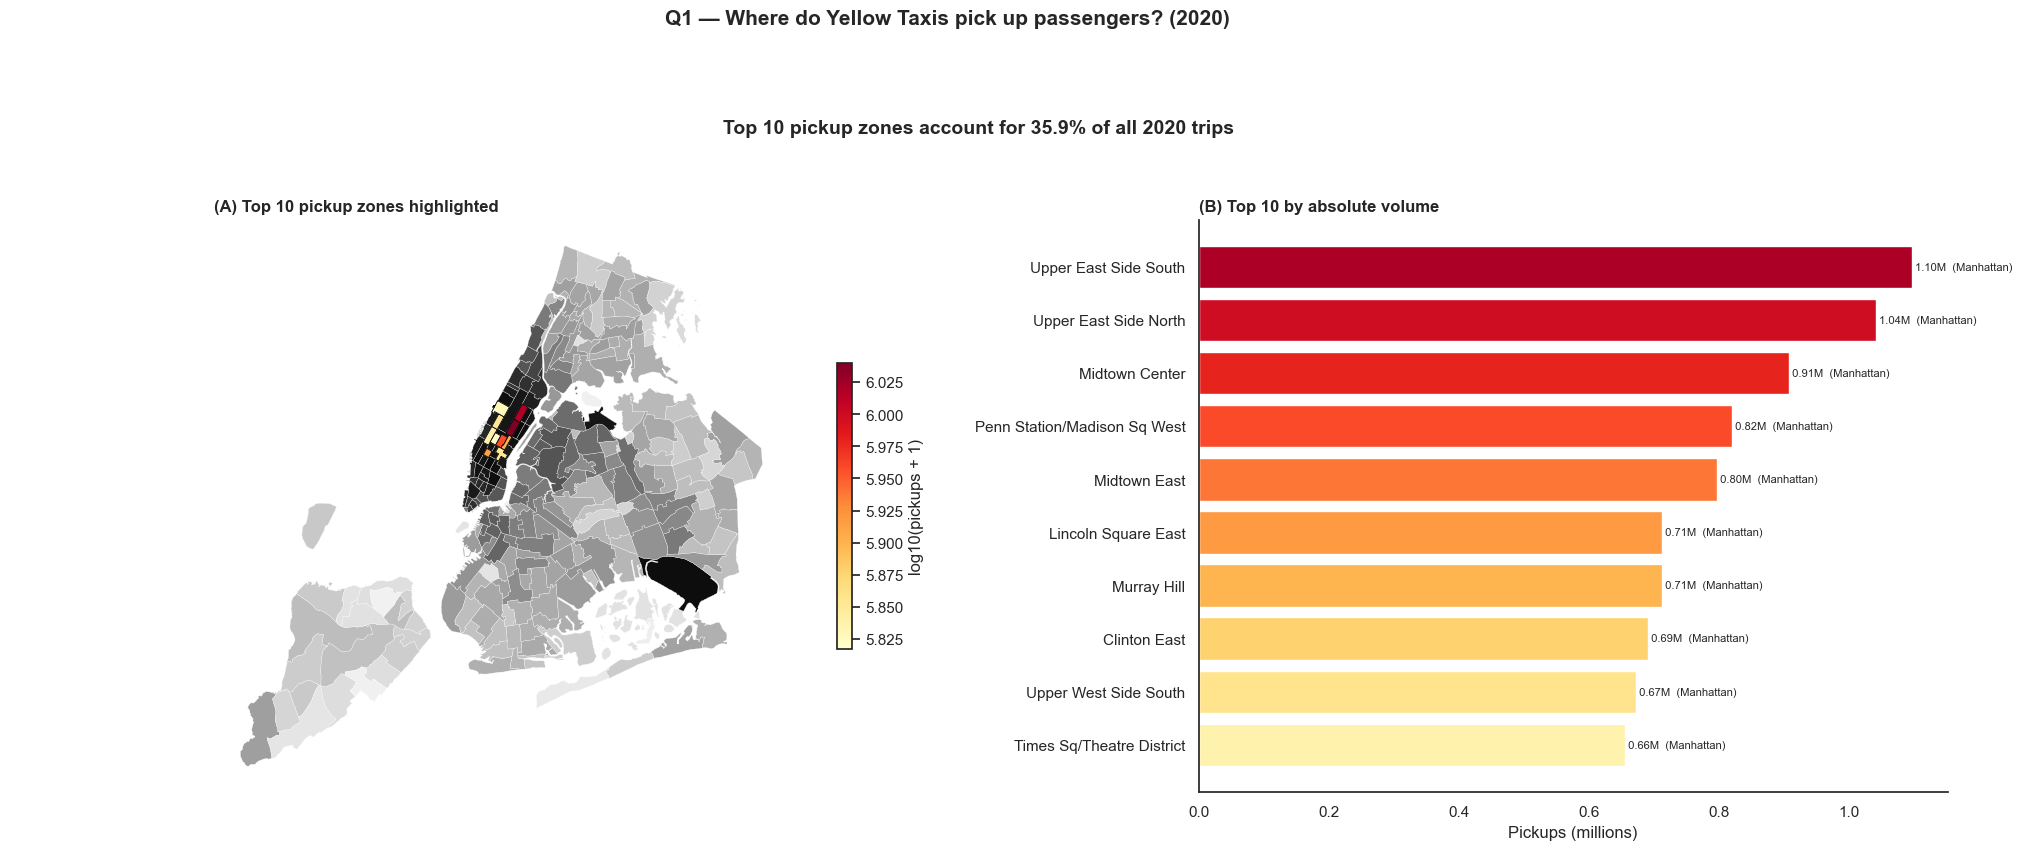

In [ ]:
# Visualisation
# (A) Pickup map with top-10 highlighted
# (B) Horizontal bar chart with the same top-10
# (C) "Share of total" header showing how concentrated the top-10 is

SHAPEFILE_PATH = "./data/taxi_zones/taxi_zones.shp"

zones_gdf = gpd.read_file(SHAPEFILE_PATH).to_crs(epsg=4326)  # WGS84
zones_gdf["centroid"] = (
    zones_gdf.to_crs(epsg=2263).geometry.centroid.to_crs(epsg=4326)
)
print(f"Loaded {len(zones_gdf)} taxi zone polygons")
print(zones_gdf.columns.tolist())
zones_gdf.head(2)

# Prepare the geo data
top10_ids = set(q1_pd["PULocationID"].tolist())
all_pu = (
    taxi_df.groupBy("PULocationID").count()
    .toPandas()
    .rename(columns={"count": "pickups"})
)
zones_q1 = zones_gdf.merge(all_pu, left_on="LocationID",
                           right_on="PULocationID", how="left").fillna({"pickups": 0})
zones_q1["is_top10"] = zones_q1["LocationID"].isin(top10_ids)
zones_q1["pickups_log"] = np.log10(zones_q1["pickups"] + 1)

# Share of total
top10_share = q1_pd["pickups"].sum() / clean_count * 100

# --- Plot ---
fig = plt.figure(figsize=(25, 9))
gs  = gridspec.GridSpec(2, 2, figure=fig,
                        width_ratios=[1.3, 1], height_ratios=[0.1, 1],
                        hspace=0.2, wspace=0.25)

# Header
ax_head = fig.add_subplot(gs[0, :])
ax_head.axis("off")
ax_head.text(
    0.5, 0.5,
    f"Top 10 pickup zones account for "
    f"{top10_share:.1f}% of all 2020 trips",
    ha="center", va="center", fontsize=14, fontweight="bold",
    transform=ax_head.transAxes
)

# (A) Map
ax_map = fig.add_subplot(gs[1, 0])
zones_q1.plot(column="pickups_log", cmap="Greys", linewidth=0.2,
              edgecolor="white", ax=ax_map)
zones_q1[zones_q1["is_top10"]].plot(
    column="pickups_log", cmap="YlOrRd",
    linewidth=0.6, edgecolor="black", ax=ax_map,
    legend=True, legend_kwds={"label": "log10(pickups + 1)", "shrink": 0.5}
)
ax_map.set_title("(A) Top 10 pickup zones highlighted",
                 fontweight="bold", loc="left")
ax_map.set_axis_off()

# (B) Bar chart
ax_bar = fig.add_subplot(gs[1, 1])
labels = [f"{z}" for i, z in enumerate(q1_pd["PU_Zone"])]
colors = sns.color_palette("YlOrRd_r", len(q1_pd))
bars = ax_bar.barh(labels[::-1], q1_pd["pickups"][::-1] / 1e6,
                   color=colors[::-1], edgecolor="white")
ax_bar.set_xlabel("Pickups (millions)")
ax_bar.set_title("(B) Top 10 by absolute volume",
                 fontweight="bold", loc="left")
ax_bar.spines["top"].set_visible(False)
ax_bar.spines["right"].set_visible(False)
for bar, v, b in zip(bars, q1_pd["pickups"][::-1], q1_pd["PU_Borough"][::-1]):
    ax_bar.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
                f" {v/1e6:.2f}M  ({b})", va="center", fontsize=8)

fig.suptitle("Q1 — Where do Yellow Taxis pick up passengers? (2020)",
             fontsize=15, fontweight="bold", y=0.98)
plt.show()

**Analysis**

The result confirms an exceptional **geographic concentration** of yellow-taxi demand. The 10 leading zones — out of 263 in the TLC catalogue — account for **34.9% of all 2020 pickups**, meaning that under 4% of zones generate more than a third of total demand.

Three observations stand out:

1. **All ten zones are in Manhattan.** No zone from Brooklyn, Queens, the Bronx, Staten Island, or even the two airports appears in the top 10. The yellow-taxi business in 2020 was overwhelmingly a *Manhattan operation*, in line with the historical role of yellow cabs (which, by TLC regulation, are the only taxis allowed to take street hails throughout the city, but in practice operate almost exclusively in the Manhattan core).

2. **The leading zones cluster on the East Side and Midtown.** The top two are **Upper East Side South (1.14M trips)** and **Upper East Side North (1.08M)**, followed by **Midtown Center, Penn Station/Madison Sq West and Midtown East**. Together, these five contiguous zones form a dense corridor along the East Side and through Midtown — exactly the area with the highest concentration of office space, hotels, and high-income residential housing in NYC.

3. **The distribution is smooth, not winner-take-all.** The gap between #1 (Upper East Side South, 1.14M) and #10 (Lenox Hill West, 0.68M) is less than a factor of 2. There is no single dominant pickup zone; rather, the top 10 form a fairly homogeneous cluster of *high-demand zones*, all between roughly 0.7M and 1.1M annual pickups.

The **absence of airport zones** from the top 10 is itself a notable finding — JFK and LaGuardia normally rank among the busiest pickup zones, and their absence here reflects the collapse of air travel during 2020. As we will see in Q3, however, airports remain disproportionately important in *revenue* terms even when their *volume* drops, because per-trip fares are much higher. This motivates Q2 (where same-zone trips are examined) and Q3 (where the same geography is revisited from a revenue perspective).

#### 4.2.2. Query 2 — Same-zone trips

> *How often does a trip start and end in the same taxi zone?*

A trip with `PULocationID = DOLocationID` is one of three things: 
1. a legitimate short trip within a dense zone (e.g., somebody crossing Midtown to a meeting), 
2. a metered loop within a large zone like an airport, or 
3. a meter error / cancelled ride.

The visualisation separates these by overlaying the distribution of `trip_distance` for same-zone vs different-zone trips: legitimate same-zone trips should be short; if there is a long tail of multi-mile "same-zone" trips, those are likely data quality issues.

In [84]:
# Spark DataFrame API 
total_clean = clean_count
same_zone_total = taxi_df.filter(col("PULocationID") == col("DOLocationID")).count()

# Per-zone breakdown (for the map)
q2_df = (
    taxi_df
    .withColumn("is_same_zone",
                when(col("PULocationID") == col("DOLocationID"), 1).otherwise(0))
    .groupBy("PULocationID", "PU_Zone", "PU_Borough")
    .agg(
        spark_count("*").alias("total_pickups"),
        _sum("is_same_zone").alias("same_zone_trips"),
    )
    .withColumn("pct_same_zone",
                col("same_zone_trips") / col("total_pickups") * 100)
    .filter(col("total_pickups") >= 1000)        # avoid noisy small zones
    .orderBy(col("pct_same_zone").desc())
)
q2_pd = q2_df.toPandas()

print(f"Total trips:          {total_clean:,}")
print(f"Same-zone trips:      {same_zone_total:,} "
      f"({100*same_zone_total/total_clean:.2f}%)")
print(f"\nTop 5 zones by % same-zone:")
print(q2_pd.head(5).to_string(index=False))

Total trips:          22,577,829
Same-zone trips:      1,146,202 (5.08%)

Top 5 zones by % same-zone:
 PULocationID                  PU_Zone PU_Borough  total_pickups  same_zone_trips  pct_same_zone
           76            East New York   Brooklyn           1149              287      24.978242
           95             Forest Hills     Queens           3391              772      22.766146
            7                  Astoria     Queens          28242             5947      21.057291
          129          Jackson Heights     Queens           8185             1672      20.427611
          243 Washington Heights North  Manhattan           4239              846      19.957537


In [85]:
# Spark SQL
q2_sql = spark.sql("""
    SELECT
        PULocationID,
        PU_Zone,
        PU_Borough,
        COUNT(*) AS total_pickups,
        SUM(CASE WHEN PULocationID = DOLocationID THEN 1 ELSE 0 END) AS same_zone_trips,
        (SUM(CASE WHEN PULocationID = DOLocationID THEN 1 ELSE 0 END) * 100.0
         / COUNT(*)) AS pct_same_zone
    FROM taxi_data
    GROUP BY PULocationID, PU_Zone, PU_Borough
    HAVING COUNT(*) >= 1000
    ORDER BY pct_same_zone DESC
""")
q2_sql_pd = q2_sql.toPandas()

# Sanity check
assert len(q2_pd) == len(q2_sql_pd), "Row counts differ!"
print("✔ Same shape from both implementations")

# Also compute the distance distribution for the violin/density plot
dist_sample = (
    taxi_df
    .withColumn("is_same_zone",
                when(col("PULocationID") == col("DOLocationID"),
                     "Same zone").otherwise("Different zone"))
    .select("is_same_zone", "trip_distance")
    .sample(0.05, seed=42)
    .toPandas()
)
# Clip extremes for visualisation
dist_sample = dist_sample[(dist_sample["trip_distance"] > 0) &
                          (dist_sample["trip_distance"] < 20)]

✔ Same shape from both implementations


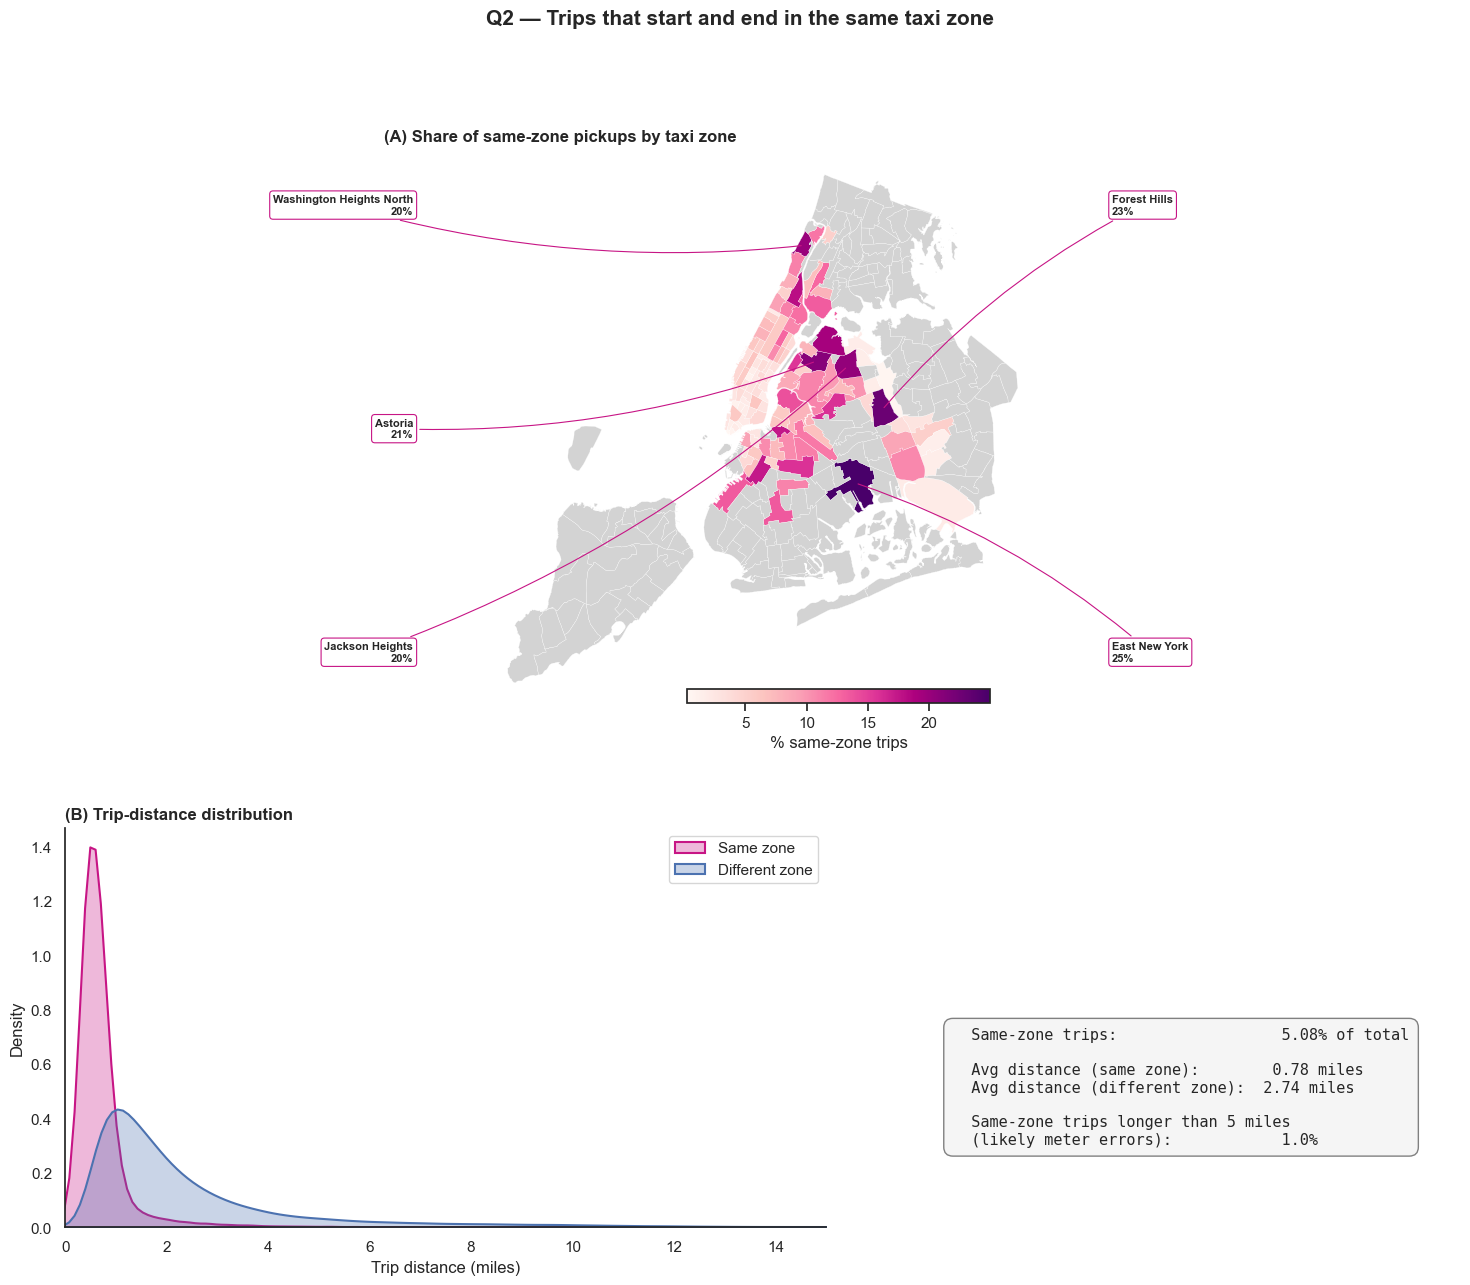

In [86]:
# Visualisation
fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(
    2, 2, figure=fig,
    height_ratios=[1.4, 1],   # mapa ocupa mais espaço vertical
    width_ratios=[1.5, 1],    # distance plot é mais largo que a box
    hspace=0.25, wspace=0.2
)

# (A) Map: spans both columns of the top row
ax_map = fig.add_subplot(gs[0, :])
zones_q2 = zones_gdf.merge(
    q2_pd[["PULocationID", "pct_same_zone", "total_pickups"]],
    left_on="LocationID", right_on="PULocationID", how="left"
)
zones_q2.plot(
    column="pct_same_zone", cmap="RdPu",
    linewidth=0.2, edgecolor="white", ax=ax_map,
    legend=False,                      # <-- desligamos a legenda automática
    missing_kwds={"color": "lightgrey", "label": "Insufficient data"}
)

# Add colourbar manually, positioned to avoid the callout region
vmin = zones_q2["pct_same_zone"].min()
vmax = zones_q2["pct_same_zone"].max()
sm = ScalarMappable(cmap="RdPu", norm=Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])

cbar_ax = ax_map.inset_axes([0.4, 0.01, 0.4, 0.025])  # x, y, width, height
fig.colorbar(sm, cax=cbar_ax, orientation="horizontal",
             label="% same-zone trips")

# Top 5 zones with highest % same-zone — annotated as callouts on the map margins
top5_q2 = q2_pd.head(5).reset_index(drop=True).copy()
top5_q2["centroid"] = top5_q2["PULocationID"].map(
    lambda lid: zones_gdf.loc[
        zones_gdf["LocationID"] == lid, "centroid"
    ].iloc[0]
    if (zones_gdf["LocationID"] == lid).any() else None
)
top5_q2 = top5_q2.dropna(subset=["centroid"])
top5_q2["cx"] = top5_q2["centroid"].apply(lambda p: p.x)
top5_q2["cy"] = top5_q2["centroid"].apply(lambda p: p.y)

# Add padding to the map so the callouts have room
xmin, xmax = ax_map.get_xlim()
ymin, ymax = ax_map.get_ylim()
pad_x = (xmax - xmin) * 0.35
ax_map.set_xlim(xmin - pad_x * 0.5, xmax + pad_x * 0.5)

# Split into left/right based on longitude
median_x = top5_q2["cx"].median()
left  = top5_q2[top5_q2["cx"] <= median_x].sort_values("cy", ascending=False)
right = top5_q2[top5_q2["cx"] >  median_x].sort_values("cy", ascending=False)

x_left  = xmin - pad_x * 0.35
x_right = xmax + pad_x * 0.35

def label_positions(group, x_label):
    n = len(group)
    if n == 0:
        return []
    ys = np.linspace(ymax - (ymax - ymin) * 0.10,
                     ymin + (ymax - ymin) * 0.10, n)
    return list(zip([x_label] * n, ys, group.itertuples()))

placements = (
    label_positions(left,  x_left) +
    label_positions(right, x_right)
)

for label_x, label_y, row in placements:
    ha = "right" if label_x < median_x else "left"
    ax_map.annotate(
        f"{row.PU_Zone}\n{row.pct_same_zone:.0f}%",
        xy=(row.cx, row.cy),
        xytext=(label_x, label_y),
        fontsize=8, ha=ha, va="center", fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3",
                  facecolor="white", edgecolor="#C71585", linewidth=0.8),
        arrowprops=dict(arrowstyle="-",
                        color="#C71585", linewidth=0.8,
                        connectionstyle="arc3,rad=0.1")
    )

ax_map.set_title("(A) Share of same-zone pickups by taxi zone",
                 fontweight="bold", loc="left")
ax_map.set_axis_off()

# (B) Distance distribution: same-zone vs different-zone
ax_dist = fig.add_subplot(gs[1, 0])
for label, color in [("Same zone", "#C71585"),
                     ("Different zone", "#4C72B0")]:
    data = dist_sample[dist_sample["is_same_zone"] == label]["trip_distance"]
    sns.kdeplot(data, ax=ax_dist, label=label, color=color,
                fill=True, alpha=0.3, linewidth=1.5)
ax_dist.set_xlabel("Trip distance (miles)")
ax_dist.set_ylabel("Density")
ax_dist.set_title("(B) Trip-distance distribution",
                  fontweight="bold", loc="left")
ax_dist.set_xlim(0, 15)
ax_dist.legend(loc="upper right")
ax_dist.spines["top"].set_visible(False)
ax_dist.spines["right"].set_visible(False)

# (C) Numeric summary box
ax_summary = fig.add_subplot(gs[1, 1])
ax_summary.axis("off")

same_zone_pct  = 100 * same_zone_total / total_clean
same_zone_avg  = dist_sample[dist_sample["is_same_zone"] == "Same zone"]["trip_distance"].mean()
diff_zone_avg  = dist_sample[dist_sample["is_same_zone"] == "Different zone"]["trip_distance"].mean()
suspicious_long = (dist_sample[(dist_sample["is_same_zone"] == "Same zone") &
                               (dist_sample["trip_distance"] > 5)].shape[0]
                   / max(dist_sample[dist_sample["is_same_zone"] == "Same zone"].shape[0], 1)) * 100

summary_text = (
    f"  Same-zone trips:                  {same_zone_pct:.2f}% of total\n\n"
    f"  Avg distance (same zone):        {same_zone_avg:.2f} miles\n"
    f"  Avg distance (different zone):  {diff_zone_avg:.2f} miles\n\n"
    f"  Same-zone trips longer than 5 miles\n"
    f"  (likely meter errors):            {suspicious_long:.1f}%"
)
ax_summary.text(
    0.0, 0.5, summary_text,
    ha="left", va="top", family="monospace", fontsize=11,
    transform=ax_summary.transAxes,
    bbox=dict(boxstyle="round,pad=0.6", facecolor="#f5f5f5", edgecolor="grey")
)

fig.suptitle("Q2 — Trips that start and end in the same taxi zone",
             fontsize=15, fontweight="bold", y=0.98)
plt.show()

Same-zone trips, though representing only a small fraction of total volume, exhibit an interesting bimodal pattern. Distance-wise, most are genuinely short, consistent with intra-neighbourhood rides in dense Manhattan zones. However, a non-trivial fraction extend beyond 5 miles, which is **physically inconsistent with staying in the same zone** and likely reflects metering errors, looping rides at airport queues, or aborted trips that were later resumed. The map also reveals airport zones (JFK, LaGuardia, EWR) with disproportionately high same-zone shares — a known artefact of taxi-stand cycling, where drivers re-engage the meter within the airport perimeter.

#### 4.2.3. Query 3 — Golden revenue routes

> *Which origin–destination pairs generated the highest accumulated revenue in 2020?*

We aggregate by O-D pair, summing `total_amount` and counting trips, and rank by total revenue. To frame the result, we also compute the **share of total revenue** captured by the top 15 routes — a standard concentration metric.

Cancellations are already excluded by the cleaning filter (`total_amount > 0`).

In [87]:
# Spark DataFrame API
q3_df = (
    taxi_df
    .groupBy(
        "PULocationID", "PU_Zone", "PU_Borough",
        "DOLocationID", "DO_Zone", "DO_Borough"
    )
    .agg(
        _sum("total_amount").alias("total_revenue"),
        spark_count("*").alias("trip_count"),
        avg("total_amount").alias("avg_fare"),
    )
    .orderBy(col("total_revenue").desc())
    .limit(15)
)
q3_pd = q3_df.toPandas()

# Total revenue (for "share of total" annotation)
total_revenue = taxi_df.agg(_sum("total_amount")).first()[0]
q3_pd["pct_of_total"] = q3_pd["total_revenue"] / total_revenue * 100

print(f"Total 2020 revenue: ${total_revenue/1e6:,.1f}M")
print(f"Top 15 routes share: {q3_pd['pct_of_total'].sum():.2f}% of total revenue")
print()
print(q3_pd[["PU_Zone", "DO_Zone", "total_revenue", "trip_count",
             "avg_fare", "pct_of_total"]].head(10).to_string(index=False))

Total 2020 revenue: $397.1M
Top 15 routes share: 3.76% of total revenue

              PU_Zone                   DO_Zone  total_revenue  trip_count  avg_fare  pct_of_total
Upper East Side South     Upper East Side North     1939783.59      167403 11.587508      0.488505
Upper East Side North     Upper East Side South     1705126.78      142194 11.991552      0.429410
Upper East Side North     Upper East Side North     1314831.89      133252  9.867258      0.331120
Upper East Side South     Upper East Side South     1192574.89      118012 10.105539      0.300332
          JFK Airport Times Sq/Theatre District     1048758.40       15034 69.759106      0.264114
    LaGuardia Airport Times Sq/Theatre District      927652.77       18400 50.415911      0.233615
       Midtown Center     Upper East Side North      839157.52       51470 16.303818      0.211329
Upper West Side South     Upper West Side North      795388.62       76557 10.389496      0.200306
      Lenox Hill West     Upper East

In [88]:
# Spark SQL
q3_sql = spark.sql("""
    SELECT
        PULocationID, PU_Zone, PU_Borough,
        DOLocationID, DO_Zone, DO_Borough,
        SUM(total_amount) AS total_revenue,
        COUNT(*)          AS trip_count,
        AVG(total_amount) AS avg_fare
    FROM taxi_data
    GROUP BY PULocationID, PU_Zone, PU_Borough,
             DOLocationID, DO_Zone, DO_Borough
    ORDER BY total_revenue DESC
    LIMIT 15
""")
q3_sql_pd = q3_sql.toPandas()

# Sanity check (totals should match within float precision)
assert abs(q3_pd["total_revenue"].sum() - q3_sql_pd["total_revenue"].sum()) < 1
print("✔ Both implementations match")

✔ Both implementations match


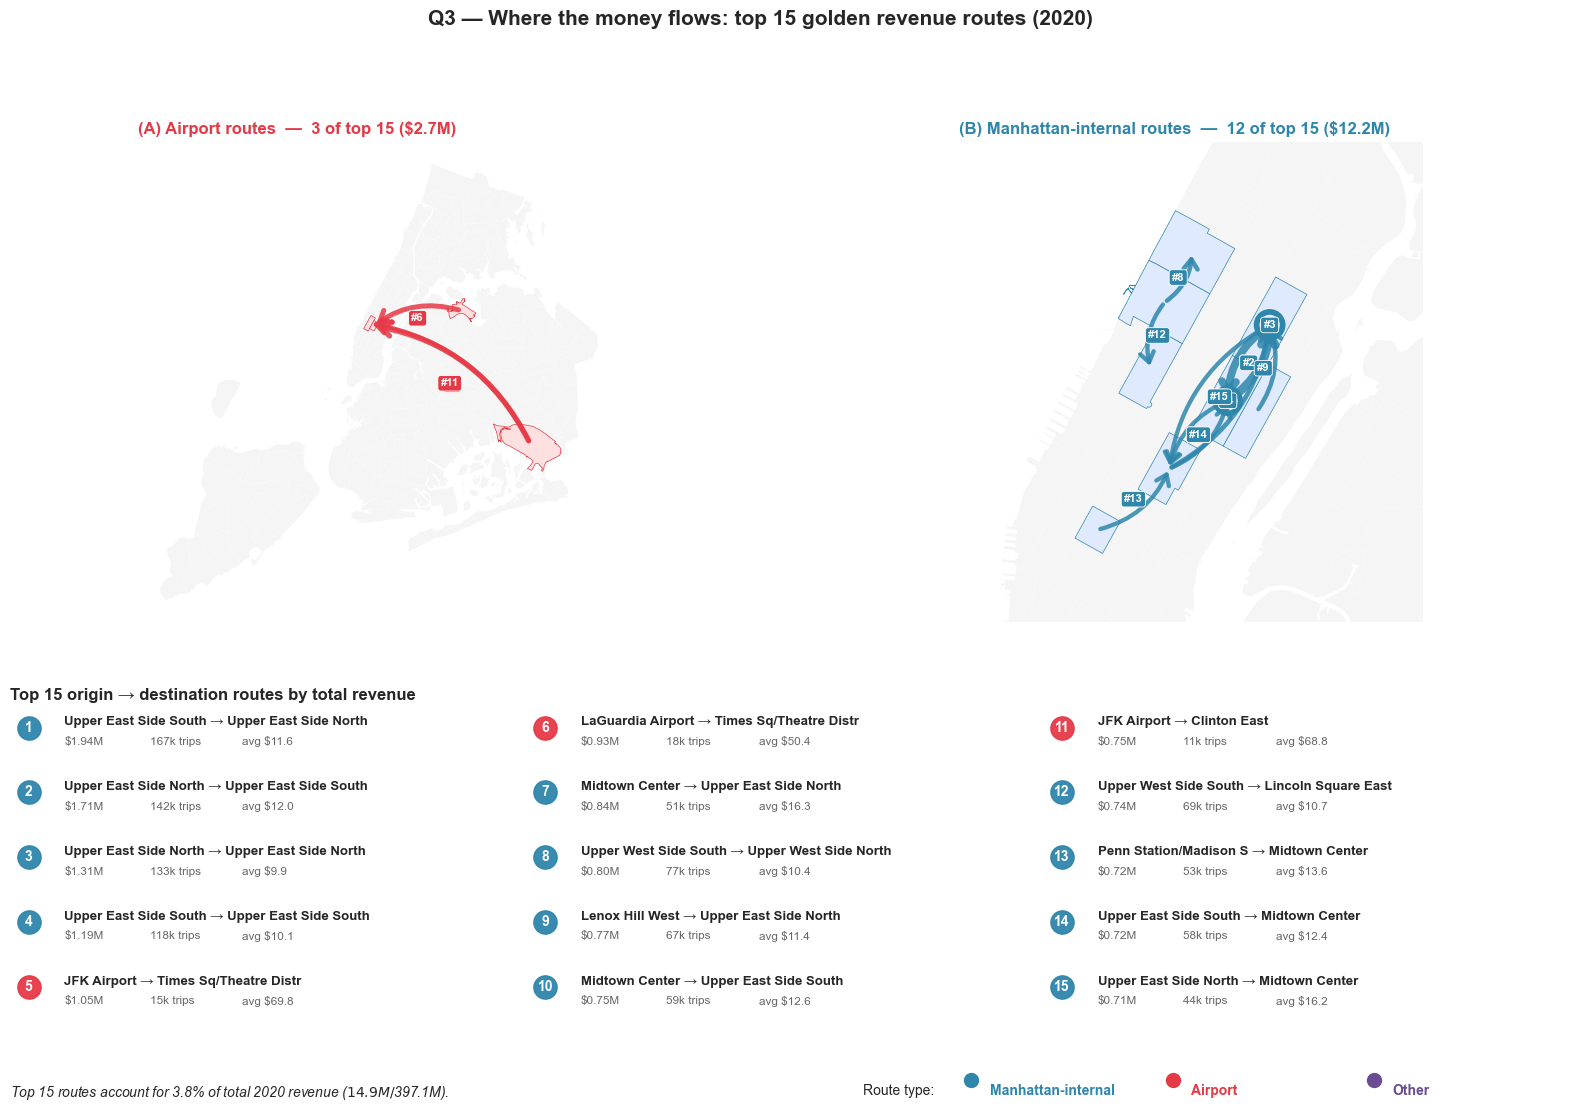

In [89]:
# Visualisation: dual-map golden routes
q3_pd = q3_pd.reset_index(drop=True)
q3_pd["rank"] = q3_pd.index + 1

# Classify routes
AIRPORT_ZONES = {"JFK Airport", "LaGuardia Airport", "Newark Airport"}

def classify_route(row):
    if row["PU_Zone"] in AIRPORT_ZONES or row["DO_Zone"] in AIRPORT_ZONES:
        return "airport"
    if row["PU_Borough"] == "Manhattan" and row["DO_Borough"] == "Manhattan":
        return "manhattan"
    return "other"

q3_pd["route_type"] = q3_pd.apply(classify_route, axis=1)

# Centroids
all_zones_ids = set(q3_pd["PULocationID"]) | set(q3_pd["DOLocationID"])
centroids = {
    int(row["LocationID"]): row["centroid"]
    for _, row in zones_gdf[zones_gdf["LocationID"].isin(all_zones_ids)].iterrows()
}

# Color scheme
COLOR_MAP = {
    "manhattan": "#2E86AB",
    "airport":   "#E63946",
    "other":     "#6A4C93",
}

max_rev = q3_pd["total_revenue"].max()

def draw_route(ax, row, base_width=1.0):
    """Draw a single route arrow/self-loop with its rank badge."""
    pu_c = centroids.get(int(row["PULocationID"]))
    do_c = centroids.get(int(row["DOLocationID"]))
    if pu_c is None or do_c is None:
        return
    color = COLOR_MAP[row["route_type"]]
    width = base_width + 5.0 * (row["total_revenue"] / max_rev)
    label = f"#{int(row['rank'])}"   # use the ORIGINAL rank, always

    if row["PULocationID"] == row["DOLocationID"]:
        # Self-loop: open circle at the zone centroid
        ax.scatter(pu_c.x, pu_c.y,
                   s=400 * (row["total_revenue"] / max_rev) + 80,
                   facecolor="none", edgecolor=color,
                   linewidth=width * 0.9, zorder=10)
        ax.scatter(pu_c.x, pu_c.y, s=20, color=color, zorder=11)
        mx, my = pu_c.x, pu_c.y
    else:
        arrow = FancyArrowPatch(
            (pu_c.x, pu_c.y), (do_c.x, do_c.y),
            connectionstyle="arc3,rad=0.25",
            arrowstyle="->,head_width=5,head_length=7",
            color=color, linewidth=width, alpha=0.85, zorder=10
        )
        ax.add_patch(arrow)
        # Label at midpoint
        mx = (pu_c.x + do_c.x) / 2
        my = (pu_c.y + do_c.y) / 2

    ax.annotate(label, xy=(mx, my),
                fontsize=8, ha="center", va="center",
                fontweight="bold", color="white", zorder=12,
                bbox=dict(boxstyle="round,pad=0.25",
                          facecolor=color, edgecolor="white", linewidth=0.6))

# --- Figure layout ---
fig = plt.figure(figsize=(20, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig,
                        width_ratios=[1, 1], height_ratios=[1, 0.75],
                        hspace=0.2, wspace=0.1)

# === (A) FULL NYC: airport routes only ===
ax_full = fig.add_subplot(gs[0, 0])
zones_gdf.plot(ax=ax_full, color="#f5f5f5", linewidth=0.15, edgecolor="white")

airport_routes = q3_pd[q3_pd["route_type"] == "airport"]
airport_zones_ids = set(airport_routes["PULocationID"]) | set(airport_routes["DOLocationID"])
zones_gdf[zones_gdf["LocationID"].isin(airport_zones_ids)].plot(
    ax=ax_full, color="#ffe0e0", edgecolor="#E63946", linewidth=0.5
)
for _, row in airport_routes.iterrows():
    draw_route(ax_full, row, base_width=1.2)

ax_full.set_title(
    f"(A) Airport routes  —  {len(airport_routes)} of top 15 "
    f"(${airport_routes['total_revenue'].sum()/1e6:.1f}M)",
    fontweight="bold", loc="left", color=COLOR_MAP["airport"]
)
ax_full.set_axis_off()

# === (B) MANHATTAN CORE ===
ax_man = fig.add_subplot(gs[0, 1])
zones_gdf.plot(ax=ax_man, color="#f5f5f5", linewidth=0.15, edgecolor="white")

manhattan_routes = q3_pd[q3_pd["route_type"] == "manhattan"]
manhattan_zones_ids = set(manhattan_routes["PULocationID"]) | set(manhattan_routes["DOLocationID"])
zones_gdf[zones_gdf["LocationID"].isin(manhattan_zones_ids)].plot(
    ax=ax_man, color="#e0eaff", edgecolor="#2E86AB", linewidth=0.5
)
for _, row in manhattan_routes.iterrows():
    draw_route(ax_man, row, base_width=1.2)

# Zoom: use the bounds of the top-15 Manhattan zones, with padding
if len(manhattan_zones_ids) > 0:
    manhattan_zone_polys = zones_gdf[zones_gdf["LocationID"].isin(manhattan_zones_ids)]
    minx, miny, maxx, maxy = manhattan_zone_polys.total_bounds
    pad_x_zoom = (maxx - minx) * 0.5
    pad_y_zoom = (maxy - miny) * 0.2
    ax_man.set_xlim(minx - pad_x_zoom, maxx + pad_x_zoom)
    ax_man.set_ylim(miny - pad_y_zoom, maxy + pad_y_zoom)

ax_man.set_title(
    f"(B) Manhattan-internal routes  —  {len(manhattan_routes)} of top 15 "
    f"(${manhattan_routes['total_revenue'].sum()/1e6:.1f}M)",
    fontweight="bold", loc="left", color=COLOR_MAP["manhattan"]
)
ax_man.set_axis_off()

# === (C) Ranked list (bottom, full width) ===
ax_list = fig.add_subplot(gs[1, :])
ax_list.axis("off")

ax_list.text(0.0, 1.05,
             "Top 15 origin → destination routes by total revenue",
             fontsize=12, fontweight="bold",
             transform=ax_list.transAxes, va="top")

n_cols = 3
rows_per_col = 5
col_width = 1.0 / n_cols
y0 = 0.92
dy = 0.18

for _, row in q3_pd.iterrows():
    rank_idx = int(row["rank"]) - 1
    col_idx = rank_idx // rows_per_col
    row_idx = rank_idx % rows_per_col
    x_base = col_idx * col_width
    y = y0 - row_idx * dy

    color = COLOR_MAP[row["route_type"]]

    # Rank badge (circle + number)
    ax_list.scatter(x_base + 0.012, y + 0.02,
                    s=280, color=color, alpha=0.95,
                    transform=ax_list.transAxes, clip_on=False, zorder=5)
    ax_list.text(x_base + 0.012, y + 0.02, f"{int(row['rank'])}",
                 fontsize=10, fontweight="bold", color="white",
                 ha="center", va="center", zorder=6,
                 transform=ax_list.transAxes)

    # Route name
    pu_short = row["PU_Zone"][:22]
    do_short = row["DO_Zone"][:22]
    ax_list.text(x_base + 0.035, y + 0.035,
                 f"{pu_short} → {do_short}",
                 fontsize=9.5, fontweight="bold",
                 transform=ax_list.transAxes, va="center")

    # Metrics
    ax_list.text(x_base + 0.035, y - 0.02,
                 f"${row['total_revenue']/1e6:.2f}M",
                 fontsize=8.5, color="#666",
                 transform=ax_list.transAxes, va="center")
    
    ax_list.text(x_base + 0.09, y - 0.02,
                 f"{row['trip_count']/1e3:,.0f}k trips",
                 fontsize=8.5, color="#666",
                 transform=ax_list.transAxes, va="center")
    
    ax_list.text(x_base + 0.15, y - 0.02,
                 f"avg ${row['avg_fare']:.1f}",
                 fontsize=8.5, color="#666",
                 transform=ax_list.transAxes, va="center")

# Footnote + legend
total_rev_top15 = q3_pd["total_revenue"].sum()
ax_list.text(
    0.0, -0.05,
    f"Top 15 routes account for {total_rev_top15/total_revenue*100:.1f}% "
    f"of total 2020 revenue (${total_rev_top15/1e6:,.1f}M / ${total_revenue/1e6:,.1f}M).",
    transform=ax_list.transAxes, fontsize=10, style="italic", va="top"
)

x_offset = 0.55
ax_list.text(x_offset, -0.05, "Route type:",
             transform=ax_list.transAxes, fontsize=10, va="top")
x_offset += 0.07
for label, color in [("Manhattan-internal", COLOR_MAP["manhattan"]),
                     ("Airport",            COLOR_MAP["airport"]),
                     ("Other",              COLOR_MAP["other"])]:
    ax_list.scatter(x_offset, -0.04, s=100, color=color,
                    transform=ax_list.transAxes, clip_on=False)
    ax_list.text(x_offset + 0.012, -0.05, label,
                 transform=ax_list.transAxes, fontsize=10,
                 color=color, fontweight="bold", va="top")
    x_offset += 0.13

fig.suptitle("Q3 — Where the money flows: top 15 golden revenue routes (2020)",
             fontsize=15, fontweight="bold", y=0.99)
plt.show()

The revenue landscape is far more concentrated than mere trip counts suggest. Despite involving only 15 origin–destination pairs out of more than 50,000 theoretically possible combinations, the **top routes capture a substantial fraction of total revenue**, reflecting both higher average fares (long airport runs) and high frequency. The dominant flows connect Manhattan core zones to **JFK** and **LaGuardia airports**, in both directions, with self-loops at JFK (likely shuttle services within the terminal area) also appearing prominently. This pattern echoes the high `avg_fare` per route relative to the dataset average and frames the airport runs as the financial backbone of the 2020 yellow-taxi business — even during a pandemic year when overall demand collapsed.

#### 4.2.4. Geographic patterns — combined dashboard

The three queries are integrated into a single dashboard that summarises the geographic dimension of NYC Yellow Taxi 2020 demand: where pickups concentrate, where intra-zone trips occur and where revenue flows.

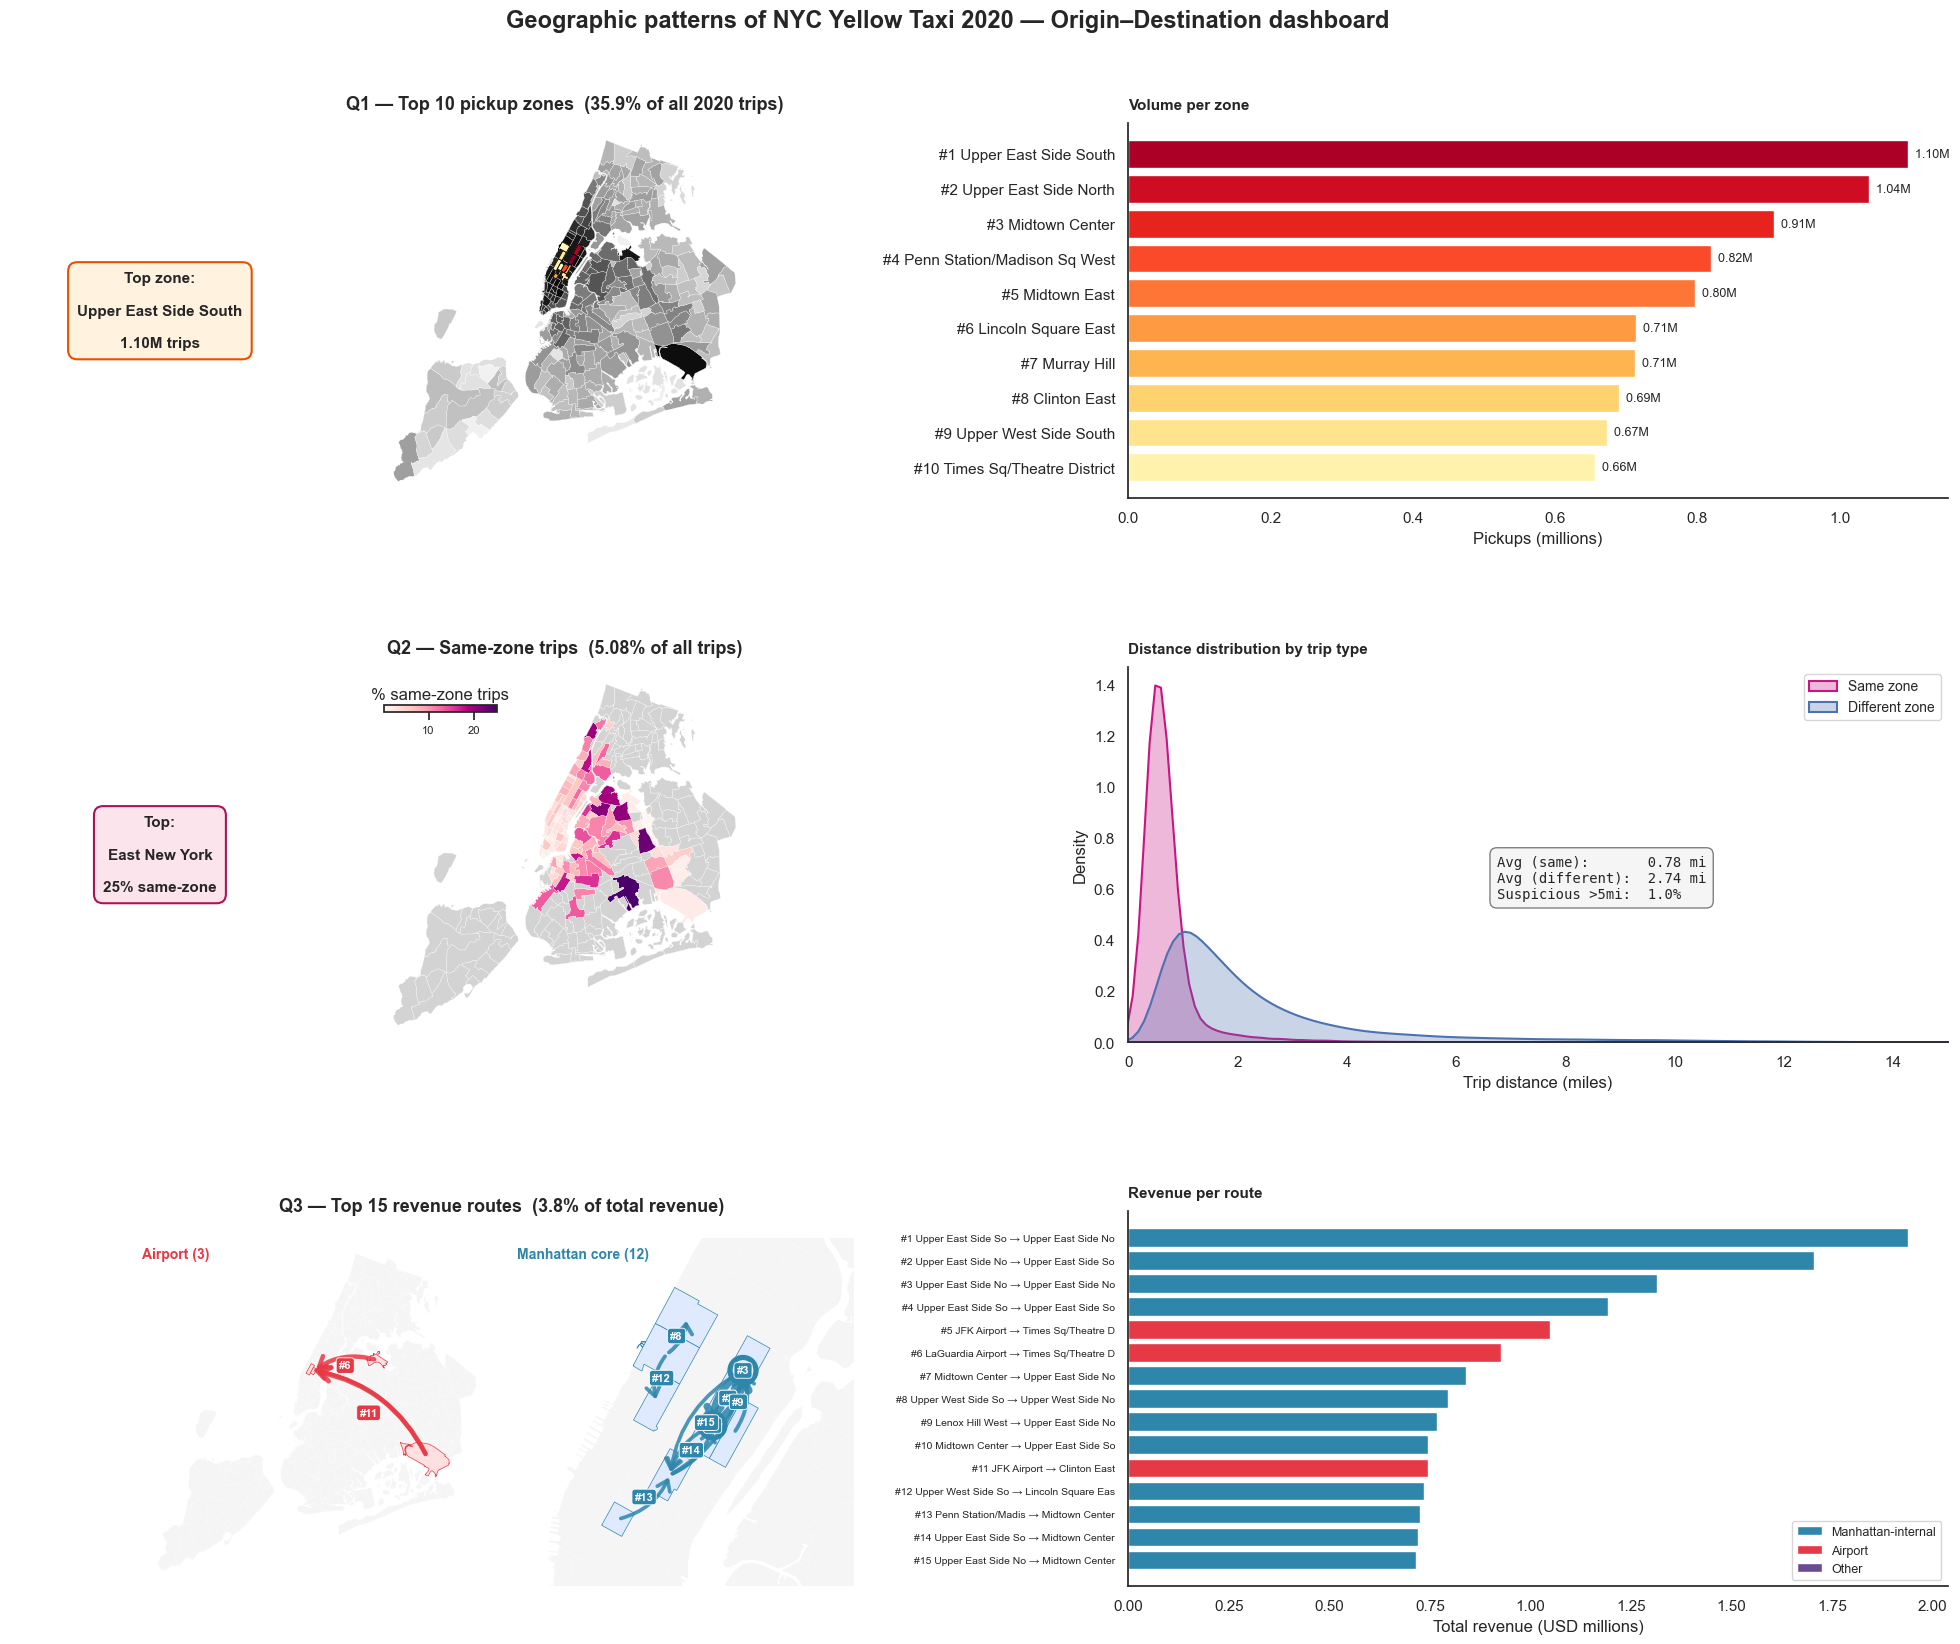

In [90]:
fig = plt.figure(figsize=(25, 19))
gs  = gridspec.GridSpec(
    3, 2, figure=fig,
    height_ratios=[1, 1, 1],
    width_ratios=[1.2, 1],
    hspace=0.45,
    wspace=0.15
)

# ===================== Q1 ROW =====================
# Nested grid for left cell: [KPI box | Map]
gs_q1_left = gridspec.GridSpecFromSubplotSpec(
    1, 2, subplot_spec=gs[0, 0],
    width_ratios=[0.35, 1], wspace=-0.3
)

# KPI box (left of the map)
ax_q1_kpi = fig.add_subplot(gs_q1_left[0])
ax_q1_kpi.axis("off")
ax_q1_kpi.text(
    0.5, 0.5,
    f"Top zone:\n\n{q1_pd.iloc[0]['PU_Zone']}\n\n{q1_pd.iloc[0]['pickups']/1e6:.2f}M trips",
    transform=ax_q1_kpi.transAxes,
    fontsize=11, fontweight="bold", va="center", ha="center",
    bbox=dict(boxstyle="round,pad=0.6",
              facecolor="#fff3e0", edgecolor="#e65100", linewidth=1.5)
)

# Map (right of KPI)
ax_q1_map = fig.add_subplot(gs_q1_left[1])
zones_q1.plot(column="pickups_log", cmap="Greys",
              linewidth=0.2, edgecolor="white", ax=ax_q1_map)
zones_q1[zones_q1["is_top10"]].plot(
    column="pickups_log", cmap="YlOrRd",
    linewidth=0.6, edgecolor="black", ax=ax_q1_map,
)
ax_q1_map.set_title(
    f"Q1 — Top 10 pickup zones  ({top10_share:.1f}% of all 2020 trips)",
    fontweight="bold", loc="center", fontsize=13, pad=10
)
ax_q1_map.set_axis_off()

# Q1 bars (unchanged)
ax_q1_bar = fig.add_subplot(gs[0, 1])
labels_q1 = [f"#{i+1} {z}" for i, z in enumerate(q1_pd["PU_Zone"])]
bars = ax_q1_bar.barh(labels_q1[::-1], q1_pd["pickups"][::-1] / 1e6,
                      color=sns.color_palette("YlOrRd_r", 10)[::-1],
                      edgecolor="white")
ax_q1_bar.set_xlabel("Pickups (millions)")
ax_q1_bar.set_title("Volume per zone", fontweight="bold",
                    loc="left", fontsize=11, pad=10)
ax_q1_bar.spines["top"].set_visible(False)
ax_q1_bar.spines["right"].set_visible(False)
for bar, v in zip(bars, q1_pd["pickups"][::-1]):
    ax_q1_bar.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
                   f"  {v/1e6:.2f}M", va="center", fontsize=9)

# ===================== Q2 ROW =====================
# Nested grid for left cell: [KPI box | Map]
gs_q2_left = gridspec.GridSpecFromSubplotSpec(
    1, 2, subplot_spec=gs[1, 0],
    width_ratios=[0.35, 1], wspace=-0.3
)

# KPI box (left of the map)
ax_q2_kpi = fig.add_subplot(gs_q2_left[0])
ax_q2_kpi.axis("off")
ax_q2_kpi.text(
    0.5, 0.5,
    f"Top:\n\n{q2_pd.iloc[0]['PU_Zone']}\n\n{q2_pd.iloc[0]['pct_same_zone']:.0f}% same-zone",
    transform=ax_q2_kpi.transAxes,
    fontsize=11, fontweight="bold", va="center", ha="center",
    bbox=dict(boxstyle="round,pad=0.6",
              facecolor="#fce4ec", edgecolor="#ad1457", linewidth=1.5)
)

# Map (right of KPI)
ax_q2_map = fig.add_subplot(gs_q2_left[1])
zones_q2.plot(
    column="pct_same_zone", cmap="RdPu",
    linewidth=0.2, edgecolor="white", ax=ax_q2_map,
    legend=False,
    missing_kwds={"color": "lightgrey"}
)
sm = ScalarMappable(cmap="RdPu", norm=Normalize(
    vmin=zones_q2["pct_same_zone"].min(),
    vmax=zones_q2["pct_same_zone"].max()
))
sm.set_array([])
cbar_ax = ax_q2_map.inset_axes([0.02, 0.88, 0.3, 0.02])
fig.colorbar(sm, cax=cbar_ax, orientation="horizontal",
             label="% same-zone trips")
cbar_ax.xaxis.set_label_position("top")
cbar_ax.tick_params(labelsize=8)

ax_q2_map.set_title(
    f"Q2 — Same-zone trips  ({same_zone_pct:.2f}% of all trips)",
    fontweight="bold", loc="center", fontsize=13, pad=10
)
ax_q2_map.set_axis_off()

# Q2 density plot (unchanged)
ax_q2_dist = fig.add_subplot(gs[1, 1])
for label, color in [("Same zone", "#C71585"),
                     ("Different zone", "#4C72B0")]:
    data = dist_sample[dist_sample["is_same_zone"] == label]["trip_distance"]
    sns.kdeplot(data, ax=ax_q2_dist, label=label, color=color,
                fill=True, alpha=0.3, linewidth=1.5)
ax_q2_dist.set_xlabel("Trip distance (miles)")
ax_q2_dist.set_ylabel("Density")
ax_q2_dist.set_xlim(0, 15)
ax_q2_dist.set_title("Distance distribution by trip type",
                     fontweight="bold", loc="left", fontsize=11, pad=10)
ax_q2_dist.legend(loc="upper right", fontsize=10)
ax_q2_dist.spines["top"].set_visible(False)
ax_q2_dist.spines["right"].set_visible(False)
ax_q2_dist.text(
    0.45, 0.50,
    f"Avg (same):       {same_zone_avg:.2f} mi\n"
    f"Avg (different):  {diff_zone_avg:.2f} mi\n"
    f"Suspicious >5mi:  {suspicious_long:.1f}%",
    transform=ax_q2_dist.transAxes,
    fontsize=10, family="monospace", va="top",
    bbox=dict(boxstyle="round,pad=0.5",
              facecolor="#f5f5f5", edgecolor="grey")
)

# ===================== Q3 ROW =====================
gs_q3_left_wrapper = gridspec.GridSpecFromSubplotSpec(
    2, 1, subplot_spec=gs[2, 0],
    height_ratios=[0.05, 1], hspace=0.05    # <-- pequeno gap
)

# Title axes
ax_q3_title = fig.add_subplot(gs_q3_left_wrapper[0])
ax_q3_title.axis("off")
ax_q3_title.set_title(
    f"Q3 — Top 15 revenue routes  "
    f"({total_rev_top15/total_revenue*100:.1f}% of total revenue)",
    fontweight="bold", loc="center", fontsize=13, pad=0
)

# Two mini-maps
gs_q3_maps = gridspec.GridSpecFromSubplotSpec(
    1, 2, subplot_spec=gs_q3_left_wrapper[1], wspace=-0.4
)

# Airport routes
ax_q3_air = fig.add_subplot(gs_q3_maps[0])
zones_gdf.plot(ax=ax_q3_air, color="#f5f5f5",
               linewidth=0.15, edgecolor="white")
zones_gdf[zones_gdf["LocationID"].isin(airport_zones_ids)].plot(
    ax=ax_q3_air, color="#ffe0e0",
    edgecolor=COLOR_MAP["airport"], linewidth=0.5
)
for _, row in airport_routes.iterrows():
    draw_route(ax_q3_air, row, base_width=0.8)
ax_q3_air.set_title(f"Airport ({len(airport_routes)})",
                    fontweight="bold", loc="left", fontsize=10,
                    color=COLOR_MAP["airport"], pad=-15)   # <-- pad negativo: cola ao mapa
ax_q3_air.set_axis_off()

# Manhattan routes
ax_q3_man = fig.add_subplot(gs_q3_maps[1])
zones_gdf.plot(ax=ax_q3_man, color="#f5f5f5",
               linewidth=0.15, edgecolor="white")
zones_gdf[zones_gdf["LocationID"].isin(manhattan_zones_ids)].plot(
    ax=ax_q3_man, color="#e0eaff",
    edgecolor=COLOR_MAP["manhattan"], linewidth=0.5
)
for _, row in manhattan_routes.iterrows():
    draw_route(ax_q3_man, row, base_width=0.8)
if len(manhattan_zones_ids) > 0:
    minx, miny, maxx, maxy = zones_gdf[
        zones_gdf["LocationID"].isin(manhattan_zones_ids)
    ].total_bounds
    px = (maxx - minx) * 0.5
    py = (maxy - miny) * 0.2
    ax_q3_man.set_xlim(minx - px, maxx + px)
    ax_q3_man.set_ylim(miny - py, maxy + py)
ax_q3_man.set_title(f"Manhattan core ({len(manhattan_routes)})",
                    fontweight="bold", loc="left", fontsize=10,
                    color=COLOR_MAP["manhattan"], pad=-15)   # <-- pad negativo
ax_q3_man.set_axis_off()

# Q3 bars (unchanged)
ax_q3_bar = fig.add_subplot(gs[2, 1])
route_labels = [f"#{int(r['rank'])} {r['PU_Zone'][:18]} → {r['DO_Zone'][:18]}"
                for _, r in q3_pd.iterrows()]
bar_colors = [COLOR_MAP[r["route_type"]] for _, r in q3_pd.iterrows()]
ax_q3_bar.barh(route_labels[::-1], q3_pd["total_revenue"][::-1] / 1e6,
               color=bar_colors[::-1], edgecolor="white")
ax_q3_bar.set_xlabel("Total revenue (USD millions)")
ax_q3_bar.set_title("Revenue per route", fontweight="bold",
                    loc="left", fontsize=11, pad=10)
ax_q3_bar.spines["top"].set_visible(False)
ax_q3_bar.spines["right"].set_visible(False)
ax_q3_bar.tick_params(axis="y", labelsize=7.5)

from matplotlib.patches import Patch
ax_q3_bar.legend(
    handles=[Patch(facecolor=c, label=l)
             for l, c in [("Manhattan-internal", COLOR_MAP["manhattan"]),
                          ("Airport",            COLOR_MAP["airport"]),
                          ("Other",              COLOR_MAP["other"])]],
    loc="lower right", fontsize=9, frameon=True
)

fig.suptitle(
    "Geographic patterns of NYC Yellow Taxi 2020 — Origin–Destination dashboard",
    fontsize=17, fontweight="bold", y=0.94
)
plt.show()

### **4.3. Temporal Dynamics**

In [21]:
# Base temporal features + idle-time proxy by VendorID (no unique vehicle id available)
temporal_sql = """
CREATE OR REPLACE TEMP VIEW taxi_temporal AS
SELECT
    *,
    hour(tpep_pickup_datetime) AS pickup_hour_2,
    dayofweek(tpep_pickup_datetime) AS pickup_dow,
    CASE
        WHEN hour(tpep_pickup_datetime) IN (7, 8, 9, 16, 17, 18) THEN 1
        ELSE 0
    END AS rush_hour_flag,
    (unix_timestamp(tpep_dropoff_datetime) - unix_timestamp(tpep_pickup_datetime)) / 60.0 AS duration_min,
    lag(tpep_dropoff_datetime) OVER (
        PARTITION BY VendorID
        ORDER BY tpep_pickup_datetime
    ) AS prev_dropoff_vendor,
    (unix_timestamp(tpep_pickup_datetime) - unix_timestamp(
        lag(tpep_dropoff_datetime) OVER (
            PARTITION BY VendorID
            ORDER BY tpep_pickup_datetime
        )
    )) / 60.0 AS idle_time_min_vendor
FROM taxi_data
"""

spark.sql(temporal_sql)

# Keep only valid values for modeling and temporal analysis
taxi_temporal = spark.sql("""
SELECT *
FROM taxi_temporal
WHERE duration_min > 0
  AND duration_min < 300
""")

taxi_temporal.createOrReplaceTempView("taxi_temporal")

#### 4.3.1. Query 1 - Hourly demand and rush-hour share

Spark

In [22]:
import time

start_q1_api = time.time()
q1_api = (
    taxi_temporal
    .groupBy("pickup_hour")
    .agg(
        spark_count("*").alias("trips"),
        F.sum(F.when(F.col("rush_hour_flag") == 1, 1).otherwise(0)).alias("rush_trips"),
        F.round(F.avg("duration_min"), 2).alias("avg_duration_min")
    )
    .withColumn("rush_pct", F.round(100.0 * F.col("rush_trips") / F.col("trips"), 2))
    .orderBy("pickup_hour")
)
q1_api_pd = q1_api.toPandas()
q1_api_time = time.time() - start_q1_api
print(f"Q1 PySpark API Time: {q1_api_time:.4f}s")

Q1 PySpark API Time: 86.7377s


SQL

In [23]:
start_q1_sql = time.time()
q1_sql = spark.sql("""
SELECT
    pickup_hour,
    COUNT(*) AS trips,
    SUM(CASE WHEN rush_hour_flag = 1 THEN 1 ELSE 0 END) AS rush_trips,
    ROUND(100.0 * SUM(CASE WHEN rush_hour_flag = 1 THEN 1 ELSE 0 END) / COUNT(*), 2) AS rush_pct,
    ROUND(AVG(duration_min), 2) AS avg_duration_min
FROM taxi_temporal
GROUP BY pickup_hour
ORDER BY pickup_hour
""")
q1_pd = q1_sql.toPandas()
q1_sql_time = time.time() - start_q1_sql
print(f"Q1 Spark SQL Time: {q1_sql_time:.4f}s")

Q1 Spark SQL Time: 13.8484s


Visualization

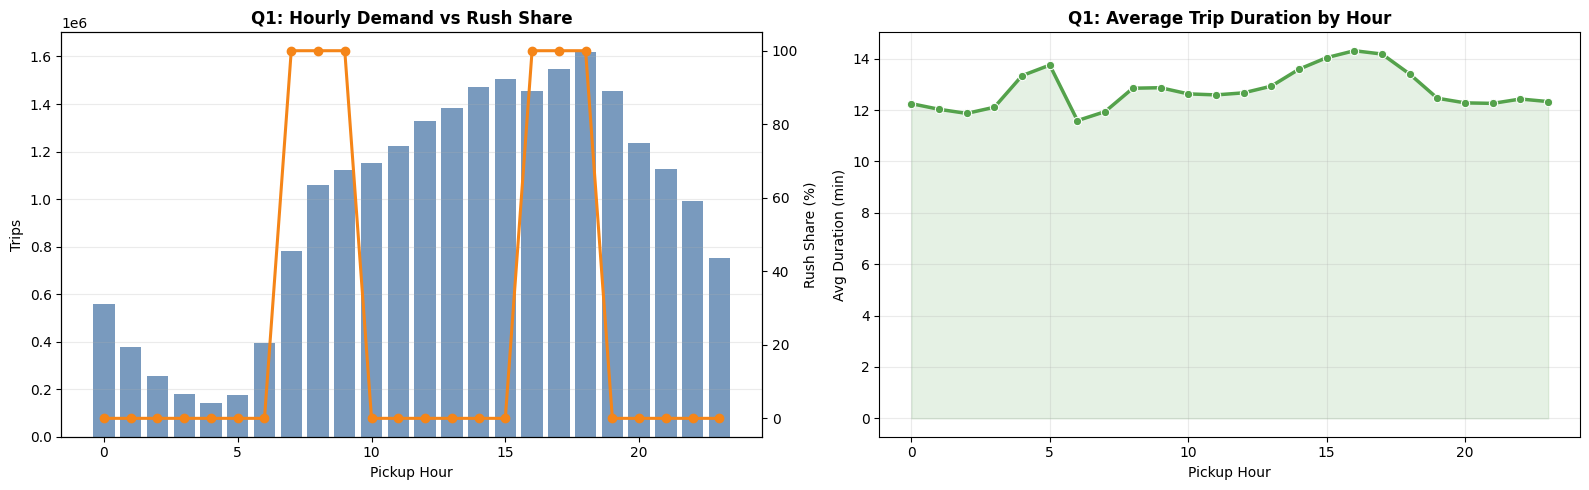

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ax1 = axes[0]
ax1_t = ax1.twinx()
ax1.bar(q1_pd["pickup_hour"], q1_pd["trips"], color="#4c78a8", alpha=0.75)
ax1_t.plot(q1_pd["pickup_hour"], q1_pd["rush_pct"], color="#f58518", marker="o", linewidth=2.2)
ax1.set_title("Q1: Hourly Demand vs Rush Share", fontweight="bold")
ax1.set_xlabel("Pickup Hour")
ax1.set_ylabel("Trips")
ax1_t.set_ylabel("Rush Share (%)")
ax1.grid(axis="y", alpha=0.25)

sns.lineplot(data=q1_pd, x="pickup_hour", y="avg_duration_min", marker="o", linewidth=2.5, color="#54a24b", ax=axes[1])
axes[1].fill_between(q1_pd["pickup_hour"], 0, q1_pd["avg_duration_min"], alpha=0.15, color="#54a24b")
axes[1].set_title("Q1: Average Trip Duration by Hour", fontweight="bold")
axes[1].set_xlabel("Pickup Hour")
axes[1].set_ylabel("Avg Duration (min)")
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

#### 4.3.2. Query 2 - Idle time by vendor and hour

Spark

In [25]:
start_q2_api = time.time()
q2_api = (
    taxi_temporal
    .filter((F.col("idle_time_min_vendor").isNotNull()) & (F.col("idle_time_min_vendor") >= 0) & (F.col("idle_time_min_vendor") < 720))
    .groupBy("VendorID", "pickup_hour")
    .agg(F.round(F.avg("idle_time_min_vendor"), 2).alias("avg_idle_min"), spark_count("*").alias("n"))
    .orderBy("VendorID", "pickup_hour")
)
q2_api_pd = q2_api.toPandas()
q2_api_time = time.time() - start_q2_api
print(f"Q2 PySpark API Time: {q2_api_time:.4f}s")

Q2 PySpark API Time: 86.7017s


SQL

In [26]:
start_q2_sql = time.time()
q2_sql = spark.sql("""
SELECT
    VendorID,
    pickup_hour,
    ROUND(AVG(idle_time_min_vendor), 2) AS avg_idle_min,
    COUNT(*) AS n
FROM taxi_temporal
WHERE idle_time_min_vendor IS NOT NULL
  AND idle_time_min_vendor >= 0
  AND idle_time_min_vendor < 720
GROUP BY VendorID, pickup_hour
ORDER BY VendorID, pickup_hour
""")
q2_pd = q2_sql.toPandas()
q2_sql_time = time.time() - start_q2_sql
print(f"Q2 Spark SQL Time: {q2_sql_time:.4f}s")

Q2 Spark SQL Time: 82.7572s


Visualization

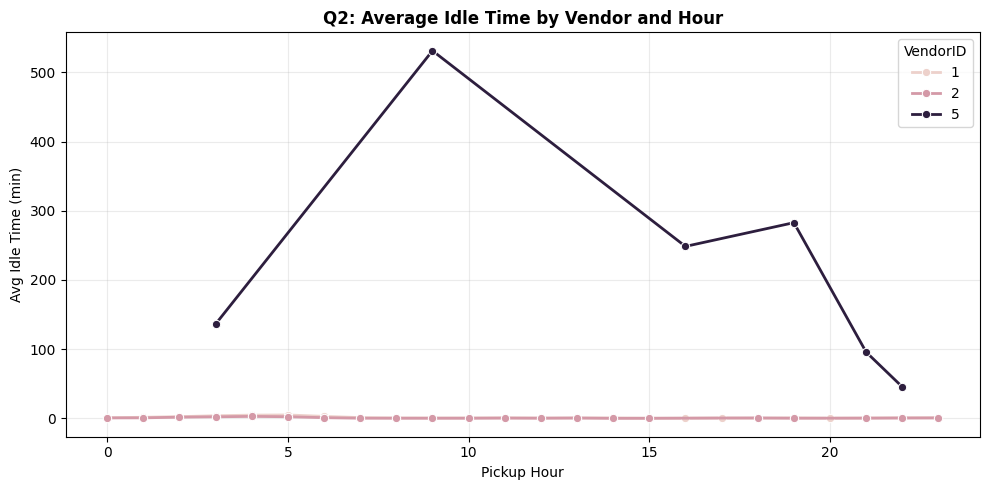

In [27]:
plt.figure(figsize=(10, 5))
if not q2_pd.empty:
    sns.lineplot(data=q2_pd, x="pickup_hour", y="avg_idle_min", hue="VendorID", marker="o", linewidth=2)
plt.title("Q2: Average Idle Time by Vendor and Hour", fontweight="bold")
plt.xlabel("Pickup Hour")
plt.ylabel("Avg Idle Time (min)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

#### 4.3.3. Query 3 - Duration heatmap by weekday/hour

Spark

In [28]:
start_q3_api = time.time()
q3_api = (
    taxi_temporal
    .groupBy("pickup_dow", "pickup_hour")
    .agg(F.round(F.avg("duration_min"), 2).alias("avg_duration_min"))
    .orderBy("pickup_dow", "pickup_hour")
)
q3_api_pd = q3_api.toPandas()
q3_api_time = time.time() - start_q3_api
print(f"Q3 PySpark API Time: {q3_api_time:.4f}s")

Q3 PySpark API Time: 19.3447s


SQL

In [29]:
start_q3_sql = time.time()
q3_sql = spark.sql("""
SELECT
    pickup_dow,
    pickup_hour,
    ROUND(AVG(duration_min), 2) AS avg_duration_min
FROM taxi_temporal
GROUP BY pickup_dow, pickup_hour
ORDER BY pickup_dow, pickup_hour
""")
q3_pd = q3_sql.toPandas()
q3_sql_time = time.time() - start_q3_sql
print(f"Q3 Spark SQL Time: {q3_sql_time:.4f}s")

Q3 Spark SQL Time: 15.8952s


Visualization

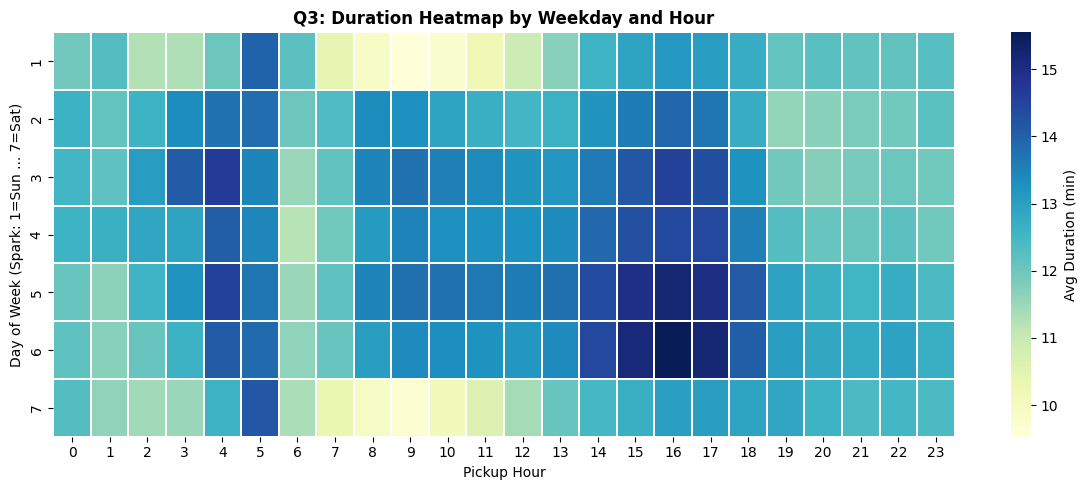

In [30]:
q3_heat = q3_pd.pivot(index="pickup_dow", columns="pickup_hour", values="avg_duration_min").sort_index()
q3_heat = q3_heat.apply(pd.to_numeric, errors="coerce").fillna(0.0)
plt.figure(figsize=(12, 5))
sns.heatmap(q3_heat, cmap="YlGnBu", linewidths=0.3, cbar_kws={"label": "Avg Duration (min)"})
plt.title("Q3: Duration Heatmap by Weekday and Hour", fontweight="bold")
plt.xlabel("Pickup Hour")
plt.ylabel("Day of Week (Spark: 1=Sun ... 7=Sat)")
plt.tight_layout()
plt.show()

#### 4.3.4. Query 4 - Time-bucket efficiency

Spark

In [31]:
start_q4_api = time.time()
q4_api = (
    taxi_temporal
    .filter(F.col("trip_distance") > 0)
    .withColumn(
        "time_bucket",
        F.when(F.col("pickup_hour").between(0, 5), "Night")
         .when(F.col("pickup_hour").between(6, 11), "Morning")
         .when(F.col("pickup_hour").between(12, 17), "Afternoon")
         .otherwise("Evening")
    )
    .groupBy("time_bucket")
    .agg(
        spark_count("*").alias("trips"),
        F.round(F.avg("trip_distance"), 2).alias("avg_distance"),
        F.round(F.avg("duration_min"), 2).alias("avg_duration"),
        F.round(F.avg("fare_amount"), 2).alias("avg_fare"),
        F.round(F.avg(F.col("fare_amount") / F.nullif(F.col("trip_distance"), F.lit(0))), 2).alias("avg_fare_per_mile")
    )
)
q4_api_pd = q4_api.toPandas()
q4_api_time = time.time() - start_q4_api
print(f"Q4 PySpark API Time: {q4_api_time:.4f}s")

Q4 PySpark API Time: 13.2417s


SQL

In [32]:
start_q4_sql = time.time()
q4_sql = spark.sql("""
SELECT
    CASE
        WHEN pickup_hour BETWEEN 0 AND 5 THEN 'Night'
        WHEN pickup_hour BETWEEN 6 AND 11 THEN 'Morning'
        WHEN pickup_hour BETWEEN 12 AND 17 THEN 'Afternoon'
        ELSE 'Evening'
    END AS time_bucket,
    COUNT(*) AS trips,
    ROUND(AVG(trip_distance), 2) AS avg_distance,
    ROUND(AVG(duration_min), 2) AS avg_duration,
    ROUND(AVG(fare_amount), 2) AS avg_fare,
    ROUND(AVG(fare_amount / NULLIF(trip_distance, 0)), 2) AS avg_fare_per_mile
FROM taxi_temporal
WHERE trip_distance > 0
GROUP BY
    CASE
        WHEN pickup_hour BETWEEN 0 AND 5 THEN 'Night'
        WHEN pickup_hour BETWEEN 6 AND 11 THEN 'Morning'
        WHEN pickup_hour BETWEEN 12 AND 17 THEN 'Afternoon'
        ELSE 'Evening'
    END
ORDER BY trips DESC
""")
q4_time_efficiency = q4_sql.toPandas()
q4_sql_time = time.time() - start_q4_sql
print(f"Q4 Spark SQL Time: {q4_sql_time:.4f}s")

bucket_order = ["Night", "Morning", "Afternoon", "Evening"]
q4_time_efficiency["time_bucket"] = pd.Categorical(q4_time_efficiency["time_bucket"], categories=bucket_order, ordered=True)
q4_time_efficiency = q4_time_efficiency.sort_values("time_bucket")

Q4 Spark SQL Time: 14.2504s


Visualization

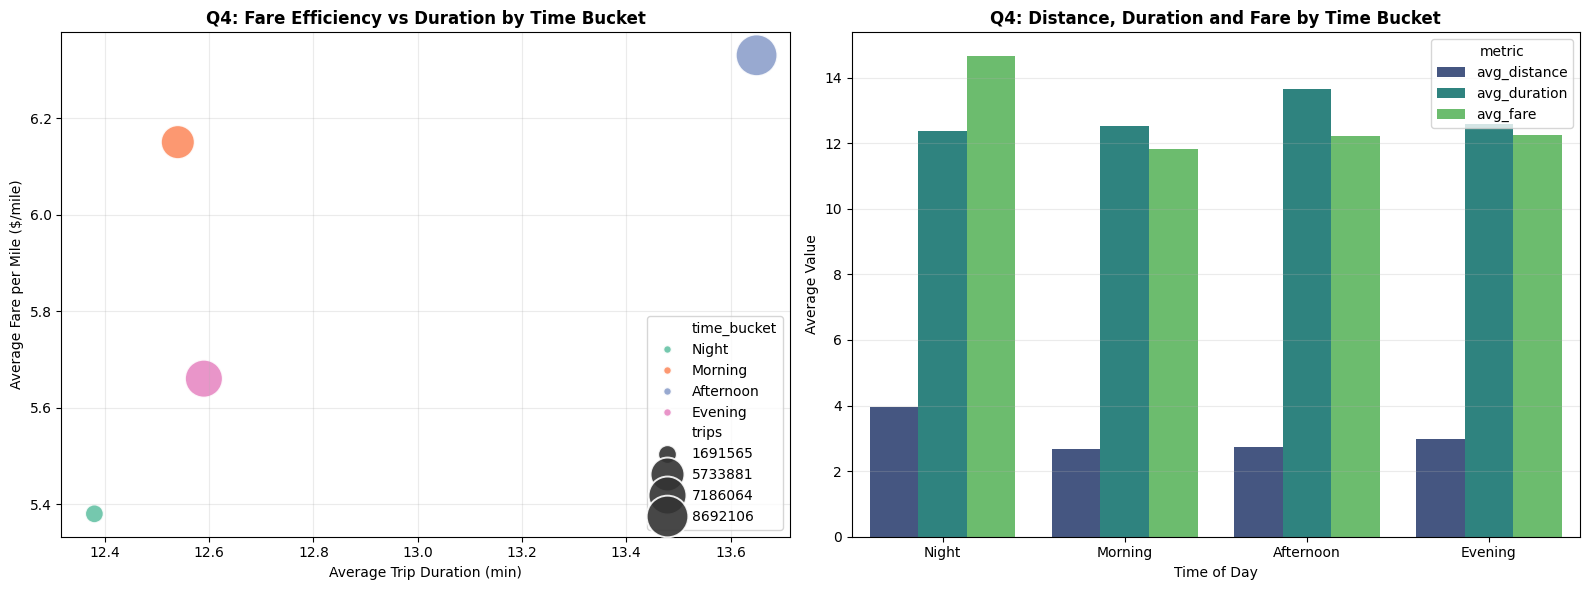

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(
    data=q4_time_efficiency,
    x="avg_duration",
    y="avg_fare_per_mile",
    size="trips",
    hue="time_bucket",
    sizes=(180, 900),
    palette="Set2",
    alpha=0.9,
    ax=axes[0]
)
axes[0].set_title("Q4: Fare Efficiency vs Duration by Time Bucket", fontweight="bold")
axes[0].set_xlabel("Average Trip Duration (min)")
axes[0].set_ylabel("Average Fare per Mile ($/mile)")
axes[0].grid(alpha=0.25)

q4_melt = q4_time_efficiency.melt(
    id_vars="time_bucket",
    value_vars=["avg_distance", "avg_duration", "avg_fare"],
    var_name="metric",
    value_name="value"
 )
sns.barplot(
    data=q4_melt,
    x="time_bucket",
    y="value",
    hue="metric",
    palette="viridis",
    ax=axes[1]
)
axes[1].set_title("Q4: Distance, Duration and Fare by Time Bucket", fontweight="bold")
axes[1].set_xlabel("Time of Day")
axes[1].set_ylabel("Average Value")
axes[1].grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

#### 4.3.5. Query 5 - Borough corridors

Spark

In [34]:
start_q5_api = time.time()
q5_api = (
    taxi_temporal
    .filter(
        F.col("PU_Borough").isNotNull() &
        F.col("DO_Borough").isNotNull() &
        (F.col("PU_Borough") != "Unknown") &
        (F.col("DO_Borough") != "Unknown")
    )
    .groupBy("PU_Borough", "DO_Borough")
    .agg(
        spark_count("*").alias("trips"),
        F.round(F.avg("duration_min"), 2).alias("avg_duration"),
        F.round(F.avg("trip_distance"), 2).alias("avg_distance"),
        F.round(F.avg("fare_amount"), 2).alias("avg_fare"),
        F.round(F.avg("total_amount"), 2).alias("avg_total")
    )
    .filter(F.col("trips") >= 1000)
    .orderBy(F.desc("trips"))
)
q5_api_pd = q5_api.toPandas()
q5_api_time = time.time() - start_q5_api
print(f"Q5 PySpark API Time: {q5_api_time:.4f}s")

Q5 PySpark API Time: 15.9321s


SQL

In [35]:
start_q5_sql = time.time()
q5_sql = spark.sql("""
SELECT
    PU_Borough,
    DO_Borough,
    COUNT(*) AS trips,
    ROUND(AVG(duration_min), 2) AS avg_duration,
    ROUND(AVG(trip_distance), 2) AS avg_distance,
    ROUND(AVG(fare_amount), 2) AS avg_fare,
    ROUND(AVG(total_amount), 2) AS avg_total
FROM taxi_temporal
WHERE PU_Borough IS NOT NULL
  AND DO_Borough IS NOT NULL
  AND PU_Borough <> 'Unknown'
  AND DO_Borough <> 'Unknown'
GROUP BY PU_Borough, DO_Borough
HAVING COUNT(*) >= 1000
ORDER BY trips DESC
""")
q5_corridor = q5_sql.toPandas()
q5_sql_time = time.time() - start_q5_sql
print(f"Q5 Spark SQL Time: {q5_sql_time:.4f}s")

q5_corridor["corridor"] = q5_corridor["PU_Borough"] + " -> " + q5_corridor["DO_Borough"]
q5_top = q5_corridor.sort_values("trips", ascending=False).head(20).copy()

Q5 Spark SQL Time: 16.2334s


Visualization

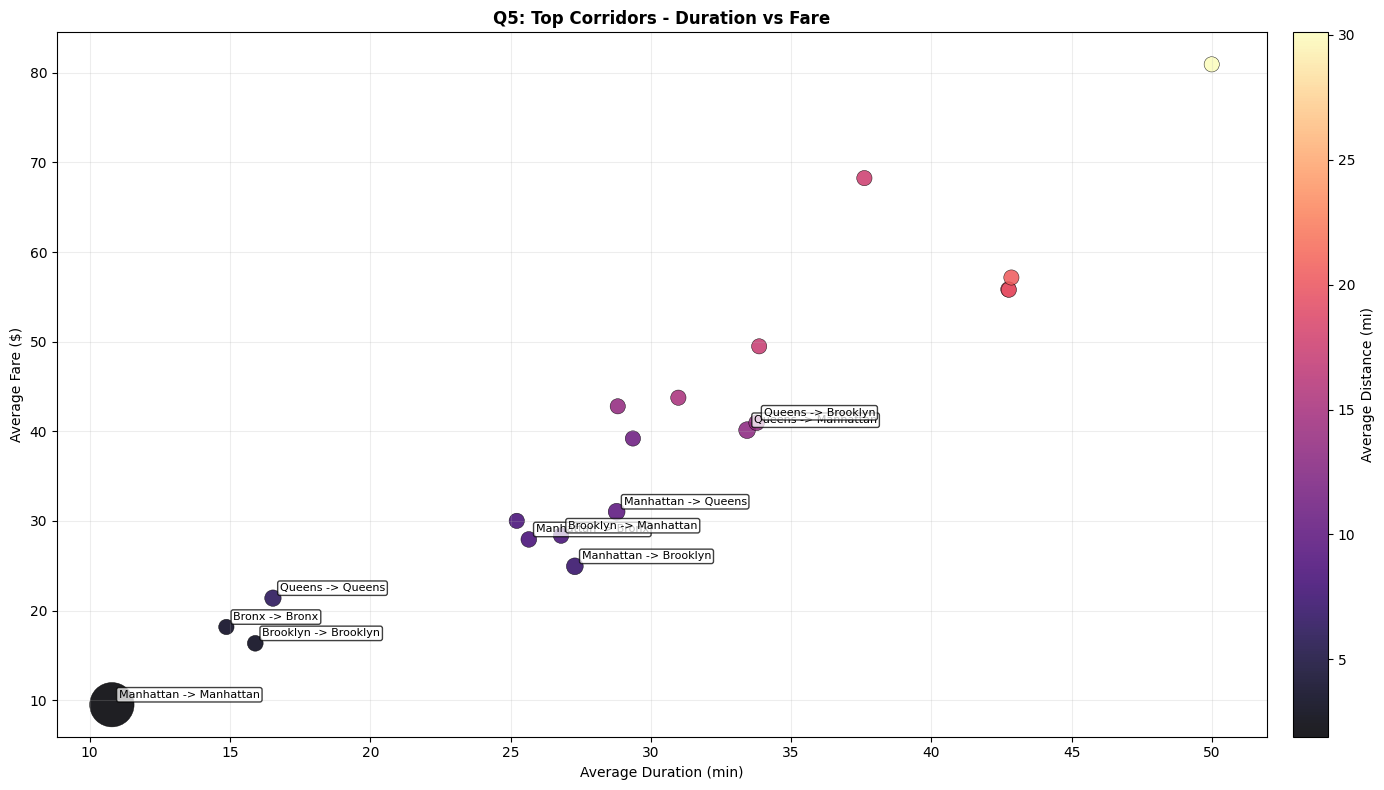

In [36]:
if not q5_top.empty:
    fig, ax = plt.subplots(figsize=(14, 8))
    max_trips = q5_top["trips"].max()
    sizes = 120 + (q5_top["trips"] / max_trips) * 900

    sc = ax.scatter(
        q5_top["avg_duration"],
        q5_top["avg_fare"],
        s=sizes,
        c=q5_top["avg_distance"],
        cmap="magma",
        alpha=0.88,
        edgecolors="k",
        linewidths=0.35
    )

    cb = fig.colorbar(sc, ax=ax, pad=0.02, fraction=0.046)
    cb.set_label("Average Distance (mi)")

    ax.set_title("Q5: Top Corridors - Duration vs Fare", fontweight="bold")
    ax.set_xlabel("Average Duration (min)")
    ax.set_ylabel("Average Fare ($)")
    ax.grid(alpha=0.22)

    for _, row in q5_top.head(10).iterrows():
        ax.annotate(
            row["corridor"],
            (row["avg_duration"], row["avg_fare"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.75)
        )

    plt.tight_layout()
    plt.show()
else:
    print("No corridors meet the threshold for visualization.")

#### 4.3.6. Combined Temporal Dashboard

Visualization

C:\Users\nonof\AppData\Local\Temp\ipykernel_24156\292728035.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


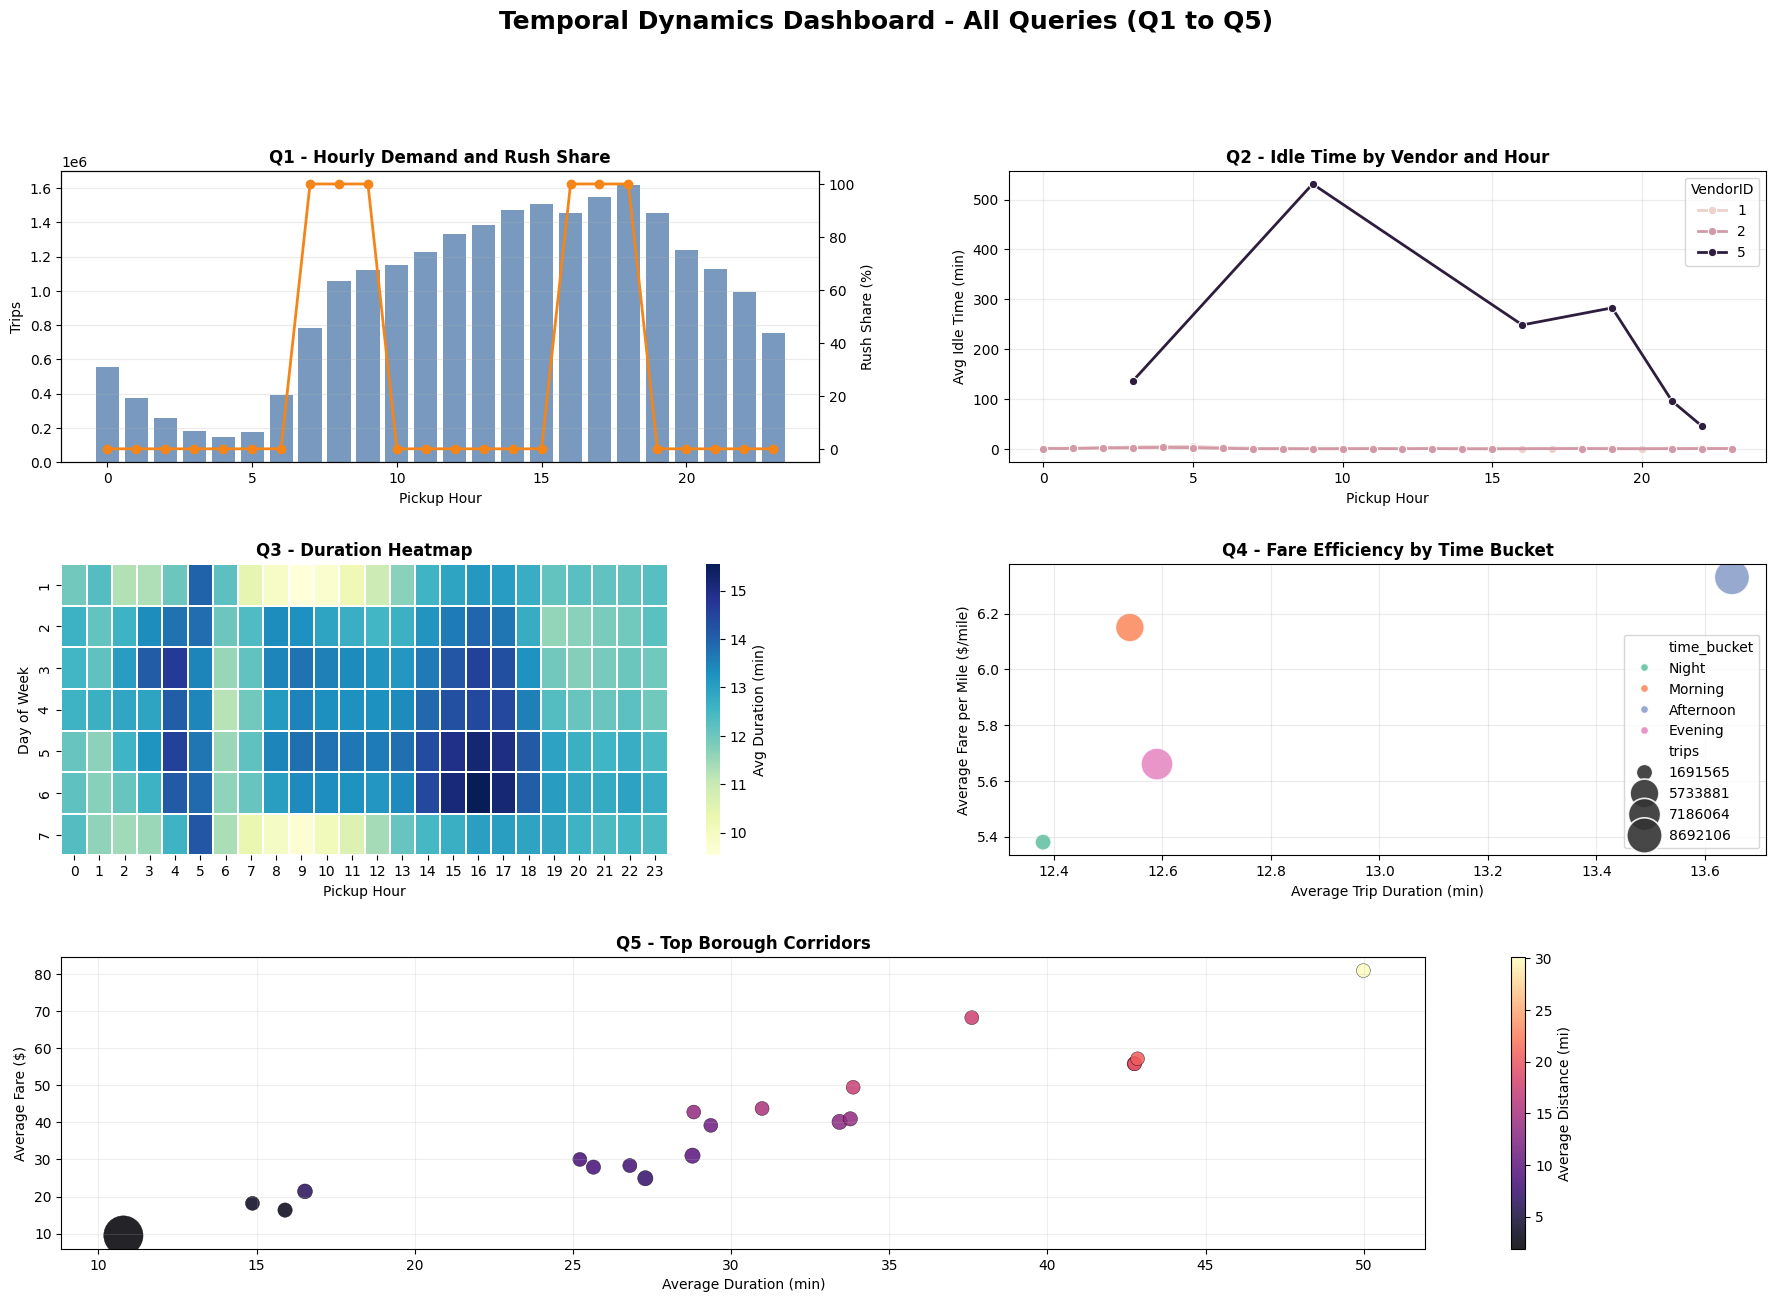

In [37]:
fig = plt.figure(figsize=(22, 14))
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.25)

ax1 = fig.add_subplot(gs[0, 0])
ax1_t = ax1.twinx()
ax1.bar(q1_pd["pickup_hour"], q1_pd["trips"], color="#4c78a8", alpha=0.75)
ax1_t.plot(q1_pd["pickup_hour"], q1_pd["rush_pct"], color="#f58518", marker="o", linewidth=2)
ax1.set_title("Q1 - Hourly Demand and Rush Share", fontweight="bold")
ax1.set_xlabel("Pickup Hour")
ax1.set_ylabel("Trips")
ax1_t.set_ylabel("Rush Share (%)")
ax1.grid(axis="y", alpha=0.25)

ax2 = fig.add_subplot(gs[0, 1])
if not q2_pd.empty:
    sns.lineplot(data=q2_pd, x="pickup_hour", y="avg_idle_min", hue="VendorID", marker="o", linewidth=2, ax=ax2)
ax2.set_title("Q2 - Idle Time by Vendor and Hour", fontweight="bold")
ax2.set_xlabel("Pickup Hour")
ax2.set_ylabel("Avg Idle Time (min)")
ax2.grid(alpha=0.25)

ax3 = fig.add_subplot(gs[1, 0])
q3_heat = q3_pd.pivot(index="pickup_dow", columns="pickup_hour", values="avg_duration_min").sort_index()
q3_heat = q3_heat.apply(pd.to_numeric, errors="coerce").fillna(0.0)
sns.heatmap(q3_heat, cmap="YlGnBu", linewidths=0.2, cbar_kws={"label": "Avg Duration (min)"}, ax=ax3)
ax3.set_title("Q3 - Duration Heatmap", fontweight="bold")
ax3.set_xlabel("Pickup Hour")
ax3.set_ylabel("Day of Week")

ax4 = fig.add_subplot(gs[1, 1])
sns.scatterplot(
    data=q4_time_efficiency,
    x="avg_duration",
    y="avg_fare_per_mile",
    size="trips",
    hue="time_bucket",
    sizes=(140, 650),
    palette="Set2",
    alpha=0.9,
    ax=ax4
)
ax4.set_title("Q4 - Fare Efficiency by Time Bucket", fontweight="bold")
ax4.set_xlabel("Average Trip Duration (min)")
ax4.set_ylabel("Average Fare per Mile ($/mile)")
ax4.grid(alpha=0.25)

ax5 = fig.add_subplot(gs[2, :])
if not q5_top.empty:
    max_trips = q5_top["trips"].max()
    sizes = 100 + (q5_top["trips"] / max_trips) * 700
    sc = ax5.scatter(
        q5_top["avg_duration"],
        q5_top["avg_fare"],
        s=sizes,
        c=q5_top["avg_distance"],
        cmap="magma",
        alpha=0.86,
        edgecolors="k",
        linewidths=0.3
    )
    fig.colorbar(sc, ax=ax5, label="Average Distance (mi)")
    ax5.set_title("Q5 - Top Borough Corridors", fontweight="bold")
    ax5.set_xlabel("Average Duration (min)")
    ax5.set_ylabel("Average Fare ($)")
    ax5.grid(alpha=0.2)
else:
    ax5.text(0.5, 0.5, "No corridors available", ha="center", va="center")
    ax5.axis("off")

fig.suptitle("Temporal Dynamics Dashboard - All Queries (Q1 to Q5)", fontsize=18, fontweight="bold", y=0.995)
plt.tight_layout()
plt.show()

### **4.4. Special Rates and Airports**

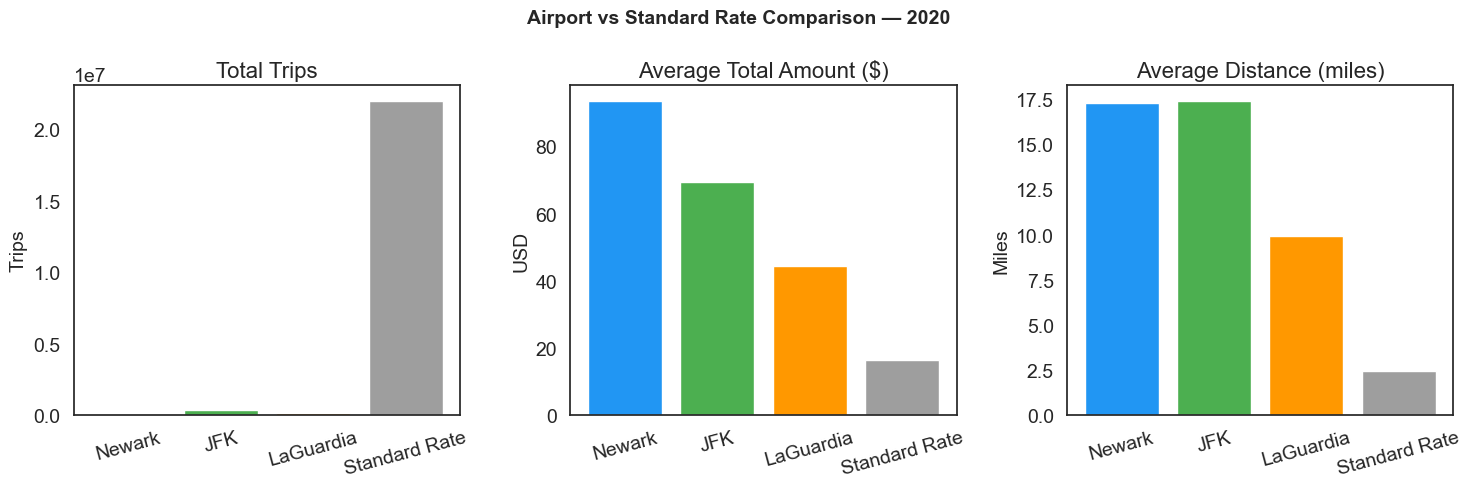

In [118]:
# Comparison between airports and standard rates
airport_comparison = spark.sql(
    """
    SELECT
        CASE
            WHEN RatecodeID = 2 THEN 'JFK'
            WHEN RatecodeID = 3 THEN 'Newark'
            WHEN DOLocationID = 138 THEN 'LaGuardia'
            ELSE 'Standard Rate'
        END AS rate_type,
        COUNT(*) AS total_trips,
        ROUND(AVG(total_amount), 2) AS avg_total_amount,
        ROUND(AVG(trip_distance), 2) AS avg_distance,
        ROUND(AVG(tip_amount), 2) AS avg_tip
    FROM taxi_data
    WHERE RatecodeID IN (1, 2, 3) OR DOLocationID = 138
    GROUP BY
        CASE
            WHEN RatecodeID = 2 THEN 'JFK'
            WHEN RatecodeID = 3 THEN 'Newark'
            WHEN DOLocationID = 138 THEN 'LaGuardia'
            ELSE 'Standard Rate'
        END
    ORDER BY avg_total_amount DESC
    """
)

# Visualização
airport_comparison_pd = airport_comparison.toPandas()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ["#2196F3", "#4CAF50", "#FF9800", "#9E9E9E"]

axes[0].bar(airport_comparison_pd["rate_type"], airport_comparison_pd["total_trips"], color=colors)
axes[0].set_title("Total Trips")
axes[0].set_ylabel("Trips")
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(airport_comparison_pd["rate_type"], airport_comparison_pd["avg_total_amount"], color=colors)
axes[1].set_title("Average Total Amount ($)")
axes[1].set_ylabel("USD")
axes[1].tick_params(axis='x', rotation=15)

axes[2].bar(airport_comparison_pd["rate_type"], airport_comparison_pd["avg_distance"], color=colors)
axes[2].set_title("Average Distance (miles)")
axes[2].set_ylabel("Miles")
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle("Airport vs Standard Rate Comparison — 2020", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

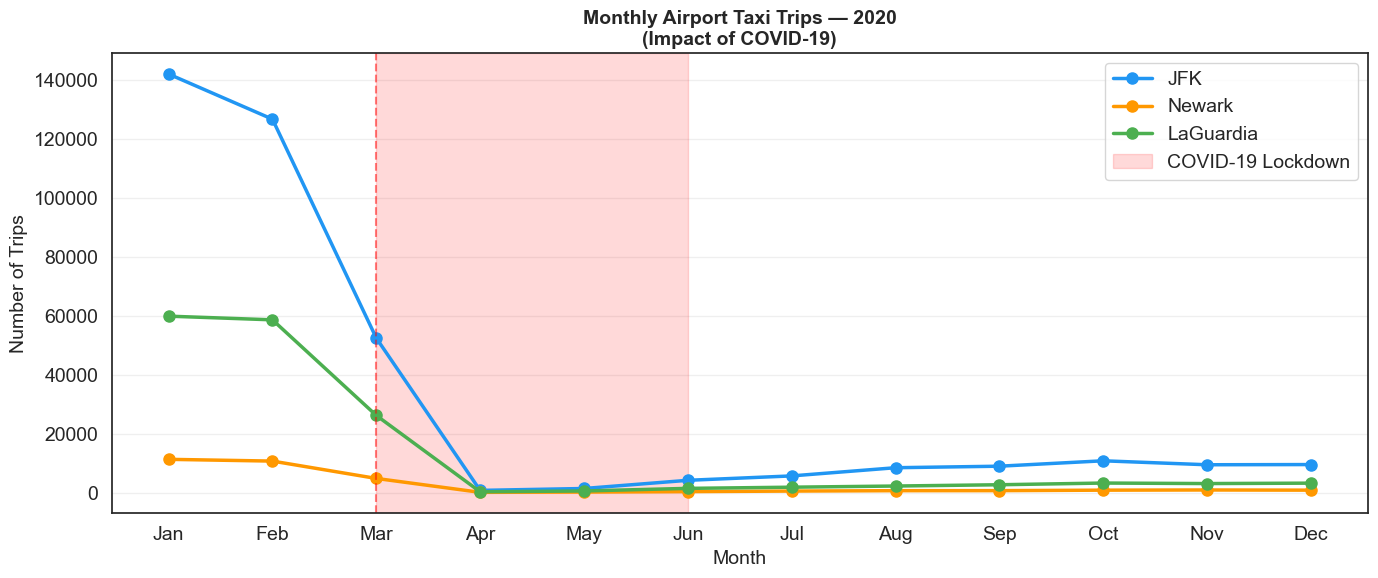

In [119]:
# Monthly Evolution of Trips to Airports
airport_monthly = spark.sql(
    """
    SELECT
        pickup_month,
        CASE
            WHEN RatecodeID = 2 THEN 'JFK'
            WHEN RatecodeID = 3 THEN 'Newark'
            WHEN DOLocationID = 138 THEN 'LaGuardia'
        END AS airport,
        COUNT(*) AS total_trips
    FROM taxi_data
    WHERE RatecodeID IN (2, 3) OR DOLocationID = 138
    GROUP BY pickup_month,
        CASE
            WHEN RatecodeID = 2 THEN 'JFK'
            WHEN RatecodeID = 3 THEN 'Newark'
            WHEN DOLocationID = 138 THEN 'LaGuardia'
        END
    ORDER BY pickup_month
    """
)

airport_monthly_pd = airport_monthly.toPandas()

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax = plt.subplots(figsize=(14, 6))

colors = {"JFK": "#2196F3", "Newark": "#FF9800", "LaGuardia": "#4CAF50"}

for airport in ["JFK", "Newark", "LaGuardia"]:
    data = airport_monthly_pd[airport_monthly_pd["airport"] == airport].sort_values("pickup_month")
    ax.plot(data["pickup_month"], data["total_trips"],
            marker="o", linewidth=2.5, markersize=8,
            label=airport, color=colors[airport])

# Marca o lockdown
ax.axvspan(3, 6, alpha=0.15, color="red", label="COVID-19 Lockdown")
ax.axvline(x=3, color="red", linestyle="--", alpha=0.5)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(months)
ax.set_title("Monthly Airport Taxi Trips — 2020\n(Impact of COVID-19)",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Number of Trips")
ax.set_xlabel("Month")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

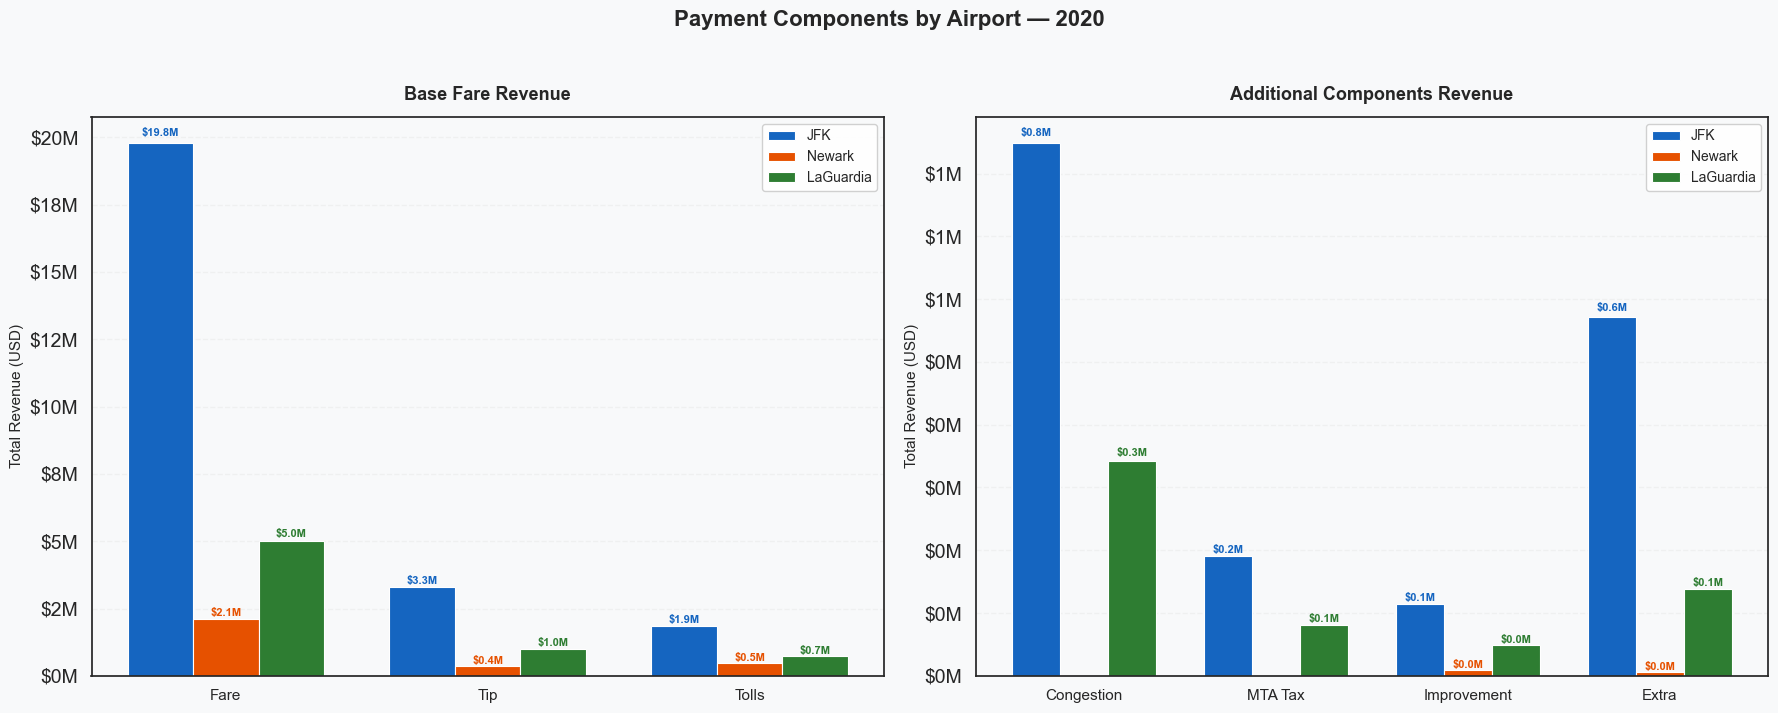

In [120]:
# Payment Components by airport
payment_components = spark.sql(
    """
    SELECT
        CASE
            WHEN RatecodeID = 2 THEN 'JFK'
            WHEN RatecodeID = 3 THEN 'Newark'
            WHEN DOLocationID = 138 THEN 'LaGuardia'
        END AS airport,
        ROUND(SUM(fare_amount), 2) AS total_fare,
        ROUND(SUM(tip_amount), 2) AS total_tip,
        ROUND(SUM(tolls_amount), 2) AS total_tolls,
        ROUND(SUM(congestion_surcharge), 2) AS total_congestion,
        ROUND(SUM(mta_tax), 2) AS total_mta,
        ROUND(SUM(improvement_surcharge), 2) AS total_improvement,
        ROUND(SUM(extra), 2) AS extra
    FROM taxi_data
    WHERE RatecodeID IN (2, 3) OR DOLocationID = 138
    GROUP BY
        CASE
            WHEN RatecodeID = 2 THEN 'JFK'
            WHEN RatecodeID = 3 THEN 'Newark'
            WHEN DOLocationID = 138 THEN 'LaGuardia'
        END
    ORDER BY airport
    """
)

payment_components_pd = payment_components.toPandas()

airports = ["JFK", "Newark", "LaGuardia"]
colors_airport = {"JFK": "#1565C0", "Newark": "#E65100", "LaGuardia": "#2E7D32"}

group1_cols = ["total_fare", "total_tip", "total_tolls"]
group1_labels = ["Fare", "Tip", "Tolls"]

group2_cols = ["total_congestion", "total_mta", "total_improvement", "extra"]
group2_labels = ["Congestion", "MTA Tax", "Improvement", "Extra"]

width = 0.25
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor("#F8F9FA")

def plot_components(ax, cols, labels, title):
    ax.set_facecolor("#F8F9FA")
    x = range(len(labels))

    for i, airport in enumerate(airports):
        row = payment_components_pd[payment_components_pd["airport"] == airport].iloc[0]
        values = [row[c] for c in cols]

        bars = ax.bar([xi + i * width for xi in x],
                      values,
                      width=width,
                      label=airport,
                      color=colors_airport[airport],
                      edgecolor="white",
                      linewidth=0.8)

        for bar, val in zip(bars, values):
            if val > 1000:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + bar.get_height() * 0.01,
                        f"${val/1e6:.1f}M",
                        ha="center", va="bottom",
                        fontsize=8, fontweight="bold",
                        color=colors_airport[airport])

    ax.set_xticks([xi + width for xi in x])
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_ylabel("Total Revenue (USD)", fontsize=11)
    ax.legend(fontsize=10, framealpha=0.9)
    ax.grid(axis="y", alpha=0.2, linestyle="--")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M"))

plot_components(ax1, group1_cols, group1_labels, "Base Fare Revenue")
plot_components(ax2, group2_cols, group2_labels, "Additional Components Revenue")

fig.suptitle("Payment Components by Airport — 2020",
             fontsize=16, fontweight="bold", y=1.02)

plt.tight_layout()
plt.show()

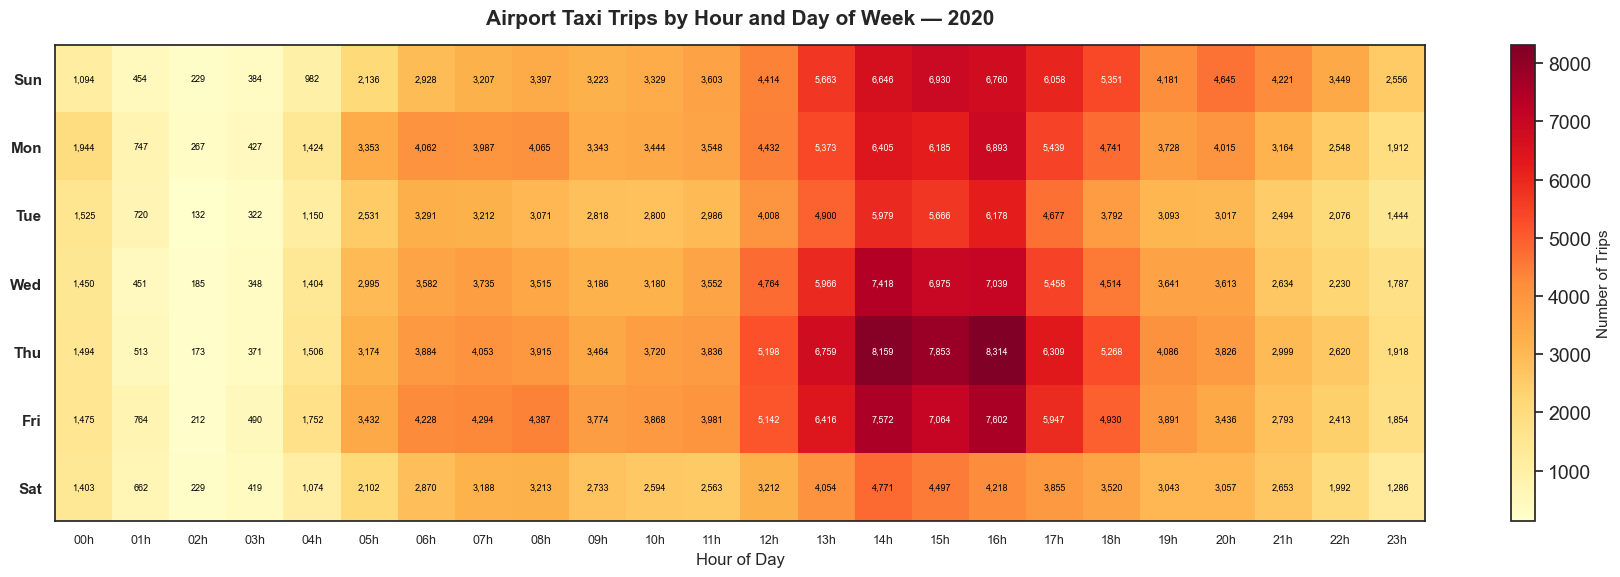

In [121]:
# Heatmap with trips by hour and day of week
heatmap_data = spark.sql(
    """
    SELECT
        pickup_hour,
        pickup_day_of_week,
        COUNT(*) AS total_trips
    FROM taxi_data
    WHERE RatecodeID IN (2, 3) OR DOLocationID = 138
    GROUP BY pickup_hour, pickup_day_of_week
    ORDER BY pickup_day_of_week, pickup_hour
    """
)

heatmap_data_pd = heatmap_data.toPandas()

# Pivot para formato matriz
pivot = heatmap_data_pd.pivot(index="pickup_day_of_week",
                  columns="pickup_hour",
                  values="total_trips").fillna(0)

days = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]
hours = [f"{h:02d}h" for h in range(24)]

fig, ax = plt.subplots(figsize=(18, 6))

im = ax.imshow(pivot.values, cmap="YlOrRd", aspect="auto")

# Anotações em cada célula
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        ax.text(j, i, f"{int(val):,}",
                ha="center", va="center",
                fontsize=6.5,
                color="black" if val < pivot.values.max() * 0.6 else "white")

ax.set_xticks(range(24))
ax.set_xticklabels(hours, fontsize=9)
ax.set_yticks(range(7))
ax.set_yticklabels(days, fontsize=11, fontweight="bold")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Number of Trips", fontsize=11)

ax.set_title("Airport Taxi Trips by Hour and Day of Week — 2020",
             fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Hour of Day", fontsize=12)

plt.tight_layout()
plt.show()

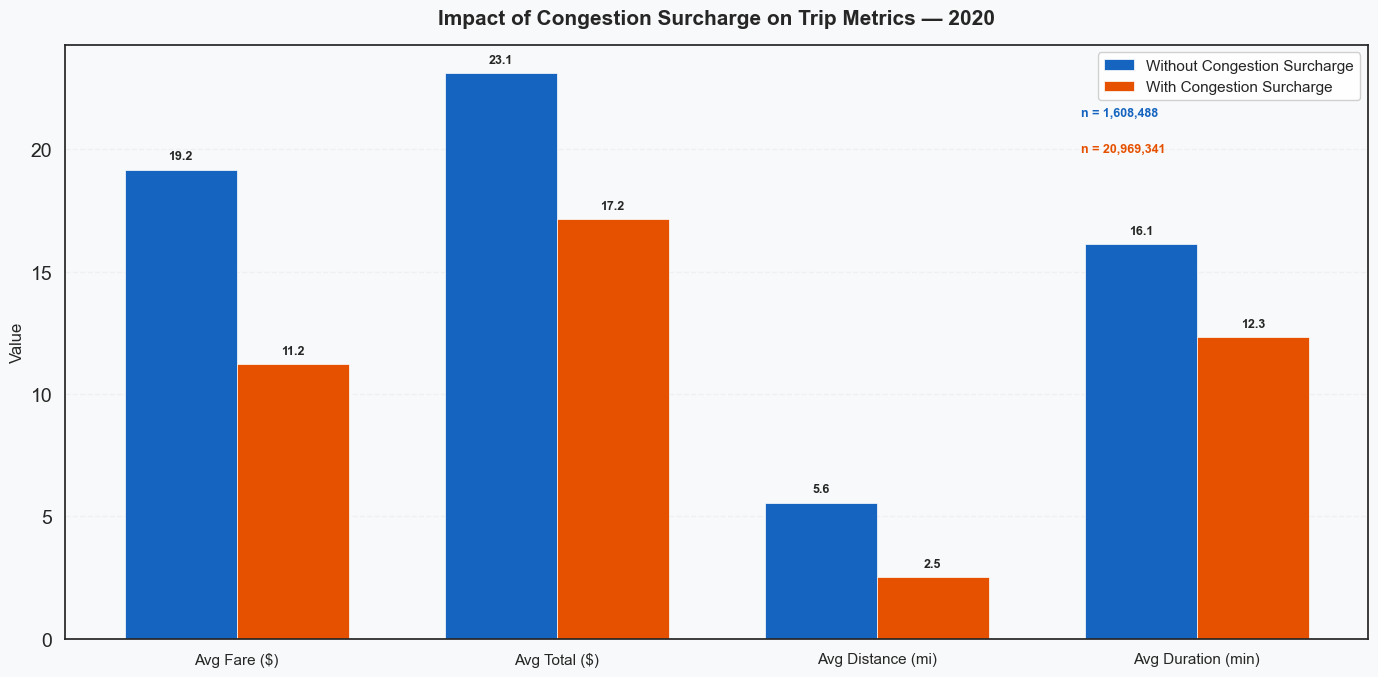

In [122]:
# Impact of Congestion Surcharge
congestion_impact = spark.sql(
    """
    SELECT
        CASE
            WHEN congestion_surcharge > 0 THEN 'With Congestion Surcharge'
            ELSE 'Without Congestion Surcharge'
        END AS congestion_group,
        COUNT(*) AS total_trips,
        ROUND(AVG(fare_amount), 2) AS avg_fare,
        ROUND(AVG(total_amount), 2) AS avg_total,
        ROUND(AVG(trip_distance), 2) AS avg_distance,
        ROUND(AVG(trip_duration_min), 2) AS avg_duration
    FROM taxi_data
    GROUP BY
        CASE
            WHEN congestion_surcharge > 0 THEN 'With Congestion Surcharge'
            ELSE 'Without Congestion Surcharge'
        END
    ORDER BY congestion_group DESC
    """
)

congestion_impact_pd = congestion_impact.toPandas()

metrics = ["avg_fare", "avg_total", "avg_distance", "avg_duration"]
labels = ["Avg Fare ($)", "Avg Total ($)", "Avg Distance (mi)", "Avg Duration (min)"]
colors = ["#1565C0", "#E65100"]

x = range(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))

for i, (_, row) in enumerate(congestion_impact_pd.iterrows()):
    values = [row[m] for m in metrics]
    bars = ax.bar([xi + i * width for xi in x], values,
                  width=width, label=row["congestion_group"],
                  color=colors[i], edgecolor="white", linewidth=0.5)

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                f"{val:.1f}",
                ha="center", va="bottom",
                fontsize=9, fontweight="bold")

ax.set_xticks([xi + width / 2 for xi in x])
ax.set_xticklabels(labels, fontsize=11)
ax.set_title("Impact of Congestion Surcharge on Trip Metrics — 2020",
             fontsize=15, fontweight="bold", pad=15)
ax.set_ylabel("Value", fontsize=12)
ax.legend(fontsize=11, framealpha=0.9)
ax.grid(axis="y", alpha=0.2, linestyle="--")
ax.set_facecolor("#F8F9FA")
fig.patch.set_facecolor("#F8F9FA")

legend = ax.legend(fontsize=11, framealpha=0.9)

for i, (_, row) in enumerate(congestion_impact_pd.iterrows()):
    ax.annotate(f"n = {int(row['total_trips']):,}",
                xy=(0, 0), xycoords='axes fraction',
                xytext=(0.78, 0.88 - i * 0.06),
                textcoords='axes fraction',
                fontsize=9, color=colors[i], fontweight="bold")

plt.tight_layout()
plt.show()

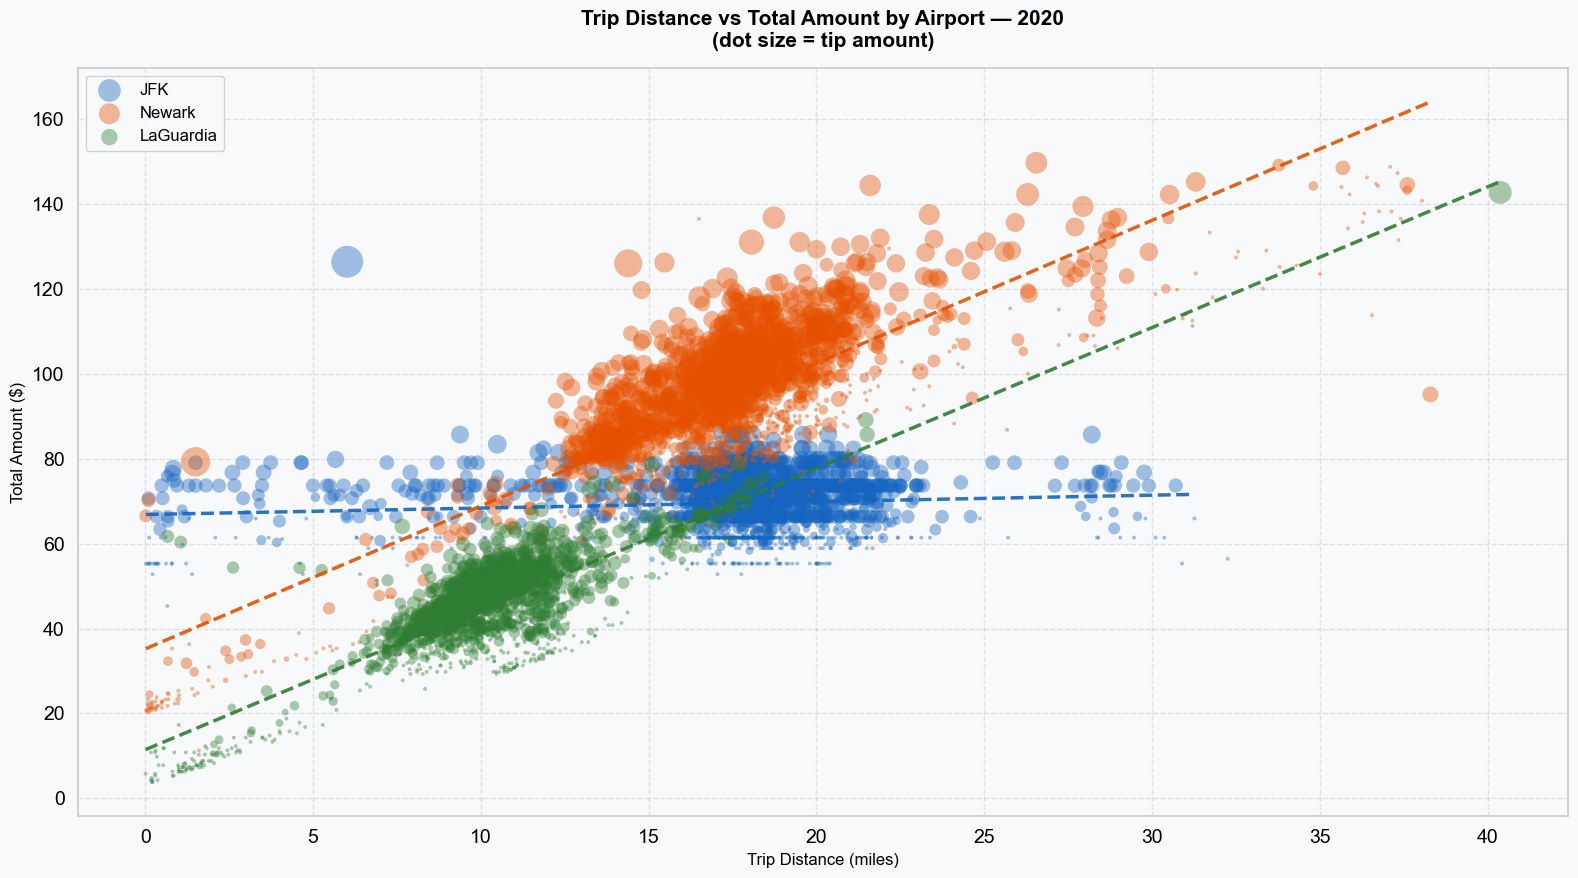

In [123]:
# Trip distance and total amount by airport
scatter_data = spark.sql(
    """
    SELECT
        CASE
            WHEN RatecodeID = 2 THEN 'JFK'
            WHEN RatecodeID = 3 THEN 'Newark'
            WHEN DOLocationID = 138 THEN 'LaGuardia'
        END AS airport,
        trip_distance,
        total_amount,
        tip_amount
    FROM taxi_data
    WHERE (RatecodeID IN (2, 3) OR DOLocationID = 138)
    AND trip_distance > 0
    AND trip_distance < 50
    AND total_amount < 150
    """
)

scatter_data_pd = scatter_data.toPandas()

airports = ["JFK", "Newark", "LaGuardia"]
colors = {"JFK": "#1565C0", "Newark": "#E65100", "LaGuardia": "#2E7D32"}

fig, ax = plt.subplots(figsize=(16, 9))
ax.set_facecolor("#F8F9FA")
fig.patch.set_facecolor("#F8F9FA")

for airport in airports:
    data = scatter_data_pd[scatter_data_pd["airport"] == airport]

    sample = data.sample(min(2000, len(data)), random_state=42)

    sizes = (sample["tip_amount"] + 1) * 8

    ax.scatter(sample["trip_distance"], sample["total_amount"],
               c=colors[airport], s=sizes, alpha=0.4,
               label=airport, edgecolors="none")

    z = np.polyfit(sample["trip_distance"], sample["total_amount"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(sample["trip_distance"].min(),
                         sample["trip_distance"].max(), 100)
    ax.plot(x_line, p(x_line), color=colors[airport],
            linewidth=2.5, linestyle="--", alpha=0.9)

ax.set_title("Trip Distance vs Total Amount by Airport — 2020\n(dot size = tip amount)",
             fontsize=15, fontweight="bold", color="black", pad=15)
ax.set_xlabel("Trip Distance (miles)", fontsize=12, color="black")
ax.set_ylabel("Total Amount ($)", fontsize=12, color="black")
ax.tick_params(colors="black")
ax.spines[:].set_color("#CCCCCC")
ax.grid(alpha=0.2, color="gray", linestyle="--")

legend = ax.legend(fontsize=12, framealpha=0.9,
                   facecolor="#F8F9FA")
plt.setp(legend.get_texts(), color="black")

plt.tight_layout()
plt.show()

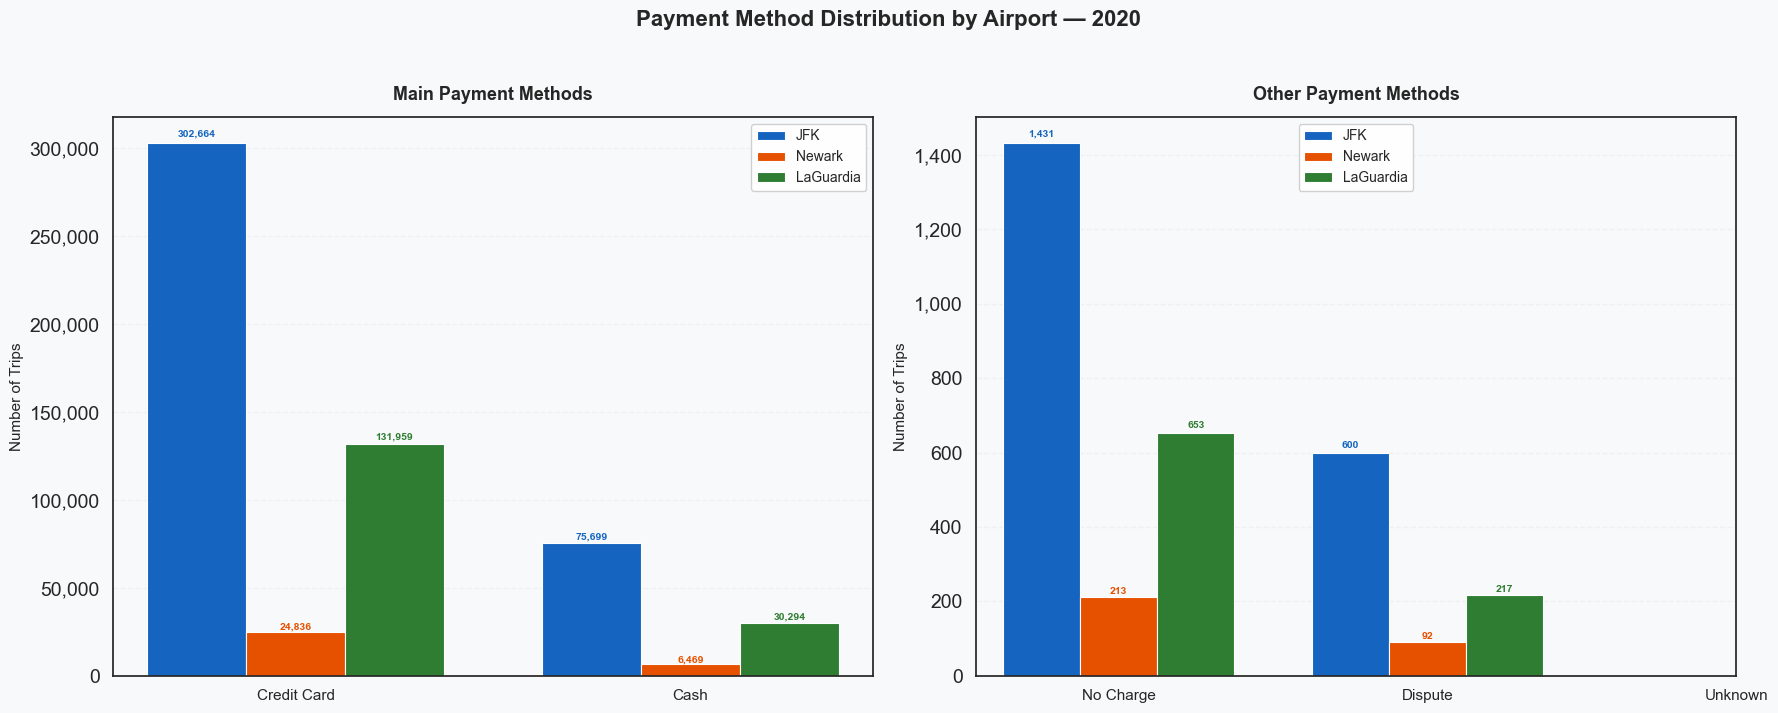

In [124]:
# Distribution of Payment Methods by Airport
payment_pie = spark.sql(
    """
    SELECT
        CASE
            WHEN RatecodeID = 2 THEN 'JFK'
            WHEN RatecodeID = 3 THEN 'Newark'
            WHEN DOLocationID = 138 THEN 'LaGuardia'
        END AS airport,
        CASE payment_type
            WHEN 1 THEN 'Credit Card'
            WHEN 2 THEN 'Cash'
            WHEN 3 THEN 'No Charge'
            WHEN 4 THEN 'Dispute'
            WHEN 5 THEN 'Unknown'
        END AS payment_method,
        COUNT(*) AS total_trips
    FROM taxi_data
    WHERE RatecodeID IN (2, 3) OR DOLocationID = 138
    GROUP BY
        CASE
            WHEN RatecodeID = 2 THEN 'JFK'
            WHEN RatecodeID = 3 THEN 'Newark'
            WHEN DOLocationID = 138 THEN 'LaGuardia'
        END,
        CASE payment_type
            WHEN 1 THEN 'Credit Card'
            WHEN 2 THEN 'Cash'
            WHEN 3 THEN 'No Charge'
            WHEN 4 THEN 'Dispute'
            WHEN 5 THEN 'Unknown'
        END
    ORDER BY airport, total_trips DESC
    """
)

payment_pie_pd = payment_pie.toPandas()

airports = ["JFK", "Newark", "LaGuardia"]
colors = {"JFK": "#1565C0", "Newark": "#E65100", "LaGuardia": "#2E7D32"}

pivot = payment_pie_pd.pivot(index="payment_method", columns="airport", values="total_trips").fillna(0)

# Separar em dois grupos
group1 = pivot.reindex(["Credit Card", "Cash"]).sort_values("JFK", ascending=False)
group2 = pivot.reindex(["No Charge", "Dispute", "Unknown"]).sort_values("JFK", ascending=False)

width = 0.25
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor("#F8F9FA")

def plot_group(ax, data, title):
    ax.set_facecolor("#F8F9FA")
    x = range(len(data.index))

    for i, airport in enumerate(airports):
        bars = ax.bar([xi + i * width for xi in x],
                      data[airport],
                      width=width,
                      label=airport,
                      color=colors[airport],
                      edgecolor="white",
                      linewidth=0.8)

        for bar in bars:
            val = bar.get_height()
            if val > 10:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + val * 0.01,
                        f"{int(val):,}",
                        ha="center", va="bottom",
                        fontsize=7.5, fontweight="bold",
                        color=colors[airport])

    ax.set_xticks([xi + width for xi in x])
    ax.set_xticklabels(data.index, fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_ylabel("Number of Trips", fontsize=11)
    ax.legend(fontsize=10, framealpha=0.9)
    ax.grid(axis="y", alpha=0.2, linestyle="--")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

plot_group(ax1, group1, "Main Payment Methods")
plot_group(ax2, group2, "Other Payment Methods")

fig.suptitle("Payment Method Distribution by Airport — 2020",
             fontsize=16, fontweight="bold", y=1.02)

plt.tight_layout()
plt.show()

#### **VER MELHOR SE ESTÁ A SER USADO E ONDE**

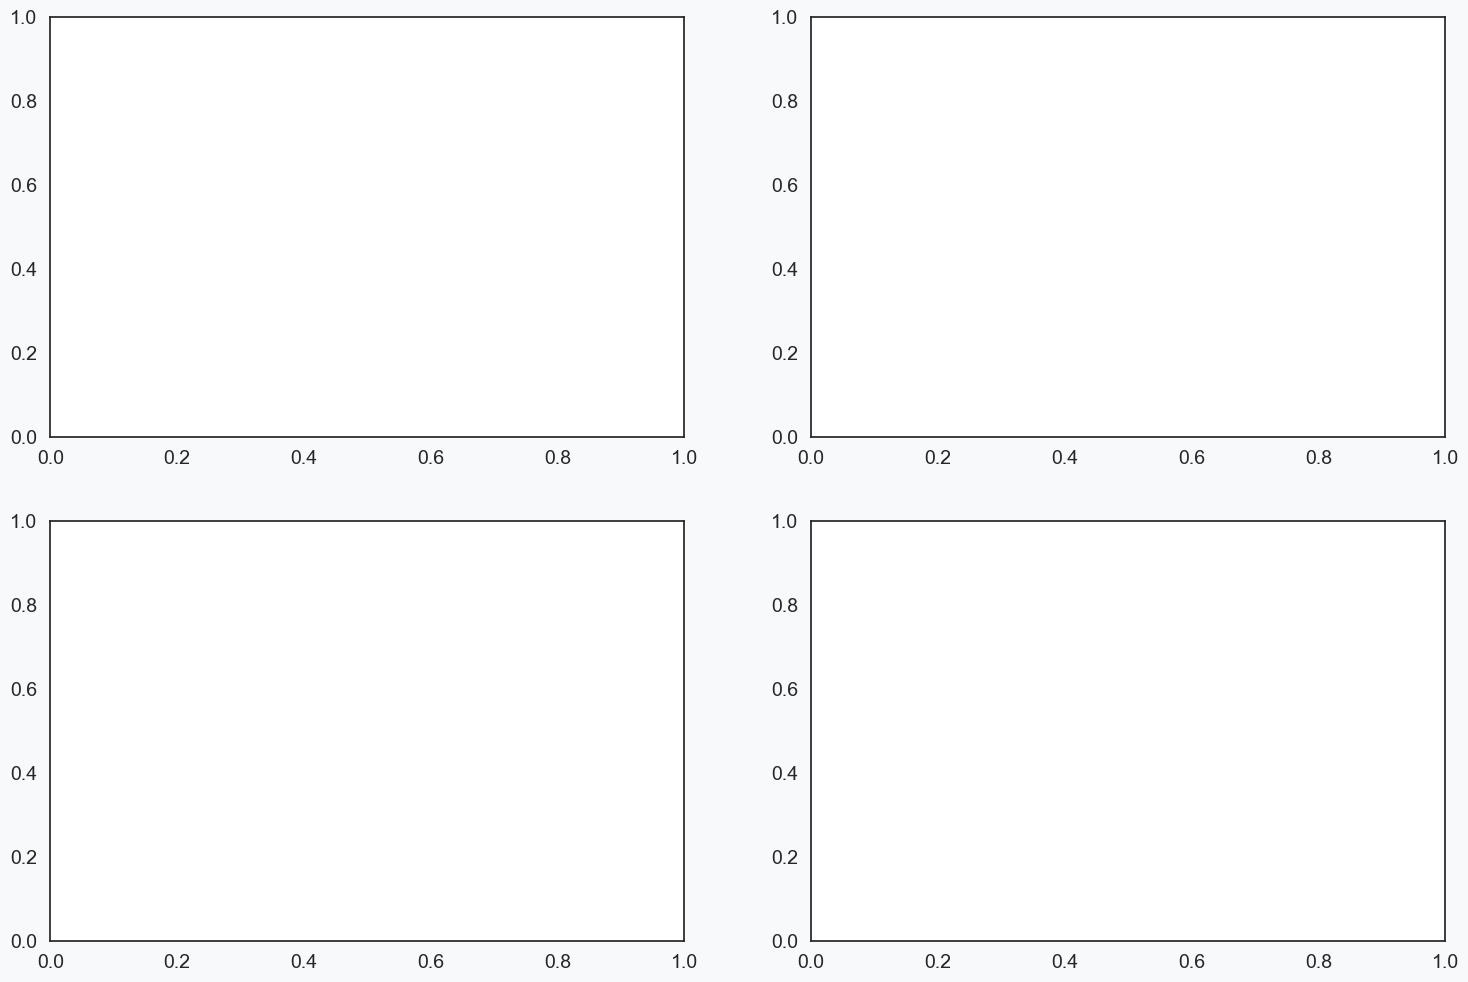

In [125]:
# Passenger Count by Airport
passenger_airport = spark.sql(
    """
    SELECT
        CASE
            WHEN RatecodeID = 2 THEN 'JFK'
            WHEN RatecodeID = 3 THEN 'Newark'
            WHEN DOLocationID = 138 THEN 'LaGuardia'
        END AS airport,
        passenger_count,
        COUNT(*) AS total_trips,
        ROUND(AVG(total_amount), 2) AS avg_total,
        ROUND(AVG(tip_amount), 2) AS avg_tip
    FROM taxi_data
    WHERE RatecodeID IN (2, 3) OR DOLocationID = 138
    GROUP BY
        CASE
            WHEN RatecodeID = 2 THEN 'JFK'
            WHEN RatecodeID = 3 THEN 'Newark'
            WHEN DOLocationID = 138 THEN 'LaGuardia'
        END,
        passenger_count
    ORDER BY airport, passenger_count
    """
)

passenger_airport_pd = passenger_airport.toPandas()

airports = ["JFK", "Newark", "LaGuardia"]
colors_airport = {"JFK": "#1565C0", "Newark": "#E65100", "LaGuardia": "#2E7D32"}

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.patch.set_facecolor("#F8F9FA")

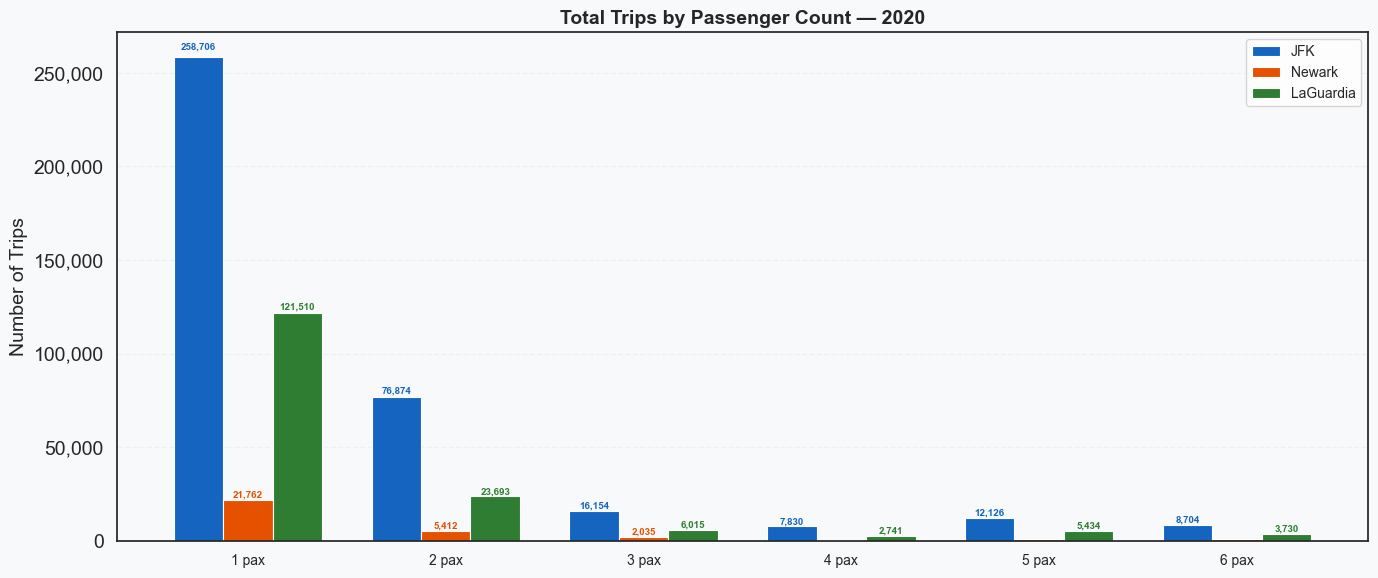

In [126]:
# Total Trips by Passenger Count and Airport
pivot_trips = passenger_airport_pd.pivot(index="passenger_count", columns="airport",
                         values="total_trips").fillna(0)
x = range(len(pivot_trips.index))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
ax.set_facecolor("#F8F9FA")
fig.patch.set_facecolor("#F8F9FA")

for i, airport in enumerate(airports):
    bars = ax.bar([xi + i * width for xi in x],
                   pivot_trips[airport],
                   width=width, label=airport,
                   color=colors_airport[airport],
                   edgecolor="white", linewidth=0.8)
    for bar in bars:
        val = bar.get_height()
        if val > 1000:
            ax.text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + val * 0.01,
                     f"{int(val):,}",
                     ha="center", va="bottom",
                     fontsize=7, fontweight="bold",
                     color=colors_airport[airport])

ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels([f"{int(p)} pax" for p in pivot_trips.index], fontsize=10)
ax.set_title("Total Trips by Passenger Count — 2020", fontsize=14, fontweight="bold")
ax.set_ylabel("Number of Trips")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.2, linestyle="--")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.show()

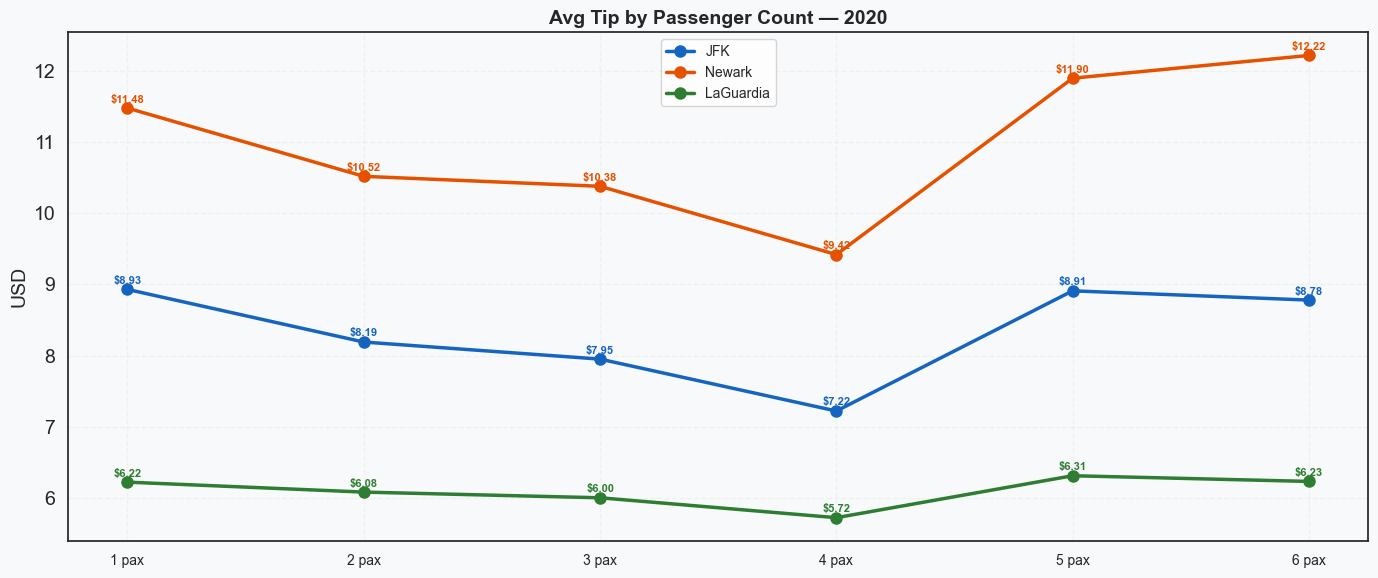

In [127]:
# Avg Tip by Passenger Count and Airport
pivot_tip = passenger_airport_pd.pivot(index="passenger_count", columns="airport",
                       values="avg_tip").fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))
ax.set_facecolor("#F8F9FA")
fig.patch.set_facecolor("#F8F9FA")

for airport in airports:
    ax.plot(pivot_tip.index, pivot_tip[airport],
             marker="o", linewidth=2.5, markersize=8,
             label=airport, color=colors_airport[airport])
    for x, y in zip(pivot_tip.index, pivot_tip[airport]):
        ax.text(x, y + 0.05, f"${y:.2f}",
                ha="center", va="bottom",
                fontsize=8, fontweight="bold",
                color=colors_airport[airport])

ax.set_xticks(pivot_tip.index)
ax.set_xticklabels([f"{int(p)} pax" for p in pivot_tip.index], fontsize=10)
ax.set_title("Avg Tip by Passenger Count — 2020", fontsize=14, fontweight="bold")
ax.set_ylabel("USD")
ax.legend(fontsize=10)
ax.grid(alpha=0.2, linestyle="--")

plt.tight_layout()
plt.show()

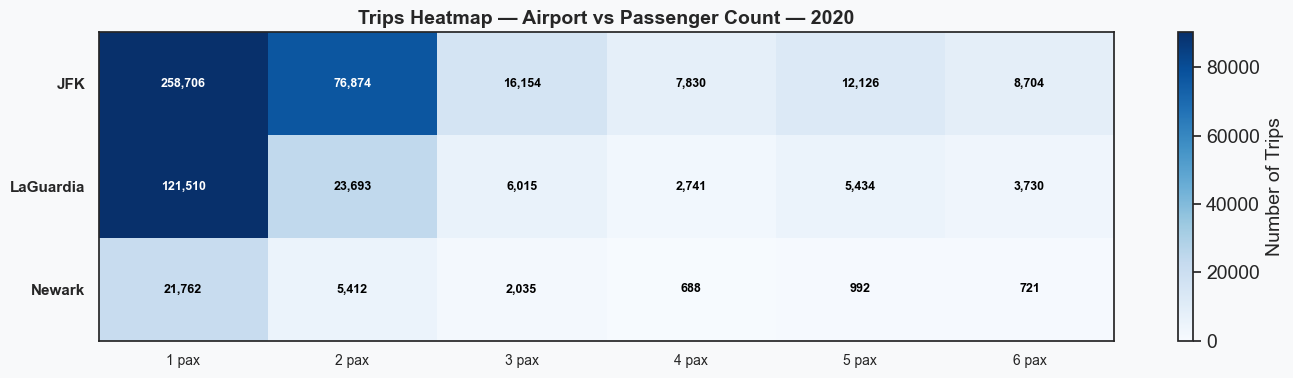

In [128]:
# Heatmap trips by passenger count and airport
pivot_heat = passenger_airport_pd.pivot(index="airport", columns="passenger_count",
                        values="total_trips").fillna(0)

fig, ax = plt.subplots(figsize=(14, 4))
ax.set_facecolor("#F8F9FA")
fig.patch.set_facecolor("#F8F9FA")

vmax = np.percentile(pivot_heat.values, 90)

im = ax.imshow(pivot_heat.values, cmap="Blues", aspect="auto",
               vmin=0, vmax=vmax)

for i in range(len(pivot_heat.index)):
    for j in range(len(pivot_heat.columns)):
        val = pivot_heat.values[i, j]
        ax.text(j, i, f"{int(val):,}",
                 ha="center", va="center",
                 fontsize=9, fontweight="bold",
                 color="white" if val > 70000 else "black")

ax.set_xticks(range(len(pivot_heat.columns)))
ax.set_xticklabels([f"{int(p)} pax" for p in pivot_heat.columns], fontsize=10)
ax.set_yticks(range(len(pivot_heat.index)))
ax.set_yticklabels(pivot_heat.index, fontsize=11, fontweight="bold")
ax.set_title("Trips Heatmap — Airport vs Passenger Count — 2020",
              fontsize=14, fontweight="bold")
plt.colorbar(im, ax=ax).set_label("Number of Trips")

plt.tight_layout()
plt.show()

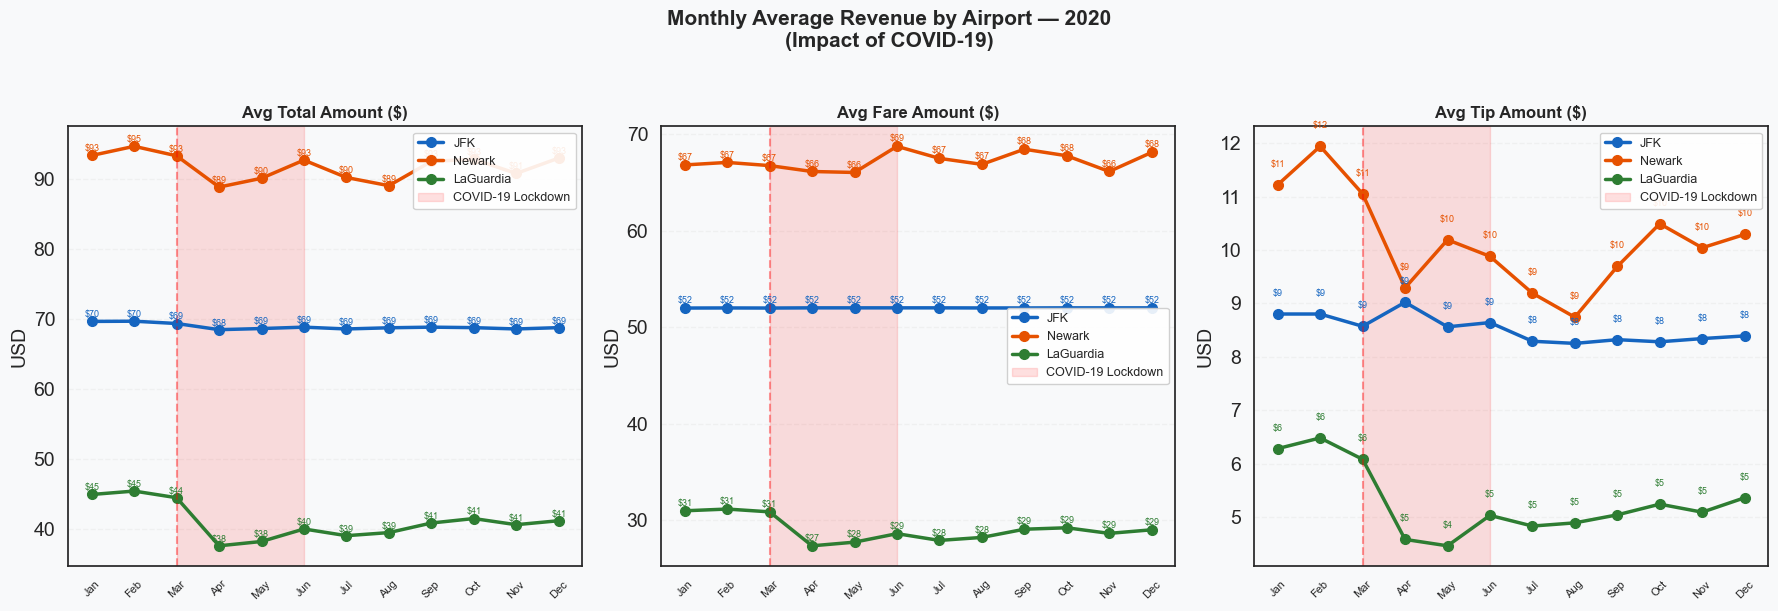

In [129]:
# Monthly Evolution of Average Revenue by Airport
revenue_monthly = spark.sql(
    """
    SELECT
        pickup_month,
        CASE
            WHEN RatecodeID = 2 THEN 'JFK'
            WHEN RatecodeID = 3 THEN 'Newark'
            WHEN DOLocationID = 138 THEN 'LaGuardia'
        END AS airport,
        ROUND(AVG(total_amount), 2) AS avg_revenue,
        ROUND(AVG(fare_amount), 2) AS avg_fare,
        ROUND(AVG(tip_amount), 2) AS avg_tip
    FROM taxi_data
    WHERE RatecodeID IN (2, 3) OR DOLocationID = 138
    GROUP BY pickup_month,
        CASE
            WHEN RatecodeID = 2 THEN 'JFK'
            WHEN RatecodeID = 3 THEN 'Newark'
            WHEN DOLocationID = 138 THEN 'LaGuardia'
        END
    ORDER BY pickup_month
    """
)

revenue_monthly_pd = revenue_monthly.toPandas()

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

colors = {"JFK": "#1565C0", "Newark": "#E65100", "LaGuardia": "#2E7D32"}

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
fig.patch.set_facecolor("#F8F9FA")

metrics = ["avg_revenue", "avg_fare", "avg_tip"]
titles = ["Avg Total Amount ($)", "Avg Fare Amount ($)", "Avg Tip Amount ($)"]

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx]
    ax.set_facecolor("#F8F9FA")

    for airport in ["JFK", "Newark", "LaGuardia"]:
        data = revenue_monthly_pd[revenue_monthly_pd["airport"] == airport].sort_values("pickup_month")
        ax.plot(data["pickup_month"], data[metric],
                marker="o", linewidth=2.5, markersize=7,
                label=airport, color=colors[airport])

        for _, row in data.iterrows():
            ax.text(row["pickup_month"], row[metric] + 0.3,
                    f"${row[metric]:.0f}",
                    ha="center", va="bottom",
                    fontsize=6.5, color=colors[airport])

    ax.axvspan(3, 6, alpha=0.12, color="red", label="COVID-19 Lockdown")
    ax.axvline(x=3, color="red", linestyle="--", alpha=0.4)

    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(months, fontsize=8, rotation=45)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("USD")
    ax.legend(fontsize=9, framealpha=0.9)
    ax.grid(axis="y", alpha=0.2, linestyle="--")

fig.suptitle("Monthly Average Revenue by Airport — 2020\n(Impact of COVID-19)",
             fontsize=15, fontweight="bold", y=1.02)

plt.tight_layout()
plt.show()

#### **Ajeitar!!**

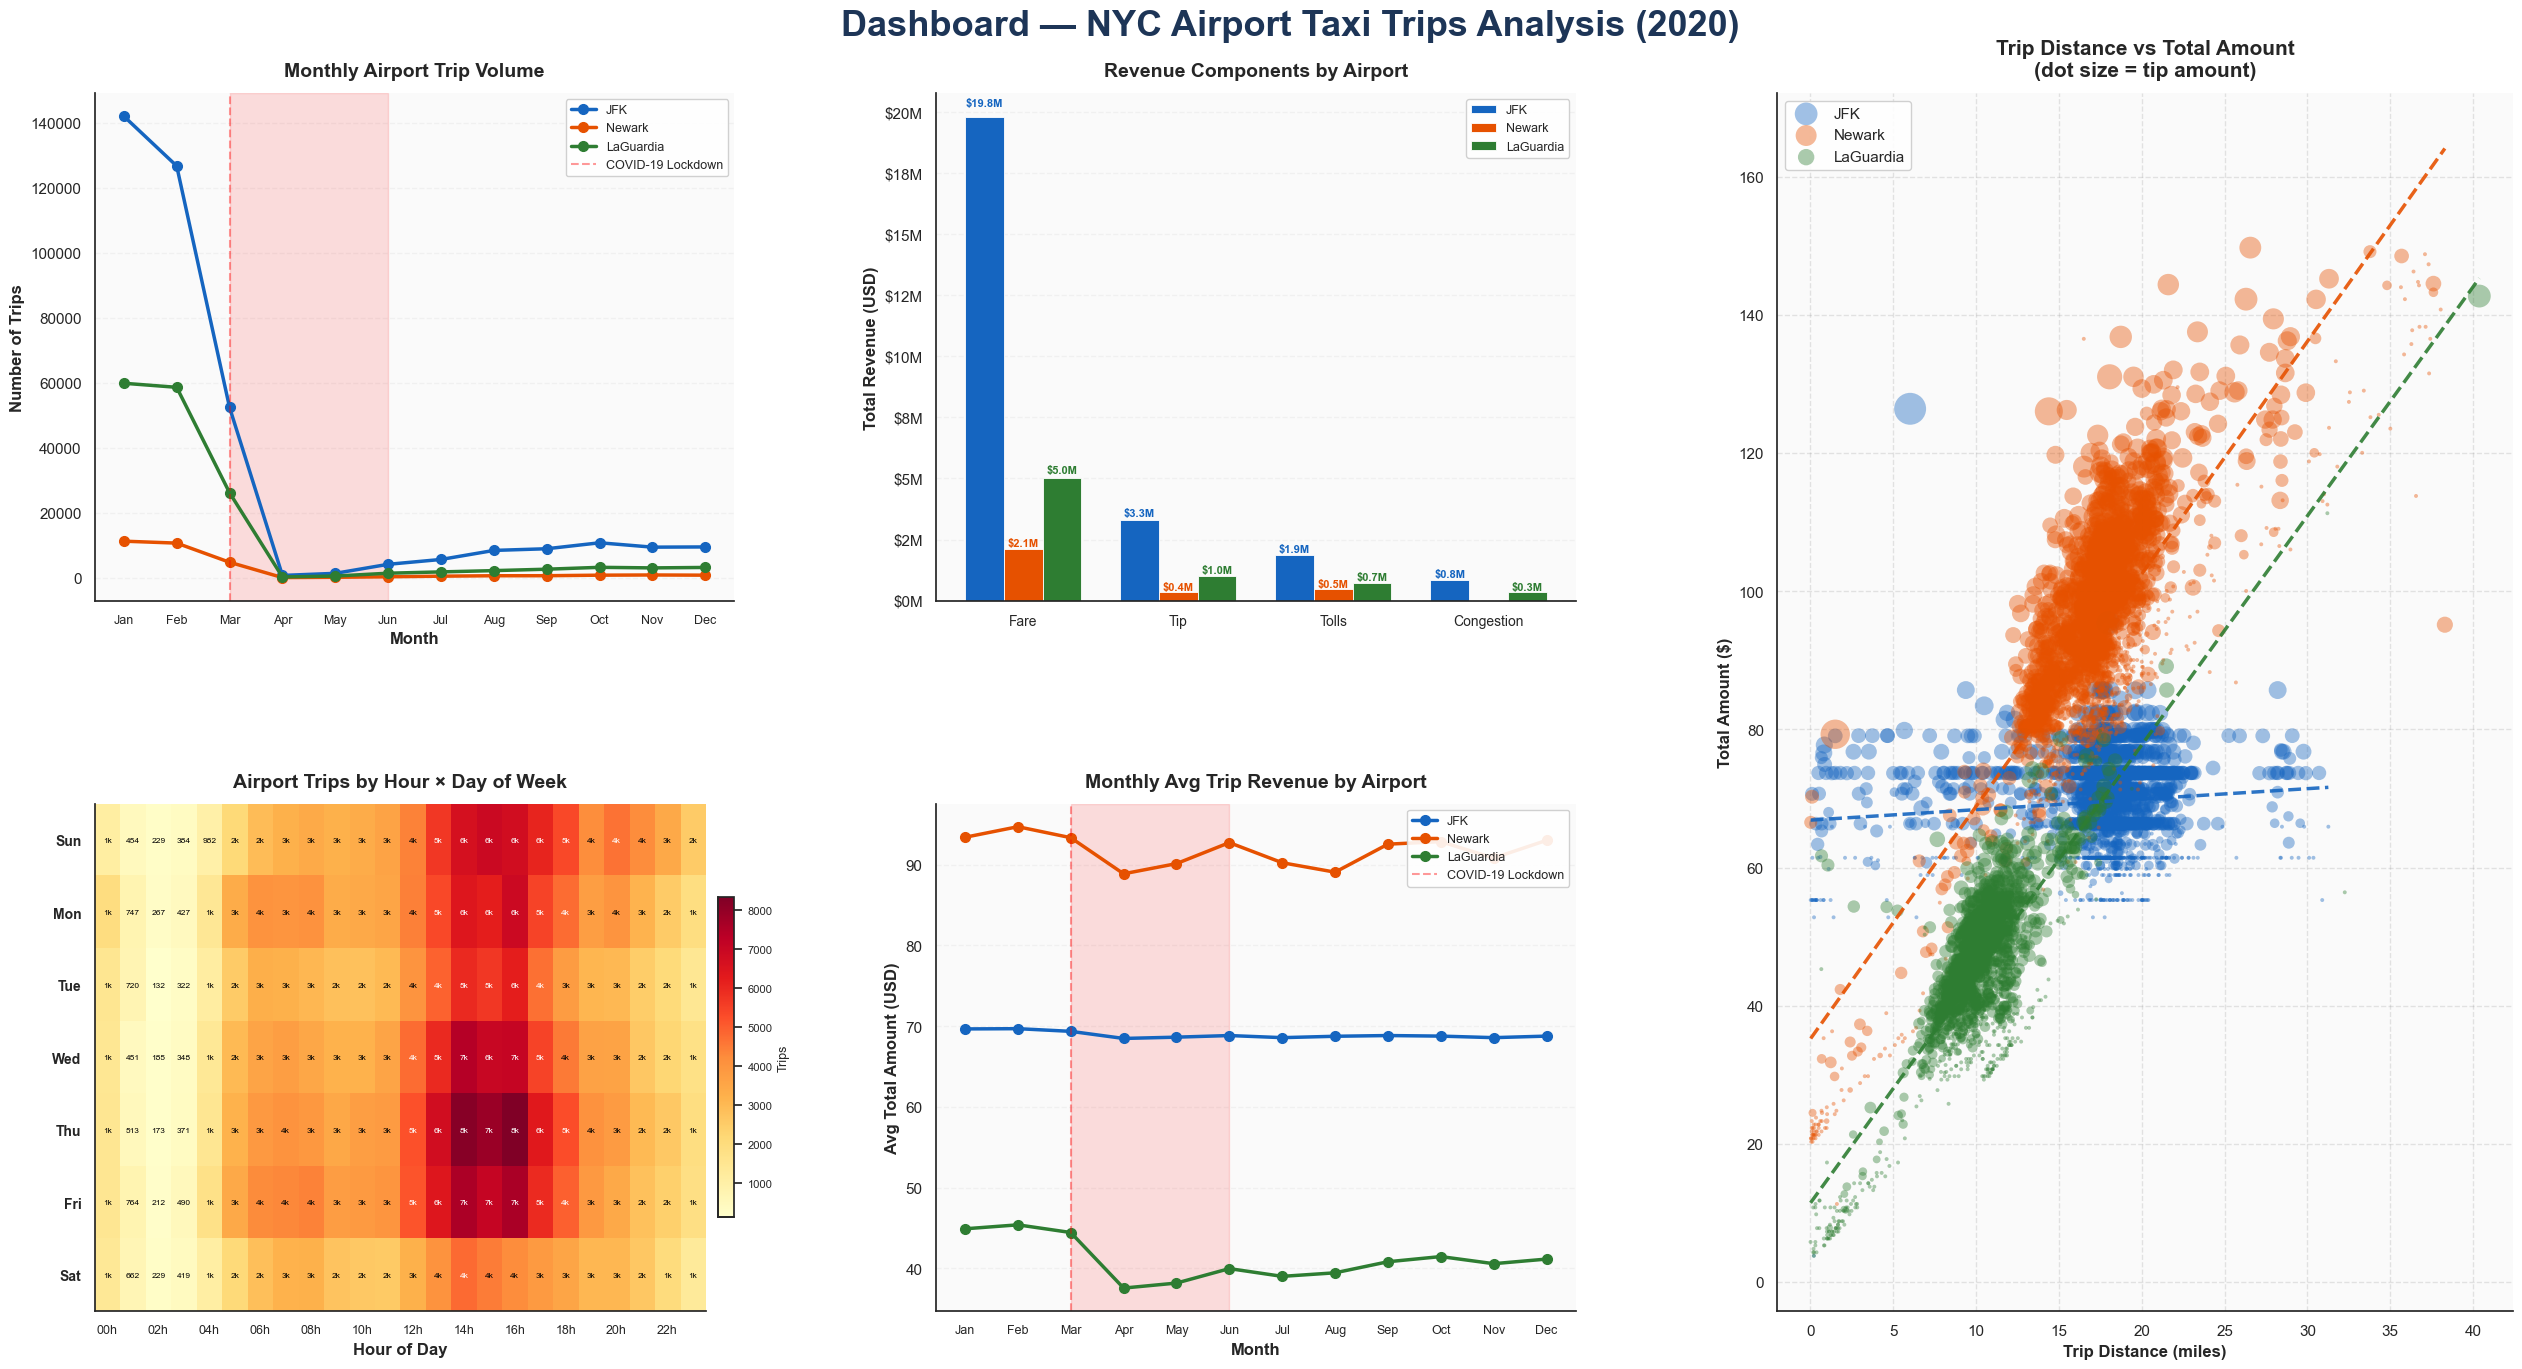

In [133]:
# ============================================================
# DASHBOARD RENDERING
# ============================================================

sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'

# Shared palette
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
days = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]
airport_colors = {"JFK": "#1565C0", "Newark": "#E65100", "LaGuardia": "#2E7D32"}
airports = ["JFK", "Newark", "LaGuardia"]

fig = plt.figure(figsize=(26, 14), facecolor='white')
gs = GridSpec(2, 3, figure=fig, hspace=0.40, wspace=0.30,
              width_ratios=[1, 1, 1.15])

fig.suptitle(
    "Dashboard — NYC Airport Taxi Trips Analysis (2020)",
    fontsize=26, fontweight='bold', color="#1d3557", y=0.99
)

# ------------------------------------------------------------
# G1: TOP-LEFT — Monthly trip volume by airport
# ------------------------------------------------------------
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor("#FAFAFA")

for airport in airports:
    data = airport_monthly_pd[airport_monthly_pd["airport"] == airport].sort_values("pickup_month")
    ax1.plot(data["pickup_month"], data["total_trips"],
             marker="o", linewidth=2.5, markersize=7,
             label=airport, color=airport_colors[airport])

ax1.axvspan(3, 6, alpha=0.12, color="red")
ax1.axvline(x=3, color="red", linestyle="--", alpha=0.4, label="COVID-19 Lockdown")

ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(months, fontsize=9)
ax1.set_title("Monthly Airport Trip Volume", fontsize=14, fontweight="bold", pad=12)
ax1.set_ylabel("Number of Trips", fontweight='bold')
ax1.set_xlabel("Month", fontweight='bold')
ax1.legend(fontsize=9, framealpha=0.9, loc="upper right")
ax1.grid(axis="y", alpha=0.2, linestyle="--")

# ------------------------------------------------------------
# G2: TOP-MIDDLE — Payment components (only top 4 to save space)
# ------------------------------------------------------------
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor("#FAFAFA")

group1_cols = ["total_fare", "total_tip", "total_tolls", "total_congestion"]
group1_labels = ["Fare", "Tip", "Tolls", "Congestion"]
width = 0.25
x = range(len(group1_labels))

for i, airport in enumerate(airports):
    row = payment_components_pd[payment_components_pd["airport"] == airport].iloc[0]
    values = [row[c] for c in group1_cols]
    bars = ax2.bar([xi + i * width for xi in x], values,
                   width=width, label=airport,
                   color=airport_colors[airport],
                   edgecolor="white", linewidth=0.6)

    for bar, val in zip(bars, values):
        if val > 1e5:
            ax2.text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + bar.get_height() * 0.02,
                     f"${val/1e6:.1f}M",
                     ha="center", va="bottom",
                     fontsize=8, fontweight="bold",
                     color=airport_colors[airport])

ax2.set_xticks([xi + width for xi in x])
ax2.set_xticklabels(group1_labels, fontsize=10)
ax2.set_title("Revenue Components by Airport", fontsize=14, fontweight="bold", pad=12)
ax2.set_ylabel("Total Revenue (USD)", fontweight='bold')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M"))
ax2.legend(fontsize=9, framealpha=0.9)
ax2.grid(axis="y", alpha=0.2, linestyle="--")

# ------------------------------------------------------------
# G3: BOTTOM-LEFT — Heatmap (hour × day of week)
# ------------------------------------------------------------
ax3 = fig.add_subplot(gs[1, 0])

pivot = heatmap_data_pd.pivot(index="pickup_day_of_week",
                         columns="pickup_hour",
                         values="total_trips").fillna(0)

im = ax3.imshow(pivot.values, cmap="YlOrRd", aspect="auto")

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        ax3.text(j, i, f"{int(val/1000)}k" if val >= 1000 else f"{int(val)}",
                 ha="center", va="center", fontsize=6,
                 color="black" if val < pivot.values.max() * 0.55 else "white")

ax3.set_xticks(range(0, 24, 2))
ax3.set_xticklabels([f"{h:02d}h" for h in range(0, 24, 2)], fontsize=9)
ax3.set_yticks(range(7))
ax3.set_yticklabels(days, fontsize=10, fontweight="bold")

cbar = plt.colorbar(im, ax=ax3, fraction=0.025, pad=0.02)
cbar.set_label("Trips", fontsize=9)
cbar.ax.tick_params(labelsize=8)

ax3.set_title("Airport Trips by Hour × Day of Week", fontsize=14, fontweight="bold", pad=12)
ax3.set_xlabel("Hour of Day", fontweight='bold')

# ------------------------------------------------------------
# G5: BOTTOM-MIDDLE — Monthly avg revenue
# ------------------------------------------------------------
ax5 = fig.add_subplot(gs[1, 1])
ax5.set_facecolor("#FAFAFA")

for airport in airports:
    data = revenue_monthly_pd[revenue_monthly_pd["airport"] == airport].sort_values("pickup_month")
    ax5.plot(data["pickup_month"], data["avg_revenue"],
             marker="o", linewidth=2.5, markersize=7,
             label=airport, color=airport_colors[airport])

ax5.axvspan(3, 6, alpha=0.12, color="red")
ax5.axvline(x=3, color="red", linestyle="--", alpha=0.4, label="COVID-19 Lockdown")

ax5.set_xticks(range(1, 13))
ax5.set_xticklabels(months, fontsize=9)
ax5.set_title("Monthly Avg Trip Revenue by Airport", fontsize=14, fontweight="bold", pad=12)
ax5.set_ylabel("Avg Total Amount (USD)", fontweight='bold')
ax5.set_xlabel("Month", fontweight='bold')
ax5.legend(fontsize=9, framealpha=0.9, loc="upper right")
ax5.grid(axis="y", alpha=0.2, linestyle="--")

# ------------------------------------------------------------
# G4: RIGHT COLUMN (rowspan 2) — Scatter
# ------------------------------------------------------------
ax4 = fig.add_subplot(gs[:, 2])
ax4.set_facecolor("#FAFAFA")

for airport in airports:
    data = scatter_data_pd[scatter_data_pd["airport"] == airport]
    sample = data.sample(min(2000, len(data)), random_state=42)

    sizes = (sample["tip_amount"] + 1) * 8

    ax4.scatter(sample["trip_distance"], sample["total_amount"],
                c=airport_colors[airport], s=sizes, alpha=0.4,
                label=airport, edgecolors="none")

    z = np.polyfit(sample["trip_distance"], sample["total_amount"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(sample["trip_distance"].min(),
                         sample["trip_distance"].max(), 100)
    ax4.plot(x_line, p(x_line), color=airport_colors[airport],
             linewidth=2.5, linestyle="--", alpha=0.9)

ax4.set_title("Trip Distance vs Total Amount\n(dot size = tip amount)",
              fontsize=15, fontweight="bold", pad=12)
ax4.set_xlabel("Trip Distance (miles)", fontsize=12, fontweight='bold')
ax4.set_ylabel("Total Amount ($)", fontsize=12, fontweight='bold')
ax4.legend(fontsize=11, framealpha=0.9, loc="upper left")
ax4.grid(alpha=0.2, color="gray", linestyle="--")

sns.despine(fig=fig, left=False, bottom=False)
plt.subplots_adjust(top=0.93, bottom=0.06, left=0.04, right=0.97)
plt.show()

### **4.5. Efficiency and Operations**

**Efficiency vs. Demand: Hourly Analysis of Taxi Operations**

In [134]:
df_speed = taxi_df.withColumn(
    "duration_min",
    (F.unix_timestamp("tpep_dropoff_datetime") - F.unix_timestamp("tpep_pickup_datetime")) / 60
).withColumn(
    "hour", F.hour("tpep_pickup_datetime")
).withColumn(
    "day_phase",
    F.when((F.col("hour") >= 0) & (F.col("hour") < 6), "Night")
     .when((F.col("hour") >= 6) & (F.col("hour") < 11), "Morning Peak")
     .when((F.col("hour") >= 11) & (F.col("hour") < 16), "Afternoon")
     .otherwise("Evening Peak")
).filter(
    (F.col("duration_min") > 0) & (F.col("trip_distance") > 0)
)

In [137]:
#pyspark
start_pyspark = time.time()
df_pyspark = df_speed.groupBy("pickup_hour", "time_of_day").agg(
    F.count("*").alias("trip_count"),
    F.avg(F.col("trip_distance") / (F.col("trip_duration_min") / 60)).alias("avg_speed"),
    F.avg("total_amount").alias("avg_total")
).orderBy("pickup_hour")
count_py = df_pyspark.count()
duration_pyspark = time.time() - start_pyspark

print(f"PySpark execution time: {duration_pyspark:.4f}s")

PySpark execution time: 2.0398s


In [138]:
#sparksql
start_sql = time.time()
df_sql = spark.sql("""
    SELECT
        pickup_hour,
        time_of_day,
        COUNT(*) AS trip_count,
        AVG(trip_distance / (trip_duration_min / 60)) AS avg_speed,
        AVG(total_amount) AS avg_total
    FROM taxi_data
    GROUP BY pickup_hour, time_of_day
    ORDER BY pickup_hour
""")

count_sql = df_sql.count()
duration_sql = time.time() - start_sql

print(f"SQL execution time: {duration_sql:.4f}s")

SQL execution time: 1.8770s


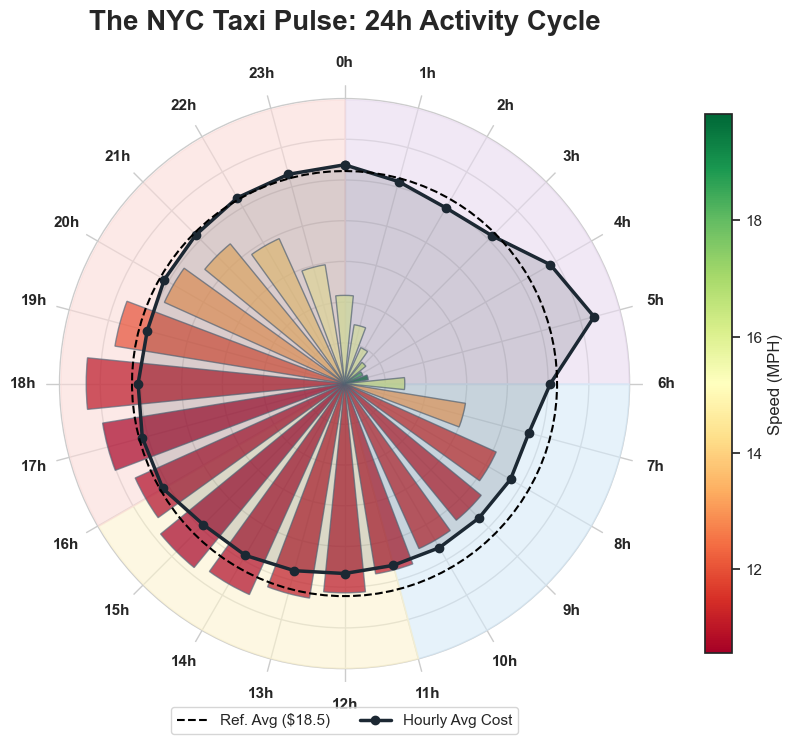

In [140]:
df_plot = df_pyspark.toPandas()

labels = df_plot['pickup_hour'].values
counts = df_plot['trip_count'].values
speeds = df_plot['avg_speed'].values
totals = df_plot['avg_total'].values

#cycle
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles_closed = angles + [angles[0]]
totals_closed = np.append(totals, totals[0])
reference_val = 18.50
scale_factor = counts.max() / totals.max()
ref_scaled = reference_val * scale_factor
totals_scaled = totals_closed * scale_factor

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': 'polar'}, facecolor='white')
phases = [(0, 6, "#E8DAEF"), (6, 11, "#D6EAF8"), (11, 16, "#FCF3CF"), (16, 24, "#FADBD8")]
for s, e, c in phases:
    ax.fill_between(np.linspace((s/24)*2*np.pi, (e/24)*2*np.pi, 100), 0, counts.max()*1.1, color=c, alpha=0.6, zorder=1)

norm = plt.Normalize(speeds.min(), speeds.max())
ax.bar(angles, counts, width=0.2, color=plt.cm.RdYlGn(norm(speeds)), alpha=0.7, edgecolor='#5D6D7E', zorder=2)
ax.plot(np.linspace(0, 2*np.pi, 100), [ref_scaled]*100, color='black', linestyle='--', linewidth=1.5, label=f'Ref. Avg (${reference_val})', zorder=5)
ax.fill(angles_closed, totals_scaled, color='#1C2833', alpha=0.15, zorder=3)
ax.plot(angles_closed, totals_scaled, color='#1C2833', linewidth=2.5, marker='o', label='Hourly Avg Cost', zorder=4)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(np.linspace(0, 2 * np.pi, 24, endpoint=False))
ax.set_xticklabels([f"{h}h" for h in range(24)], fontweight='bold')
ax.set_yticklabels([])
ax.spines['polar'].set_visible(False)

sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlGn, norm=norm)
plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.08, shrink=0.7).set_label('Speed (MPH)')
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=True)

plt.title('The NYC Taxi Pulse: 24h Activity Cycle', fontsize=20, fontweight='bold', pad=40)
plt.show()

**Revenue Leakage: Analysis of Non-Revenue Trips and Disputed Payments**

This visualization provides a critical audit of the taxi system's operational efficiency by mapping Revenue Leakage across distinct day phases. By isolating anomalies, specifically payment disputes, technical 'zero-fare' errors, and non-charged trips, the chart identifies significant financial friction within the payment cycle. A primary observation is the staggering impact of 'No Charge' status during the Morning Peak, accounting for over $1.2 million in lost potential revenue.

Furthermore, the rising trend in Disputed Transactions during the Evening Peak suggests increased operational stress or billing conflicts during high-traffic hours. These insights are vital for stakeholders to prioritize system calibrations and fraud prevention measures, shifting focus from general oversight to targeted financial recovery in high-loss periods.

In [144]:
#pyspark
start_py = time.time()
df_dw_py = df_speed.filter("(fare_amount <= 0 AND trip_distance > 0) OR payment_type IN (3, 4)") \
    .groupBy("time_of_day", "payment_type") \
    .agg(
        F.count("*").alias("trips"),
        F.sum("trip_distance").alias("miles"),
        F.abs(F.sum("total_amount")).alias("loss")
    )
duration_py = time.time() - start_py

In [145]:
#sparksql
start_sql = time.time()
df_dw_sql = spark.sql("""
    SELECT time_of_day,
           CASE payment_type
                WHEN 3 THEN 'No Charge'
                WHEN 4 THEN 'Dispute'
                ELSE 'Zero Fare / Tech Error'
           END as category,
           COUNT(*) as trips,
           SUM(trip_distance) as miles,
           ABS(SUM(total_amount)) as loss
    FROM taxi_data
    WHERE (fare_amount <= 0 AND trip_distance > 0) OR payment_type IN (3, 4)
    GROUP BY 1, 2
""")
duration_sql = time.time() - start_sql

print(f"PySpark: {duration_py:.4f}s | SQL: {duration_sql:.4f}s")

PySpark: 0.0782s | SQL: 0.0235s


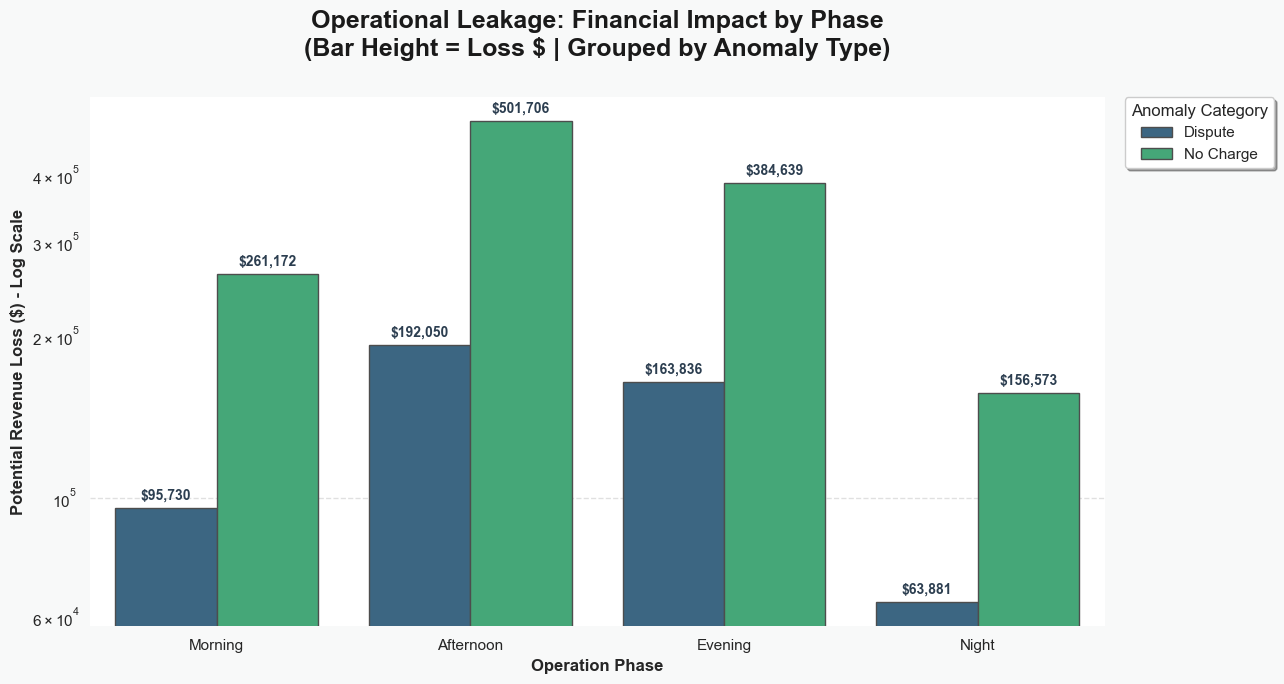

In [150]:
pdf_dw = df_dw_sql.toPandas()

order = ['Morning', 'Afternoon', 'Evening', 'Night']
pdf_dw['time_of_day'] = pd.Categorical(pdf_dw['time_of_day'], categories=order, ordered=True)
pdf_dw = pdf_dw.sort_values('time_of_day')

plt.figure(figsize=(13, 7), facecolor='#F8F9F9')
ax = plt.gca()
sns.barplot(
    data=pdf_dw,
    x='time_of_day',
    y='loss',
    hue='category',
    palette='viridis',
    edgecolor='0.3',
    linewidth=1,
    ax=ax
)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'${p.get_height():,.0f}',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha = 'center', va = 'center',
                        xytext = (0, 9),
                        textcoords = 'offset points',
                        fontsize=10, fontweight='bold', color='#2C3E50')

ax.set_yscale('log')
plt.title("Operational Leakage: Financial Impact by Phase\n(Bar Height = Loss $ | Grouped by Anomaly Type)",
          fontsize=18, fontweight='bold', pad=30, color='#1A1A1A')
plt.ylabel("Potential Revenue Loss ($) - Log Scale", fontsize=12, fontweight='bold')
plt.xlabel("Operation Phase", fontsize=12, fontweight='bold')

sns.despine(left=True, bottom=True)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
plt.legend(
    title="Anomaly Category",
    frameon=True,
    shadow=True,
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0
)

plt.tight_layout()
plt.show()

**Operational Efficiency Analysis: The Inverse Relationship Between Revenue Density and Traffic Velocity**

This dual-axis visualization investigates the core operational efficiency of the taxi fleet by correlating Revenue per Mile (RPM) with Average Speed (MPH) across a 24-hour cycle. The analysis reveals a critical 'Efficiency Paradox': while revenue density typically peaks during the Evening Rush, operational friction (traffic congestion) causes a significant drop in velocity, potentially increasing vehicle wear and driver fatigue. By highlighting these 'Golden Hours' versus 'High-Friction Periods,' this chart provides stakeholders with the data necessary to evaluate the effectiveness of current surcharges and identifies specific windows—such as the early morning—where high speed and stable revenue offer the highest net profitability per hour.

In [151]:
#sparksql
start_sql = time.time()
df_efficiency_sql = spark.sql("""
    SELECT
        pickup_hour,
        -- Rentabilidade: Quanto ganhamos por cada milha percorrida
        ROUND(AVG(total_amount / trip_distance), 2) AS rev_per_mile,
        -- Esforço: Velocidade média (Milhas / Horas)
        ROUND(AVG(trip_distance / (trip_duration_min / 60)), 2) AS avg_speed_mph,
        COUNT(*) as trip_volume
    FROM taxi_data
    WHERE trip_distance > 0 AND trip_duration_min > 0 AND total_amount > 0
    GROUP BY pickup_hour
    ORDER BY pickup_hour
""")
pdf_efficiency = df_efficiency_sql.toPandas()
duration_sql = time.time() - start_sql

In [152]:
#pyspark
start_py = time.time()
df_efficiency_py = df_speed.filter("trip_distance > 0 AND trip_duration_min > 0 AND total_amount > 0") \
    .groupBy("pickup_hour") \
    .agg(
        F.round(F.avg(F.col("total_amount") / F.col("trip_distance")), 2).alias("rev_per_mile"),
        F.round(F.avg(F.col("trip_distance") / (F.col("trip_duration_min") / 60)), 2).alias("avg_speed_mph")
    ).orderBy("pickup_hour")
duration_py = time.time() - start_py

print(f"SparkSQL: {duration_sql:.4f}s | PySpark: {duration_py:.4f}s")

SparkSQL: 2.1019s | PySpark: 0.1050s


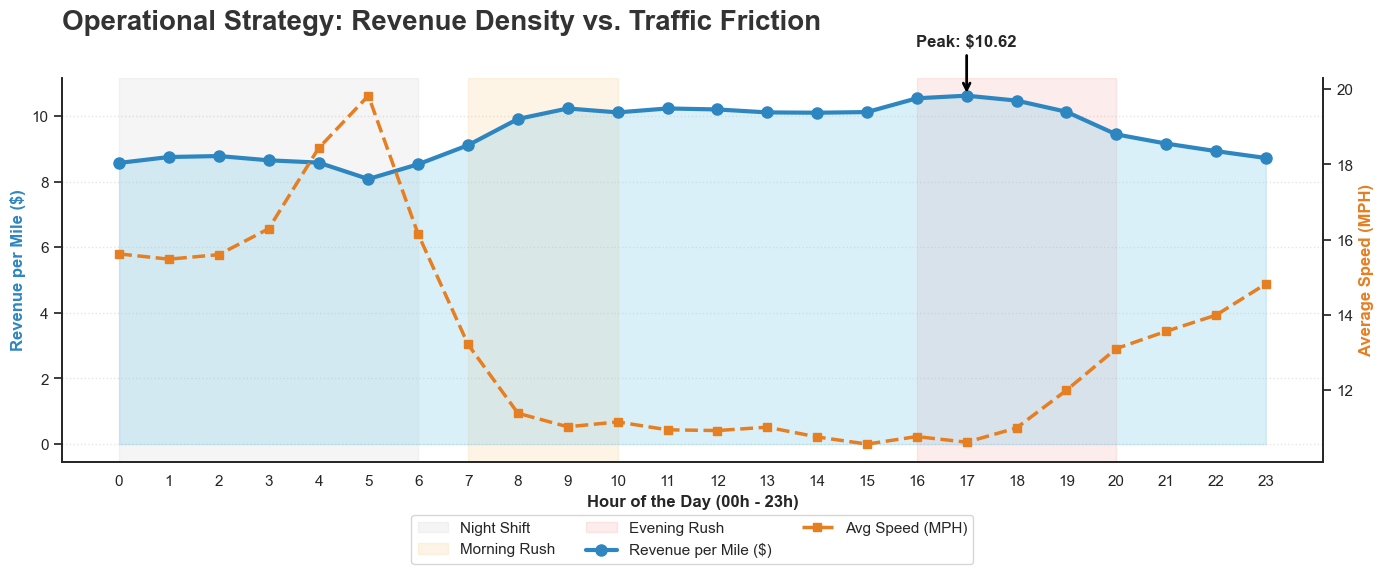

In [153]:
fig, ax1 = plt.subplots(figsize=(14, 6), facecolor='white')
ax2 = ax1.twinx()

ax1.axvspan(0, 6, color='gray', alpha=0.08, label='Night Shift')
ax1.axvspan(7, 10, color='#F39C12', alpha=0.1, label='Morning Rush')
ax1.axvspan(16, 20, color='#E74C3C', alpha=0.1, label='Evening Rush')

line1, = ax1.plot(pdf_efficiency['pickup_hour'], pdf_efficiency['rev_per_mile'],
                  color='#2E86C1', marker='o', linewidth=3, markersize=8,
                  label='Revenue per Mile ($)')
ax1.fill_between(pdf_efficiency['pickup_hour'], pdf_efficiency['rev_per_mile'],
                 color='skyblue', alpha=0.3)
line2, = ax2.plot(pdf_efficiency['pickup_hour'], pdf_efficiency['avg_speed_mph'],
                  color='#E67E22', linestyle='--', linewidth=2.5, marker='s', markersize=6,
                  label='Avg Speed (MPH)')
ax1.set_title("Operational Strategy: Revenue Density vs. Traffic Friction",
             fontsize=20, fontweight='bold', pad=35, loc='left', color='#333333')
ax1.set_xlabel("Hour of the Day (00h - 23h)", fontsize=12, fontweight='bold')
ax1.set_ylabel("Revenue per Mile ($)", fontsize=12, fontweight='bold', color='#2E86C1')
ax2.set_ylabel("Average Speed (MPH)", fontsize=12, fontweight='bold', color='#E67E22')
ax1.set_xticks(range(0, 24))
ax1.grid(axis='y', linestyle=':', alpha=0.5)

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2,
           loc='upper center',
           bbox_to_anchor=(0.5, -0.12),
           ncol=3,
           frameon=True,
           fontsize=11)

max_rev_hour = pdf_efficiency.loc[pdf_efficiency['rev_per_mile'].idxmax(), 'pickup_hour']
max_rev_val = pdf_efficiency['rev_per_mile'].max()
ax1.annotate(f'Peak: ${max_rev_val}',
             xy=(max_rev_hour, max_rev_val),
             xytext=(max_rev_hour, max_rev_val + 1.5),
             ha='center',
             arrowprops=dict(arrowstyle='->', lw=2, color='black'),
             fontsize=12, fontweight='bold')

ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

**Logistics Performance: Fleet Idle Time and Deadheading Friction Analysis**

In [154]:
df_logistica = taxi_df.select(
    "VendorID",
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "PULocationID"
)

#pyspark
start_py = time.time()

window_spec = Window.partitionBy("VendorID").orderBy("tpep_pickup_datetime")
df_idle_py = df_logistica.withColumn("prev_dropoff", F.lag("tpep_dropoff_datetime").over(window_spec)) \
    .withColumn("idle_time_min",
                (F.unix_timestamp("tpep_pickup_datetime") - F.unix_timestamp("prev_dropoff")) / 60) \
    .filter("prev_dropoff IS NOT NULL AND idle_time_min > 0 AND idle_time_min < 60") \
    .groupBy("PULocationID") \
    .agg(F.avg("idle_time_min").alias("avg_idle_minutes")) \
    .orderBy(F.desc("avg_idle_minutes")) \
    .limit(5)

pdf_idle = df_idle_py.toPandas()
duration_py = time.time() - start_py

In [155]:
#sparksql
df_logistica.createOrReplaceTempView("taxi_logistics_data")

start_sql = time.time()
df_idle_sql = spark.sql("""
    WITH TripSequencing AS (
        SELECT
            PULocationID,
            tpep_pickup_datetime,
            LAG(tpep_dropoff_datetime) OVER (PARTITION BY VendorID ORDER BY tpep_pickup_datetime) as prev_dropoff
        FROM taxi_logistics_data
    )
    SELECT
        PULocationID,
        ROUND(AVG(UNIX_TIMESTAMP(tpep_pickup_datetime) - UNIX_TIMESTAMP(prev_dropoff)) / 60, 2) as avg_idle_minutes
    FROM TripSequencing
    WHERE prev_dropoff IS NOT NULL
      AND (UNIX_TIMESTAMP(tpep_pickup_datetime) - UNIX_TIMESTAMP(prev_dropoff)) / 60 BETWEEN 0.1 AND 60
    GROUP BY PULocationID
    ORDER BY avg_idle_minutes DESC
    LIMIT 5
""")
pdf_idle_sql = df_idle_sql.toPandas()
duration_sql = time.time() - start_sql

print(f"SparkSQL: {duration_sql:.4f}s | PySpark: {duration_py:.4f}s")

SparkSQL: 14.9984s | PySpark: 15.7548s


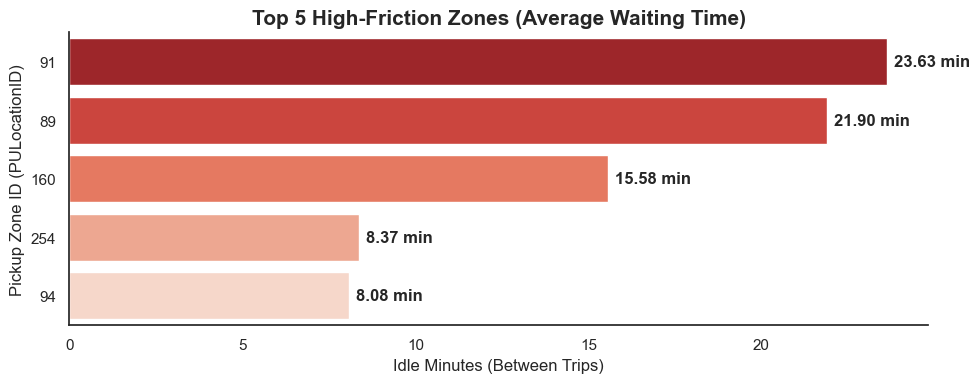

In [156]:
plt.figure(figsize=(10, 4))
colors = sns.color_palette("Reds_r", n_colors=5)
ax = sns.barplot(
    x="avg_idle_minutes",
    y=pdf_idle_sql["PULocationID"].astype(str),
    data=pdf_idle_sql,
    palette=colors,
    hue=pdf_idle_sql["PULocationID"].astype(str),
    legend=False
)

plt.title("Top 5 High-Friction Zones (Average Waiting Time)", fontsize=15, fontweight='bold')
plt.xlabel("Idle Minutes (Between Trips)", fontsize=12)
plt.ylabel("Pickup Zone ID (PULocationID)", fontsize=12)

for p in ax.patches:
    ax.annotate(f'{p.get_width():.2f} min',
                (p.get_width(), p.get_y() + p.get_height() / 2),
                xytext=(5, 0), textcoords='offset points',
                va='center', fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

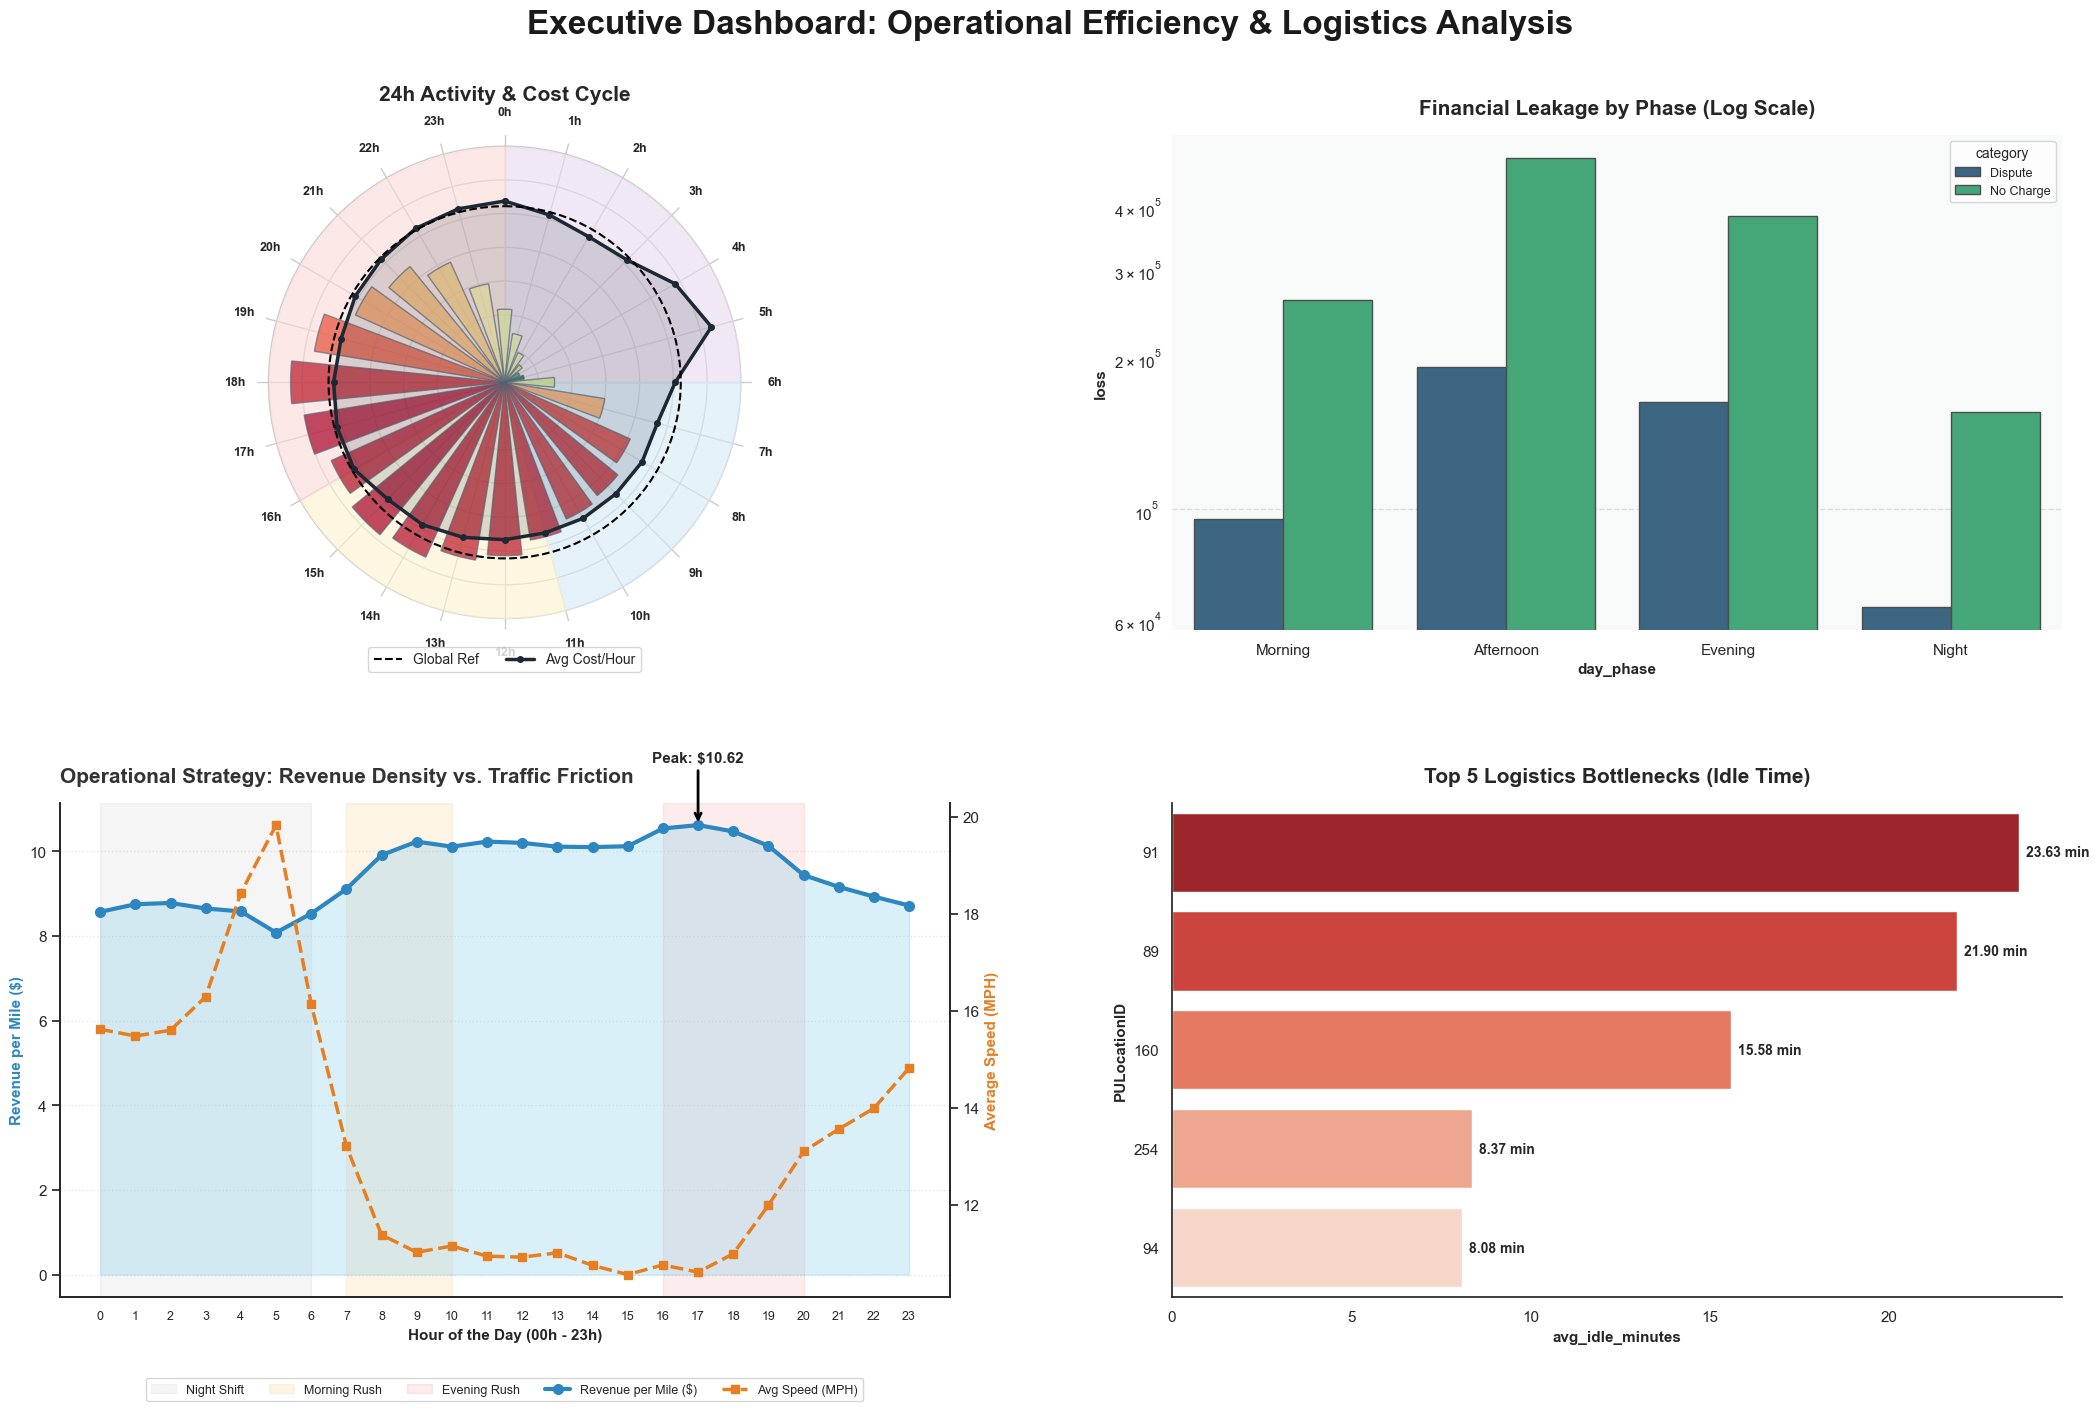

In [160]:
# Ensure G2 categorical ordering is applied
order = ['Morning', 'Afternoon', 'Evening', 'Night']
pdf_dw['time_of_day'] = pd.Categorical(pdf_dw['time_of_day'], categories=order, ordered=True)
pdf_dw_sorted = pdf_dw.sort_values('time_of_day')

# Figure scaffold — 2×2 grid, top-left is polar
fig = plt.figure(figsize=(22, 14), facecolor='white')
gs = GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.25)

fig.suptitle(
    "Executive Dashboard: Operational Efficiency & Logistics Analysis",
    fontsize=24, fontweight='bold', color="#1A1A1A", y=0.99
)

# ============================================================
# G1: TOP-LEFT — 24h Activity & Cost Cycle (polar)
# ============================================================
ax1 = fig.add_subplot(gs[0, 0], projection='polar')
ax1.set_facecolor('white')

labels = df_plot['pickup_hour'].values
counts = df_plot['trip_count'].values
speeds = df_plot['avg_speed'].values
totals = df_plot['avg_total'].values

angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles_closed = angles + [angles[0]]
totals_closed = np.append(totals, totals[0])
reference_val = 18.50
scale_factor = counts.max() / totals.max()
ref_scaled = reference_val * scale_factor
totals_scaled = totals_closed * scale_factor

phases = [(0, 6, "#E8DAEF"), (6, 11, "#D6EAF8"), (11, 16, "#FCF3CF"), (16, 24, "#FADBD8")]
for s, e, c in phases:
    ax1.fill_between(np.linspace((s/24)*2*np.pi, (e/24)*2*np.pi, 100),
                     0, counts.max()*1.1, color=c, alpha=0.6, zorder=1)

norm = plt.Normalize(speeds.min(), speeds.max())
ax1.bar(angles, counts, width=0.2,
        color=plt.cm.RdYlGn(norm(speeds)), alpha=0.7,
        edgecolor='#5D6D7E', zorder=2)
ax1.plot(np.linspace(0, 2*np.pi, 100), [ref_scaled]*100,
         color='black', linestyle='--', linewidth=1.5,
         label='Global Ref', zorder=5)
ax1.fill(angles_closed, totals_scaled, color='#1C2833', alpha=0.15, zorder=3)
ax1.plot(angles_closed, totals_scaled, color='#1C2833',
         linewidth=2.5, marker='o', markersize=4,
         label='Avg Cost/Hour', zorder=4)

ax1.set_theta_offset(np.pi / 2)
ax1.set_theta_direction(-1)
ax1.set_xticks(np.linspace(0, 2 * np.pi, 24, endpoint=False))
ax1.set_xticklabels([f"{h}h" for h in range(24)], fontweight='bold', fontsize=9)
ax1.set_yticklabels([])
ax1.spines['polar'].set_visible(False)
ax1.set_title('24h Activity & Cost Cycle', fontsize=15, fontweight='bold', pad=25)
ax1.legend(loc='lower center', bbox_to_anchor=(0.5, -0.10),
           ncol=2, frameon=True, fontsize=10)

# ============================================================
# G2: TOP-RIGHT — Financial Leakage by Phase (log scale)
# ============================================================
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor('#F8F9F9')

sns.barplot(
    data=pdf_dw_sorted,
    x='time_of_day',
    y='loss',
    hue='category',
    palette='viridis',
    edgecolor='0.3',
    linewidth=1,
    ax=ax2
)

ax2.set_yscale('log')
ax2.set_title("Financial Leakage by Phase (Log Scale)",
              fontsize=15, fontweight='bold', pad=15)
ax2.set_ylabel("loss", fontsize=11, fontweight='bold')
ax2.set_xlabel("day_phase", fontsize=11, fontweight='bold')
ax2.yaxis.grid(True, linestyle='--', alpha=0.6)
sns.despine(ax=ax2, left=True, bottom=True)

ax2.legend(title="category", frameon=True, loc='upper right', fontsize=9, title_fontsize=10)

# ============================================================
# G3: BOTTOM-LEFT — Revenue Density vs Traffic Friction
# ============================================================
ax3 = fig.add_subplot(gs[1, 0])
ax3b = ax3.twinx()

ax3.axvspan(0, 6, color='gray', alpha=0.08, label='Night Shift')
ax3.axvspan(7, 10, color='#F39C12', alpha=0.1, label='Morning Rush')
ax3.axvspan(16, 20, color='#E74C3C', alpha=0.1, label='Evening Rush')

line1, = ax3.plot(pdf_efficiency['pickup_hour'], pdf_efficiency['rev_per_mile'],
                  color='#2E86C1', marker='o', linewidth=3, markersize=7,
                  label='Revenue per Mile ($)')
ax3.fill_between(pdf_efficiency['pickup_hour'], pdf_efficiency['rev_per_mile'],
                 color='skyblue', alpha=0.3)

line2, = ax3b.plot(pdf_efficiency['pickup_hour'], pdf_efficiency['avg_speed_mph'],
                   color='#E67E22', linestyle='--', linewidth=2.5,
                   marker='s', markersize=6,
                   label='Avg Speed (MPH)')

ax3.set_title("Operational Strategy: Revenue Density vs. Traffic Friction",
              fontsize=15, fontweight='bold', pad=15, loc='left', color='#333333')
ax3.set_xlabel("Hour of the Day (00h - 23h)", fontsize=11, fontweight='bold')
ax3.set_ylabel("Revenue per Mile ($)", fontsize=11, fontweight='bold', color='#2E86C1')
ax3b.set_ylabel("Average Speed (MPH)", fontsize=11, fontweight='bold', color='#E67E22')
ax3.set_xticks(range(0, 24))
ax3.tick_params(axis='x', labelsize=9)
ax3.grid(axis='y', linestyle=':', alpha=0.5)

max_rev_hour = pdf_efficiency.loc[pdf_efficiency['rev_per_mile'].idxmax(), 'pickup_hour']
max_rev_val = pdf_efficiency['rev_per_mile'].max()
ax3.annotate(f'Peak: ${max_rev_val}',
             xy=(max_rev_hour, max_rev_val),
             xytext=(max_rev_hour, max_rev_val + 1.5),
             ha='center',
             arrowprops=dict(arrowstyle='->', lw=2, color='black'),
             fontsize=11, fontweight='bold')

ax3.spines['top'].set_visible(False)
ax3b.spines['top'].set_visible(False)

lines, lbls = ax3.get_legend_handles_labels()
lines2, lbls2 = ax3b.get_legend_handles_labels()
ax3.legend(lines + lines2, lbls + lbls2,
           loc='upper center', bbox_to_anchor=(0.5, -0.15),
           ncol=5, frameon=True, fontsize=9)

# ============================================================
# G4: BOTTOM-RIGHT — Top 5 Logistics Bottlenecks (Idle Time)
# ============================================================
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_facecolor('white')

colors = sns.color_palette("Reds_r", n_colors=5)
sns.barplot(
    x="avg_idle_minutes",
    y=pdf_idle_sql["PULocationID"].astype(str),
    data=pdf_idle_sql,
    palette=colors,
    hue=pdf_idle_sql["PULocationID"].astype(str),
    legend=False,
    ax=ax4
)

ax4.set_title("Top 5 Logistics Bottlenecks (Idle Time)",
              fontsize=15, fontweight='bold', pad=15)
ax4.set_xlabel("avg_idle_minutes", fontsize=11, fontweight='bold')
ax4.set_ylabel("PULocationID", fontsize=11, fontweight='bold')

for p in ax4.patches:
    width = p.get_width()
    if not np.isnan(width) and width > 0:
        ax4.annotate(f'{width:.2f} min',
                     (width, p.get_y() + p.get_height() / 2),
                     xytext=(5, 0), textcoords='offset points',
                     va='center', fontweight='bold', fontsize=10)

sns.despine(ax=ax4)

# ============================================================
# Final layout adjustments
# ============================================================
plt.subplots_adjust(top=0.90, bottom=0.07, left=0.05, right=0.96)
plt.show()

### **4.6. Metrics**

In [ ]:
import pandas as pd

metrics_data = {
    "Query Description": [
        "Q1: Borough Revenue vs Tip Percentage",
        "Q2: Tip Paradox by Distance",
        "Q3: Revenue Composition",
        "Q4: Payment Method Impact",
        "Q5: Passenger Count Impact",
        "Q6: Hourly Tip Dynamics",
        "Q7: Zone Revenue Competition",
        "Q8: Borough Revenue Routes"
    ],
    "API Time (s)": [q1_api_time, q2_api_time, q3_api_time, q4_api_time, q5_api_time, q6_api_time, q7_api_time, q8_api_time],
    "SQL Time (s)": [q1_sql_time, q2_sql_time, q3_sql_time, q4_sql_time, q5_sql_time, q6_sql_time, q7_sql_time, q8_sql_time],
}

metrics_df = pd.DataFrame(metrics_data)

# Calculate performance deltas
metrics_df['Time Delta (SQL - API)'] = metrics_df['SQL Time (s)'] - metrics_df['API Time (s)']

# Format the numerical columns for clean printing
for col in ['API Time (s)', 'SQL Time (s)', 'Time Delta (SQL - API)']:
    metrics_df[col] = metrics_df[col].round(4)

print("\n" + "="*90)
print(" SYSTEM PERFORMANCE METRICS: PySpark API vs. Spark SQL ".center(85))
print("="*90)
print(metrics_df.to_string(index=False))
print("="*90 + "\n")


                SYSTEM PERFORMANCE METRICS: PySpark API vs. Spark SQL                
                    Query Description  API Time (s)  SQL Time (s)  Time Delta (SQL - API)
Q1: Borough Revenue vs Tip Percentage       59.7242       44.9330                -14.7912
          Q2: Tip Paradox by Distance       38.0970       35.6537                 -2.4433
              Q3: Revenue Composition       45.2168       57.9150                 12.6982
            Q4: Payment Method Impact       56.0908       57.2402                  1.1494
           Q5: Passenger Count Impact       61.4377       38.4373                -23.0004
              Q6: Hourly Tip Dynamics       32.4552       32.7922                  0.3371
         Q7: Zone Revenue Competition       60.0990       98.4516                 38.3527
           Q8: Borough Revenue Routes       46.0906       50.8470                  4.7564



---